<a href="https://colab.research.google.com/github/ssafy0121/codetree0121/blob/master/A%EB%8C%80%EB%B9%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1일차

# K개 중에 1개를 N번 뽑기

40XP

평균 20분

79% 정답률

총 제출 5,585회
___
1이상 K이하의 숫자를 하나 고르는 행위를 N번 반복하여 나올 수 있는 모든 서로 다른 순서쌍을 구해주는 프로그램을 작성해보세요.

예를 들어 K가 3, N이 2인 경우 다음과 같이 9개의 조합이 가능합니다.

1 1

1 2

1 3

2 1

2 2

2 3

3 1

3 2

3 3

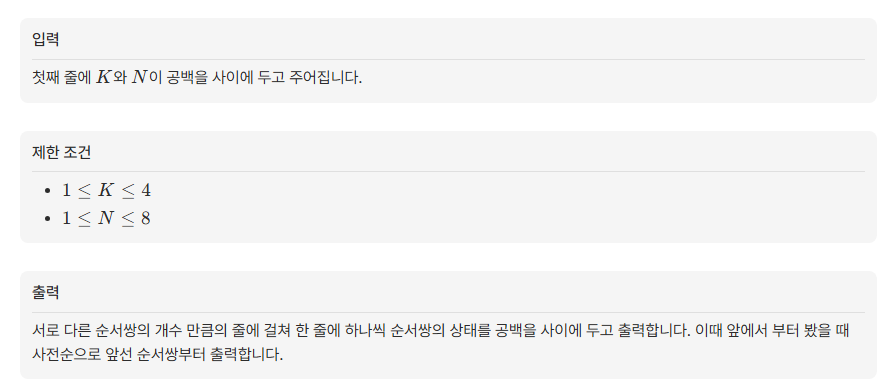

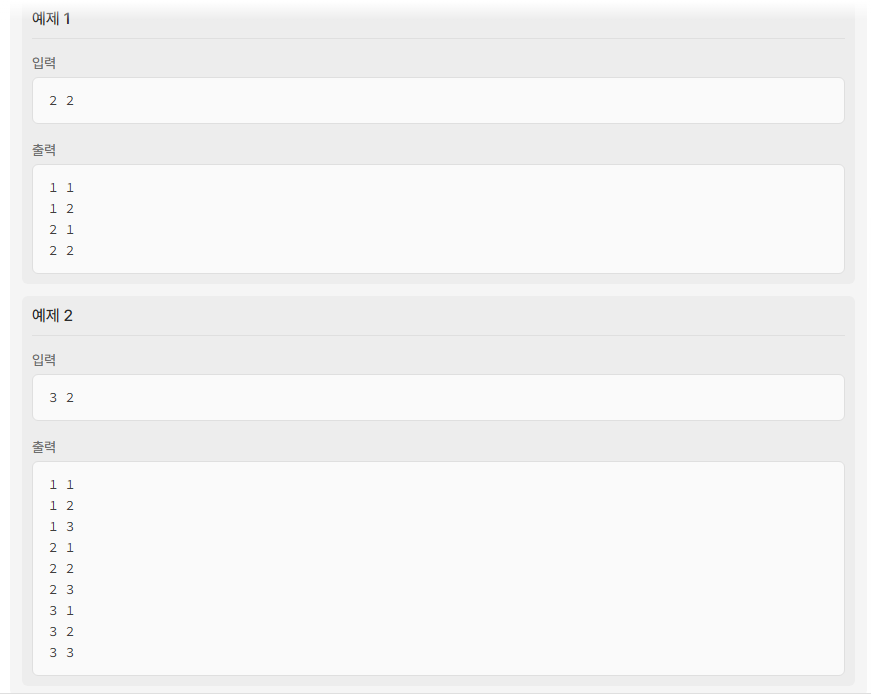

In [ ]:
# 사용자로부터 K(고를 수 있는 숫자의 범위)와 N(뽑을 횟수)을 공백을 기준으로 입력받습니다.
# input().split()으로 나눈 문자열을 map을 통해 정수(int)로 변환하여 각각 K와 N에 저장합니다.
K, N = map(int, input().split())

# 뽑은 숫자들을 차례대로 담아둘 빈 리스트(바구니 역할)를 만듭니다.
selected_numbers = []

# 재귀 함수를 정의합니다. cnt는 현재까지 뽑은 숫자의 개수를 의미합니다.
def find_permutations(cnt):
    # [종료 조건] 만약 지금까지 뽑은 숫자의 개수(cnt)가 목표치(N)와 같아졌다면?
    if cnt == N:
        # 리스트 앞에 '*'를 붙여서 출력하면, 리스트 안의 요소들이 공백을 두고 한 줄로 예쁘게 출력됩니다.
        print(*selected_numbers)
        # 원하는 개수만큼 다 뽑았으니, 더 이상 진행하지 않고 이전 단계로 돌아갑니다.
        return

    # 1부터 K까지의 숫자를 차례대로 확인합니다. (K+1은 포함되지 않으므로 1~K 반복)
    for i in range(1, K + 1):
        # 현재 숫자 i를 바구니(리스트)의 맨 끝에 추가합니다.
        selected_numbers.append(i)

        # 숫자 하나를 추가했으므로, 뽑은 개수(cnt)에 1을 더해서 다시 자기 자신(함수)을 호출합니다.
        find_permutations(cnt + 1)

        # 위의 함수가 끝난 후 여기로 돌아오면, 방금 전에 추가했던 숫자를 바구니에서 다시 뺍니다.
        # 이렇게 해야 다음 반복(for문)에서 새로운 숫자를 바구니에 넣을 수 있습니다. (이것이 백트래킹의 핵심!)
        selected_numbers.pop()

# 처음에는 아무 숫자도 뽑지 않았으므로 개수(cnt)를 0으로 주고 함수를 시작합니다.
find_permutations(0)

2 2
1 1
1 2
2 1
2 2


# 아름다운 수

60XP

평균 79분

65% 정답률

총 제출 4,362회
___
1이상 4이하의 정수로만 이루어져 있으면서, 정확히 해당 숫자만큼 연달아 같은 숫자가 나오는 수를 아름다운 수 라고 부릅니다.

예를 들어 1333221는 1이 1번, 3이 3번, 2가 2번 그리고 1이 1번 연속하여 나오므로 아름다운 수 입니다.

이때 동일한 숫자에 대해 연달아 같은 숫자의 묶음이 나오는 것 또한 아름다운 수 입니다.

예를 들어 111, 22222222와 같은 수 역시 1이 1번 나온 것이 3번 반복되었고, 2가 2번 나온 것이 4번 반복되었다고 할 수 있기 때문에 아름다운 수라고 할 수 있습니다.
다만, 222의 경우에는 2가 2번 나온 뒤, 다시 2가 1번 나왔으므로 아름다운 수가 아닙니다.

N자리 아름다운 수가 몇 개 있는지를 구하는 프로그램을 작성해보세요.

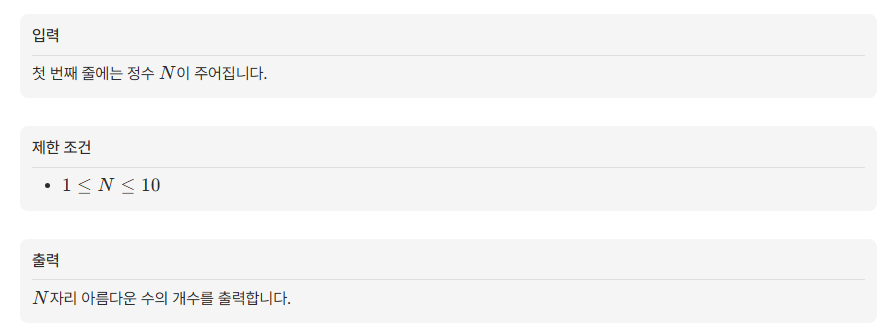

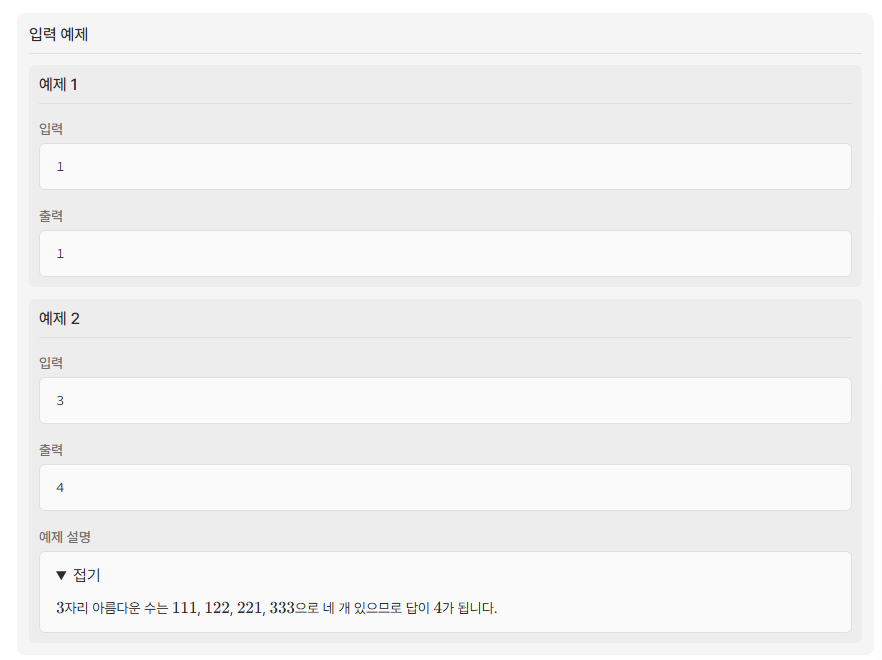

In [ ]:
# 사용자로부터 찾고자 하는 아름다운 수의 길이 N을 입력받습니다.
N = int(input())

# 조건을 만족하는 아름다운 수의 개수를 저장할 변수를 만듭니다.
beautiful_count = 0

# 아름다운 수의 길이를 늘려가며 확인하는 재귀 함수를 정의합니다.
# current_length: 현재까지 만들어진 아름다운 수의 길이
def find_beautiful_numbers(current_length):
    # 함수 내에서 전역 변수 beautiful_count의 값을 변경하기 위해 global 키워드를 사용합니다.
    global beautiful_count

    # [종료 조건 1] 현재 길이가 목표 길이 N과 정확히 일치한다면?
    if current_length == N:
        # 조건에 맞는 아름다운 수를 하나 찾았으므로 개수를 1 증가시킵니다.
        beautiful_count += 1
        # 더 이상 탐색할 필요가 없으므로 함수를 종료하고 이전 단계로 돌아갑니다.
        return

    # [종료 조건 2] 현재 길이가 목표 길이 N을 초과했다면?
    if current_length > N:
        # N자리 수를 넘어가면 조건에 맞지 않으므로 개수를 세지 않고 즉시 돌아갑니다.
        return

    # 1부터 4까지의 숫자를 덩어리(블록)로 추가해 봅니다. (1~4 반복)
    for i in range(1, 5):
        # 숫자 i는 반드시 i번 연달아 나와야 하므로, 한 번 추가할 때마다 길이는 i만큼 늘어납니다.
        # 현재 길이에 i만큼을 더한 상태로 다음 단계를 탐색합니다. (재귀 호출)
        # 예: i=2일 때 '22'가 추가되므로 길이는 2 늘어납니다.
        find_beautiful_numbers(current_length + i)

# 처음에는 아무 숫자도 붙이지 않았으므로 길이 0부터 탐색을 시작합니다.
find_beautiful_numbers(0)

# 탐색이 모두 끝난 후, 최종적으로 찾은 아름다운 수의 개수를 출력합니다.
print(beautiful_count)

1
1


# 특정 조건에 맞게 K개 중에 1개를 N번 뽑기

40XP

평균 20분

60% 정답률

총 제출 4,590회
___
1이상 K이하의 숫자를 하나 고르는 행위를 N번 반복하여 나올 수 있는 모든 서로 다른 순서쌍을 구해주는 프로그램을 작성해보세요. 단, 연속하여 같은 숫자가 3번 이상 나오는 경우는 제외합니다.

예를 들어 K가 2, N이 3인 경우 다음과 같이 6개의 조합이 가능합니다.

1 1 2

1 2 1

1 2 2

2 1 1

2 1 2

2 2 1

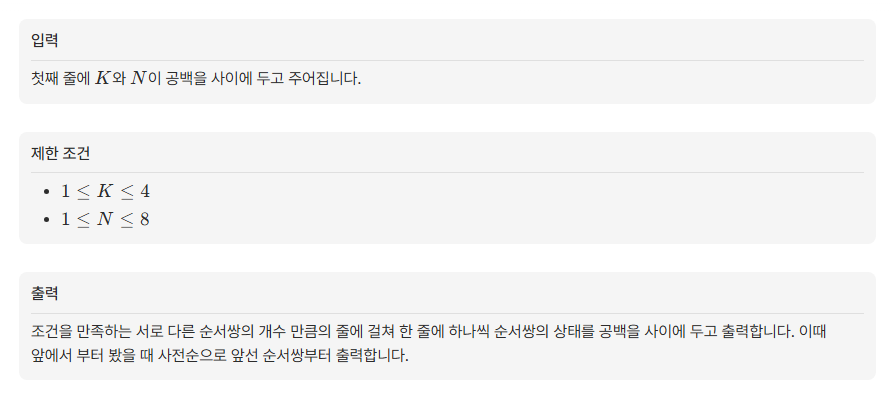

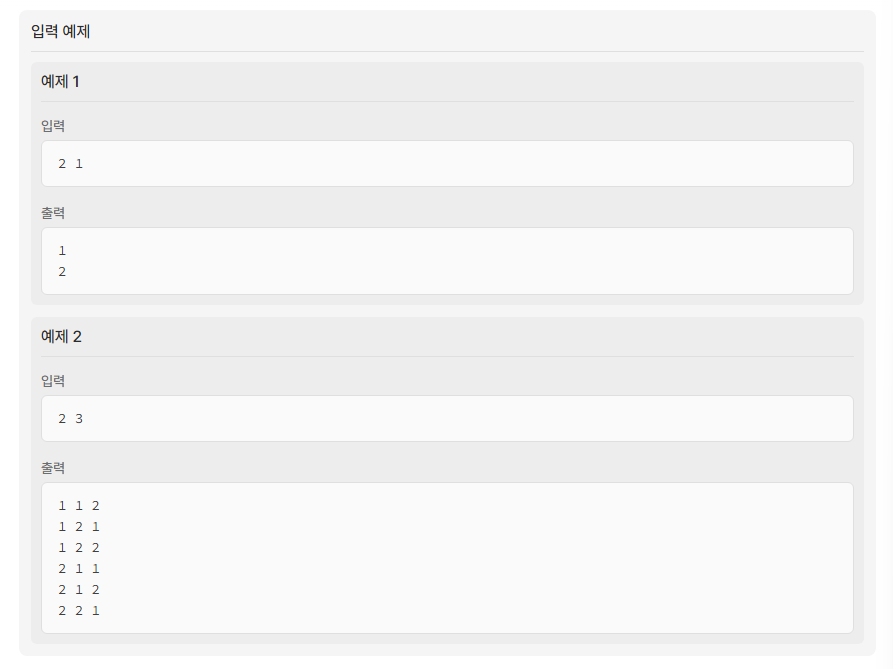

In [ ]:
# 사용자로부터 K(고를 수 있는 숫자의 범위)와 N(뽑을 횟수)을 공백을 기준으로 입력받습니다.
K, N = map(int, input().split())

# 뽑은 숫자들을 차례대로 담아둘 빈 리스트(바구니 역할)를 만듭니다.
selected_numbers = []

# 조건에 맞춰 순서쌍을 만드는 재귀 함수를 정의합니다. cnt는 현재까지 뽑은 숫자의 개수입니다.
def find_conditional_permutations(cnt):
    # [종료 조건] 현재까지 뽑은 숫자의 개수(cnt)가 목표치(N)와 같아졌다면?
    if cnt == N:
        # 완성된 순서쌍을 공백을 두고 한 줄로 출력합니다.
        print(*selected_numbers)
        # 더 이상 진행하지 않고 이전 단계로 돌아갑니다.
        return

    # 1부터 K까지의 숫자를 차례대로 바구니에 넣어보려고 시도합니다.
    for i in range(1, K + 1):
        # [조건 검사] 바구니에 이미 숫자가 2개 이상 들어있는지 확인합니다.
        if cnt >= 2:
            # 방금 전에 넣은 숫자(맨 끝)와 그 전에 넣은 숫자가 모두 현재 넣으려는 숫자 i와 같다면?
            if selected_numbers[-1] == i and selected_numbers[-2] == i:
                # 연속 3번이 되므로, 이 숫자는 무시하고 다음 숫자(for문의 다음 반복)로 넘어갑니다.
                continue

        # 조건 검사를 무사히 통과했다면(연속 3번이 아니라면), 바구니의 맨 끝에 숫자 i를 추가합니다.
        selected_numbers.append(i)

        # 숫자를 하나 추가했으므로, 뽑은 개수(cnt)에 1을 더해서 다음 단계를 탐색합니다. (재귀 호출)
        find_conditional_permutations(cnt + 1)

        # 다음 단계 탐색을 마치고 돌아왔다면, 다른 숫자도 넣어보기 위해 방금 넣었던 숫자를 다시 뺍니다. (백트래킹)
        selected_numbers.pop()

# 처음에는 아무 숫자도 뽑지 않았으므로 개수(cnt)를 0으로 주고 함수를 시작합니다.
find_conditional_permutations(0)

2 1
1
2


# 2일차

# N개 중에 M개 뽑기

40XP

평균 20분

84% 정답률

총 제출 3,432회
___
1이상 N이하의 숫자 중 M개의 숫자를 골라 만들 수 있는 모든 조합을 구해주는 프로그램을 작성해보세요.

예를 들어 N이 4, M이 3인 경우 다음과 같이 4개의 조합이 가능합니다.

1 2 3
1 2 4
1 3 4
2 3 4

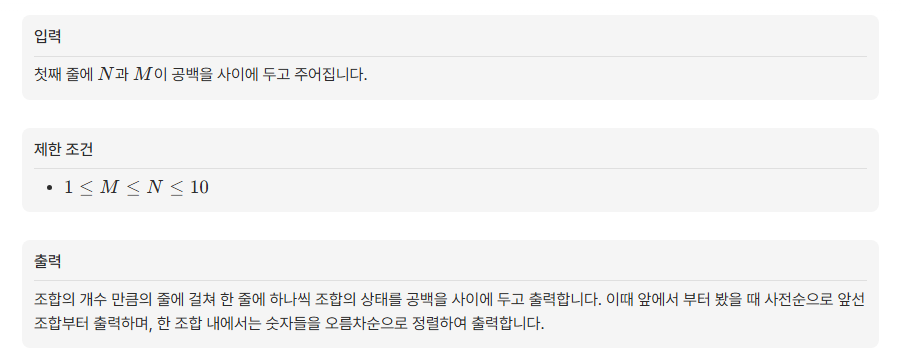

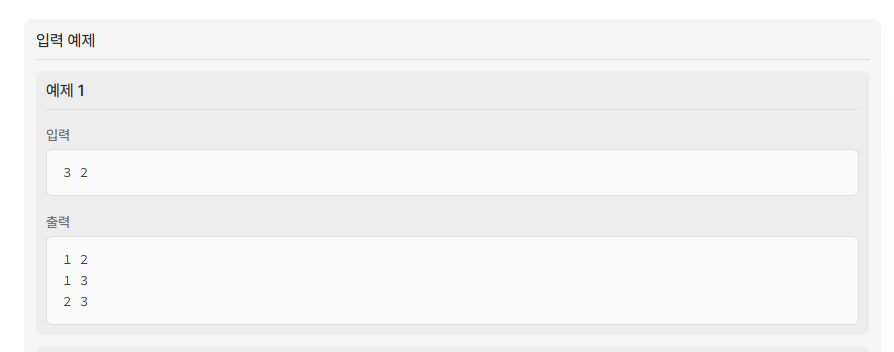

In [ ]:
# 사용자로부터 N(전체 숫자의 범위)과 M(뽑을 숫자의 개수)을 공백 기준으로 입력받습니다.
N, M = map(int, input().split())

# 뽑은 숫자들을 차례대로 담아둘 빈 리스트(바구니 역할)를 만듭니다.
selected_numbers = []

# 조합을 찾는 재귀 함수를 정의합니다.
# start_num: 이번 반복문에서 탐색을 시작할 숫자
# cnt: 현재까지 뽑은 숫자의 개수
def find_combinations(start_num, cnt):
    # [종료 조건] 만약 지금까지 뽑은 숫자의 개수(cnt)가 목표치(M)와 같아졌다면?
    if cnt == M:
        # 완성된 조합(리스트)을 공백을 두고 한 줄로 출력합니다.
        print(*selected_numbers)
        # 더 이상 탐색할 필요가 없으므로 이전 단계로 돌아갑니다.
        return

    # start_num부터 N까지의 숫자를 차례대로 확인합니다. (이전 숫자보다 큰 숫자만 탐색)
    for i in range(start_num, N + 1):
        # 현재 탐색 중인 숫자 i를 바구니에 추가합니다.
        selected_numbers.append(i)

        # 숫자를 하나 추가했으므로, 다음 탐색을 위해 재귀 함수를 호출합니다.
        # 핵심 포인트: 다음 숫자는 방금 뽑은 i보다 커야 하므로 시작점을 i + 1로 넘겨줍니다!
        # 뽑은 개수(cnt)도 1 증가시켜 줍니다.
        find_combinations(i + 1, cnt + 1)

        # 다음 탐색을 마치고 돌아오면, 다른 경우의 수도 확인하기 위해 방금 넣은 숫자를 다시 뺍니다. (백트래킹)
        selected_numbers.pop()

# 처음에는 1부터 탐색을 시작해야 하고, 뽑은 개수는 0개이므로 (1, 0)을 넣고 시작합니다.
find_combinations(1, 0)

3 2
1 2
1 3
2 3


# XOR 결과 최대 만들기

40XP

평균 29분

53% 정답률

총 제출 3,225회
___
N개의 음이 아닌 정수가 입력으로 주어졌을 때, 그 중 M개의 숫자를 뽑아 모두 XOR한 결과의 최댓값을 출력하는 코드를 작성해보세요.

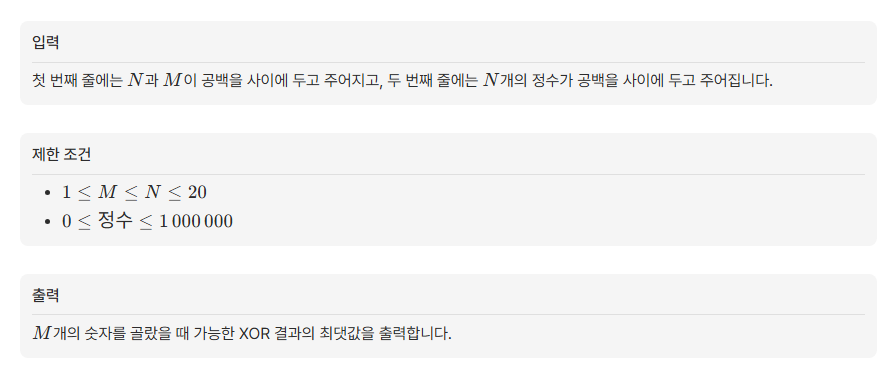

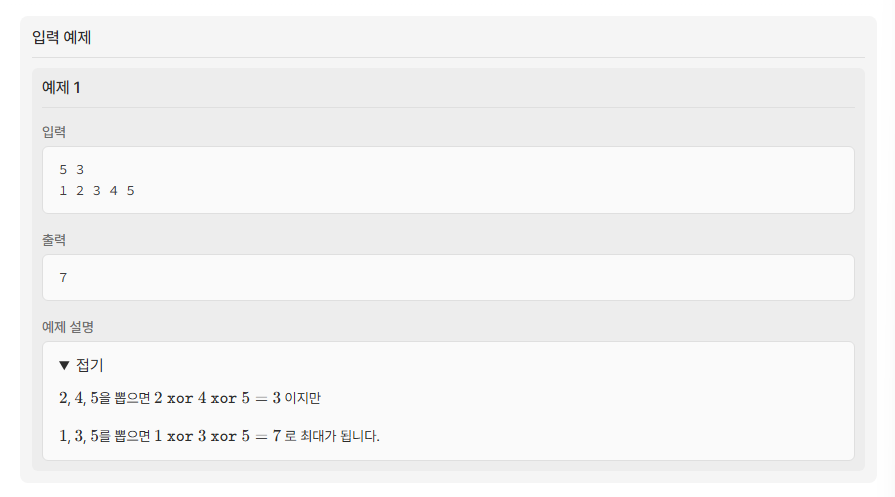

In [ ]:
# 사용자로부터 N(전체 숫자의 개수)과 M(뽑을 숫자의 개수)을 입력받습니다.
N, M = map(int, input().split())

# N개의 숫자들을 리스트 형태로 입력받습니다.
numbers = list(map(int, input().split()))

# XOR 계산 결과의 최댓값을 저장할 전역 변수를 만들고 0으로 초기화합니다.
max_xor_value = 0

# '뽑을까 말까' 방식을 사용한 재귀 함수를 정의합니다.
# idx: 현재 살펴보고 있는 numbers 리스트의 인덱스 번호
# cnt: 지금까지 뽑은 숫자의 개수
# current_xor: 지금까지 뽑은 숫자들을 XOR 연산한 누적 결과값
def find_max_xor(idx, cnt, current_xor):
    # 전역 변수 max_xor_value를 업데이트하기 위해 global 키워드를 사용합니다.
    global max_xor_value

    # [종료 조건 1] 목표한 개수(M개)를 모두 뽑았다면?
    if cnt == M:
        # 현재까지 계산된 XOR 값이 기존의 최댓값보다 크다면 최댓값을 갱신합니다.
        if current_xor > max_xor_value:
            max_xor_value = current_xor
        # 탐색을 마치고 돌아갑니다.
        return

    # [종료 조건 2 & 가지치기]
    # 1. 인덱스가 N에 도달했다면 (모든 숫자를 다 살펴봤다면)
    # 2. 남은 숫자를 다 뽑아도 M개가 안 된다면 (cnt + 앞으로 남은 개수 < M)
    if idx == N or cnt + (N - idx) < M:
        # 가망이 없으므로 더 이상 탐색하지 않고 돌아갑니다.
        return

    # [갈래 1] 현재 인덱스(idx)의 숫자를 "뽑는" 경우
    # 개수(cnt)를 1 늘리고, 누적 XOR 값에 현재 숫자를 XOR 연산(^) 해줍니다.
    # 인덱스는 다음 숫자를 보기 위해 idx + 1로 넘어갑니다.
    find_max_xor(idx + 1, cnt + 1, current_xor ^ numbers[idx])

    # [갈래 2] 현재 인덱스(idx)의 숫자를 "뽑지 않는" 경우
    # 개수(cnt)와 누적 XOR 값은 그대로 둡니다. (뽑지 않았으니까요!)
    # 인덱스만 다음 숫자를 보기 위해 idx + 1로 넘어갑니다.
    find_max_xor(idx + 1, cnt, current_xor)

# 0번 인덱스부터 탐색 시작, 뽑은 개수는 0개, 누적 XOR 값은 0으로 시작합니다.
# (0에 어떤 수를 XOR 해도 그 수가 그대로 나오기 때문에 초기값으로 0이 적절합니다)
find_max_xor(0, 0, 0)

# 모든 탐색이 끝난 후, 찾아낸 최댓값을 출력합니다.
print(max_xor_value)

5 3
1 2 3 4 5
7


# 크기가 N인 순열

40XP

평균 8분

92% 정답률

총 제출 1,885회
___
1부터 N까지의 수를 정확히 한 번씩만 사용하여 만들 수 있는 가능한 모든 수열을 구해주는 프로그램을 작성해보세요. 단, 사전순으로 가장 앞에 있는 수열부터 먼저 출력하도록 합니다.

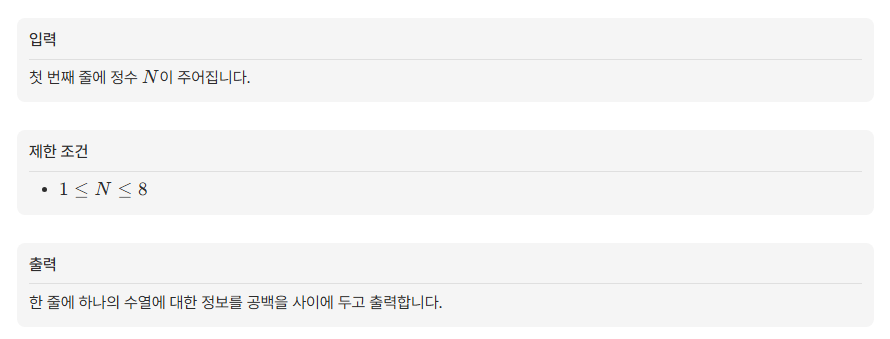

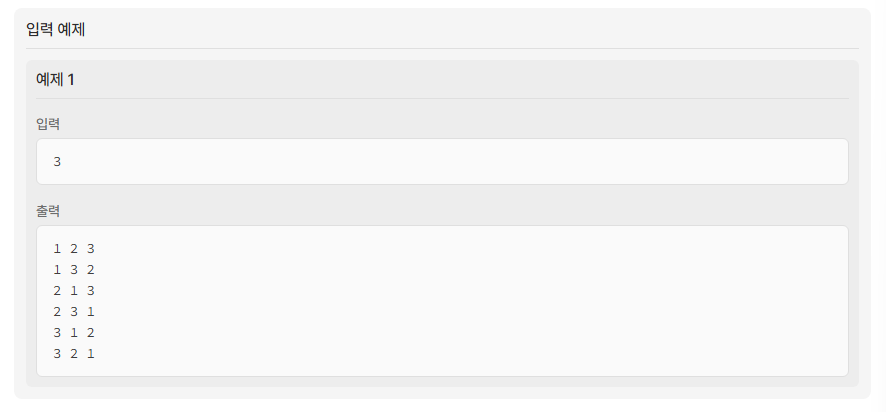

In [ ]:
# 사용자로부터 순열의 크기 N을 입력받아 정수로 변환합니다.
N = int(input())

# 뽑은 숫자를 순서대로 담아둘 빈 바구니(리스트)를 만듭니다.
selected_numbers = []

# 각 숫자를 이미 뽑았는지 확인하기 위한 체크리스트를 만듭니다.
# N이 3이라면 인덱스를 1~3까지 편하게 쓰기 위해 크기를 N + 1로 만듭니다.
# 처음에는 어떤 숫자도 뽑지 않았으므로 모두 False로 채워둡니다.
visited = [False] * (N + 1)

# 순열을 만드는 재귀 함수를 정의합니다. cnt는 현재까지 바구니에 담은 숫자의 개수입니다.
def find_permutations(cnt):
    # [종료 조건] 바구니에 담긴 숫자의 개수(cnt)가 목표치(N)와 같아졌다면?
    if cnt == N:
        # 완성된 수열을 공백을 두고 한 줄로 출력합니다.
        print(*selected_numbers)
        # 더 이상 탐색하지 않고 이전 단계로 돌아갑니다.
        return

    # 1부터 N까지의 숫자를 차례대로 확인합니다. (사전순 출력을 위해 1부터 순서대로)
    for i in range(1, N + 1):
        # [조건 검사] 만약 숫자 i를 아직 바구니에 담지 않았다면? (체크리스트가 False라면)
        if not visited[i]:
            # 1. 숫자 i를 이제 사용할 것이므로 체크리스트를 True로 바꿉니다.
            visited[i] = True

            # 2. 바구니의 맨 끝에 숫자 i를 추가합니다.
            selected_numbers.append(i)

            # 3. 숫자를 하나 추가했으므로, 개수(cnt)를 1 늘려서 다음 단계를 탐색합니다. (재귀 호출)
            find_permutations(cnt + 1)

            # 4. 다음 탐색을 마치고 돌아왔다면, 새로운 수열을 만들기 위해 상태를 원상 복구합니다.
            # 바구니에서 방금 넣었던 숫자 i를 뺍니다.
            selected_numbers.pop()

            # 다른 자리에서 숫자 i를 다시 쓸 수 있도록 체크리스트를 원래대로 False로 되돌립니다.
            visited[i] = False

# 처음에는 바구니에 담긴 숫자가 0개이므로 0을 넣고 함수를 시작합니다.
find_permutations(0)

3
1 2 3
1 3 2
2 1 3
2 3 1
3 1 2
3 2 1


# 3일차

# 그래프 탐색

40XP

평균 30분

64% 정답률

총 제출 6,249회
___
N개의 정점과 M개의 간선으로 이루어진 양방향 그래프가 주어졌을 때, 1번 정점에서 시작하여 주어진 간선을 따라 이동했을 때 도달 할 수 있는 서로 다른 정점의 수를 구하는 프로그램을 작성해보세요. (여기서 1번 정점 자기 자신에 도달하는 경우는 가지수에서 제외합니다.)

다음 예시에서 1번 정점은 2,3번 정점과 이어져 있기 때문에 답은 2가 됩니다.

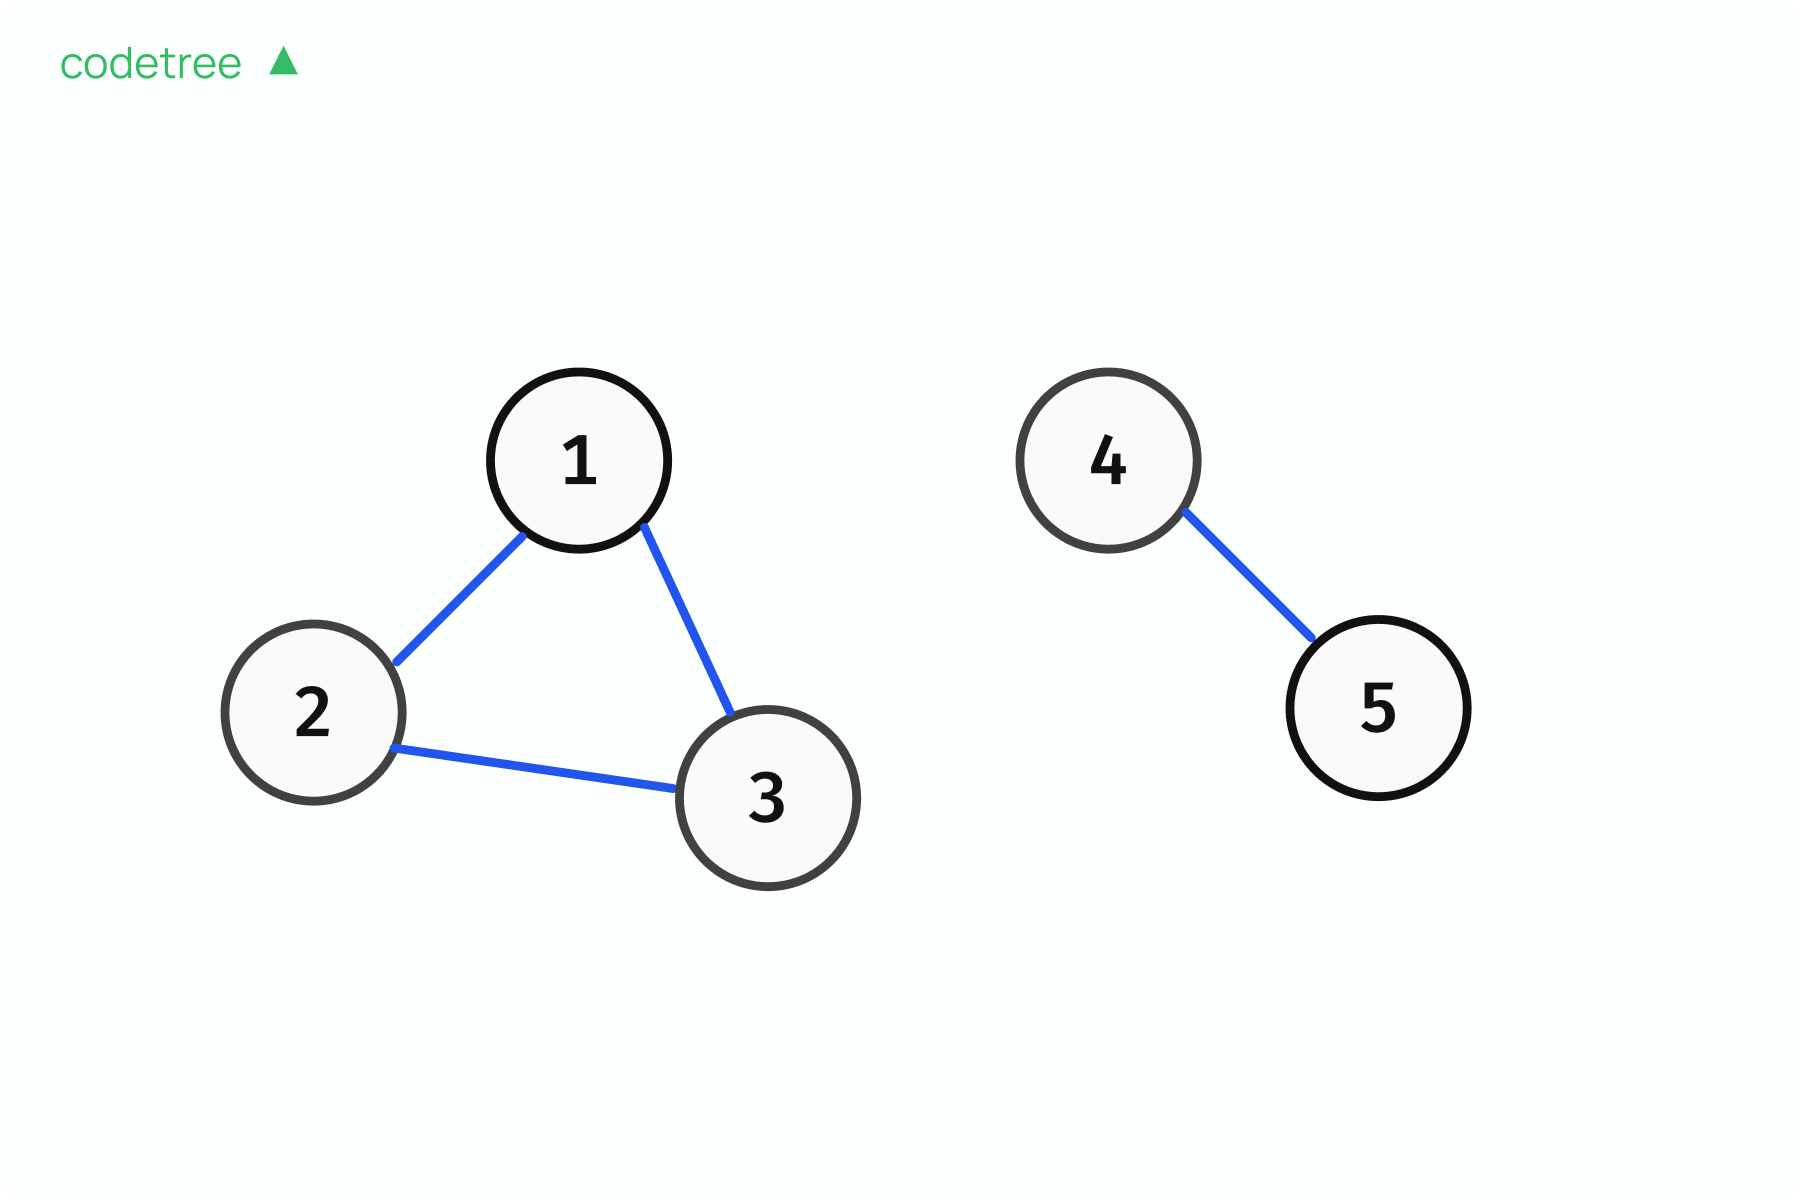

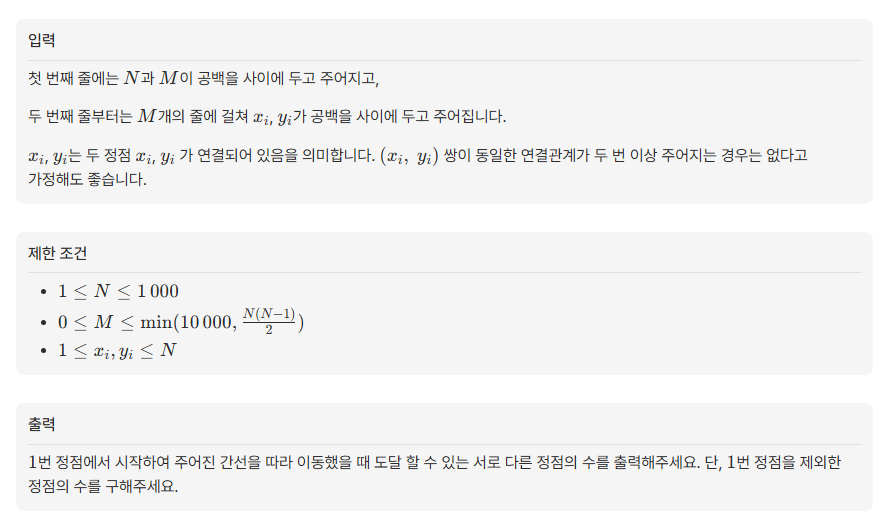

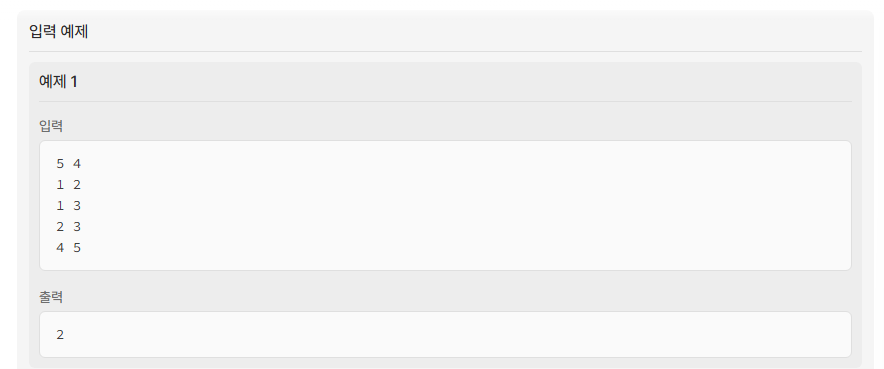

In [ ]:
# 사용자로부터 정점의 수 N과 간선의 수 M을 입력받습니다.
N, M = map(int, input().split())

# 그래프의 연결 상태를 저장할 2차원 빈 리스트(인접 리스트)를 만듭니다.
# 정점 번호가 1번부터 시작하므로 편의를 위해 N + 1 크기로 만듭니다.
graph = [[] for _ in range(N + 1)]

# M개의 간선 정보를 입력받아 그래프 지도를 그립니다.
for _ in range(M):
    # 연결된 두 정점 u, v를 입력받습니다.
    u, v = map(int, input().split())
    # 양방향 그래프이므로, u의 친구 목록에 v를 넣고, v의 친구 목록에도 u를 넣습니다.
    graph[u].append(v)
    graph[v].append(u)

# 각 정점을 방문했는지 확인하기 위한 체크리스트를 만듭니다. 모두 False로 시작합니다.
visited = [False] * (N + 1)

# 1번 정점을 제외하고 새롭게 도달할 수 있는 정점의 수를 셀 변수입니다.
reachable_count = 0

# 깊이 우선 탐색(DFS) 재귀 함수를 정의합니다.
# current_node: 현재 내가 서 있는 정점의 번호
def dfs(current_node):
    # 전역 변수인 reachable_count를 변경하기 위해 global을 선언합니다.
    global reachable_count

    # 현재 정점(current_node)과 직접 연결된 다음 정점(next_node)들을 하나씩 확인합니다.
    for next_node in graph[current_node]:
        # [조건] 만약 그 다음 정점을 아직 방문하지 않았다면?
        if not visited[next_node]:
            # 1. 이제 방문할 것이므로 체크리스트에 True로 표시합니다.
            visited[next_node] = True

            # 2. 1번 정점에서 새롭게 도달한 곳이므로 개수를 1 증가시킵니다.
            reachable_count += 1

            # 3. 새롭게 방문한 그 정점으로 이동해서 다시 탐색을 이어갑니다. (재귀 호출)
            dfs(next_node)

# 탐색을 시작하기 전, 출발점인 1번 정점은 '방문 완료' 처리를 해줍니다.
# (그래야 다른 곳을 탐색하다가 1번으로 다시 돌아오는 불상사를 막을 수 있습니다.)
visited[1] = True

# 1번 정점부터 DFS 탐색을 본격적으로 시작합니다.
dfs(1)

# 모든 탐색이 끝난 후, 도달한 정점의 총 개수를 출력합니다.
print(reachable_count)

5 4
1 2
1 3
2 3
4 5
2


# 두 방향 탈출 가능 여부 판별하기

40XP

평균 25분

46% 정답률

총 제출 7,037회
___
N×M 크기의 이차원 영역의 좌측 상단에서 출발하여 우측 하단까지 뱀에게 물리지 않고 탈출하려고 합니다. 이동을 할 때에는 반드시 아래와 오른쪽 두 방향 중 인접한 칸으로만 이동할 수 있으며, 뱀이 있는 칸으로는 이동을 할 수 없습니다. 예를 들어 <그림 1>과 같이 뱀이 배치 되어 있는 경우 실선과 같은 경로로 탈출을 할 수 있습니다. 이 때 뱀에게 물리지 않고 탈출 가능한 경로가 있는지 여부를 판별하는 코드를 작성해보세요.

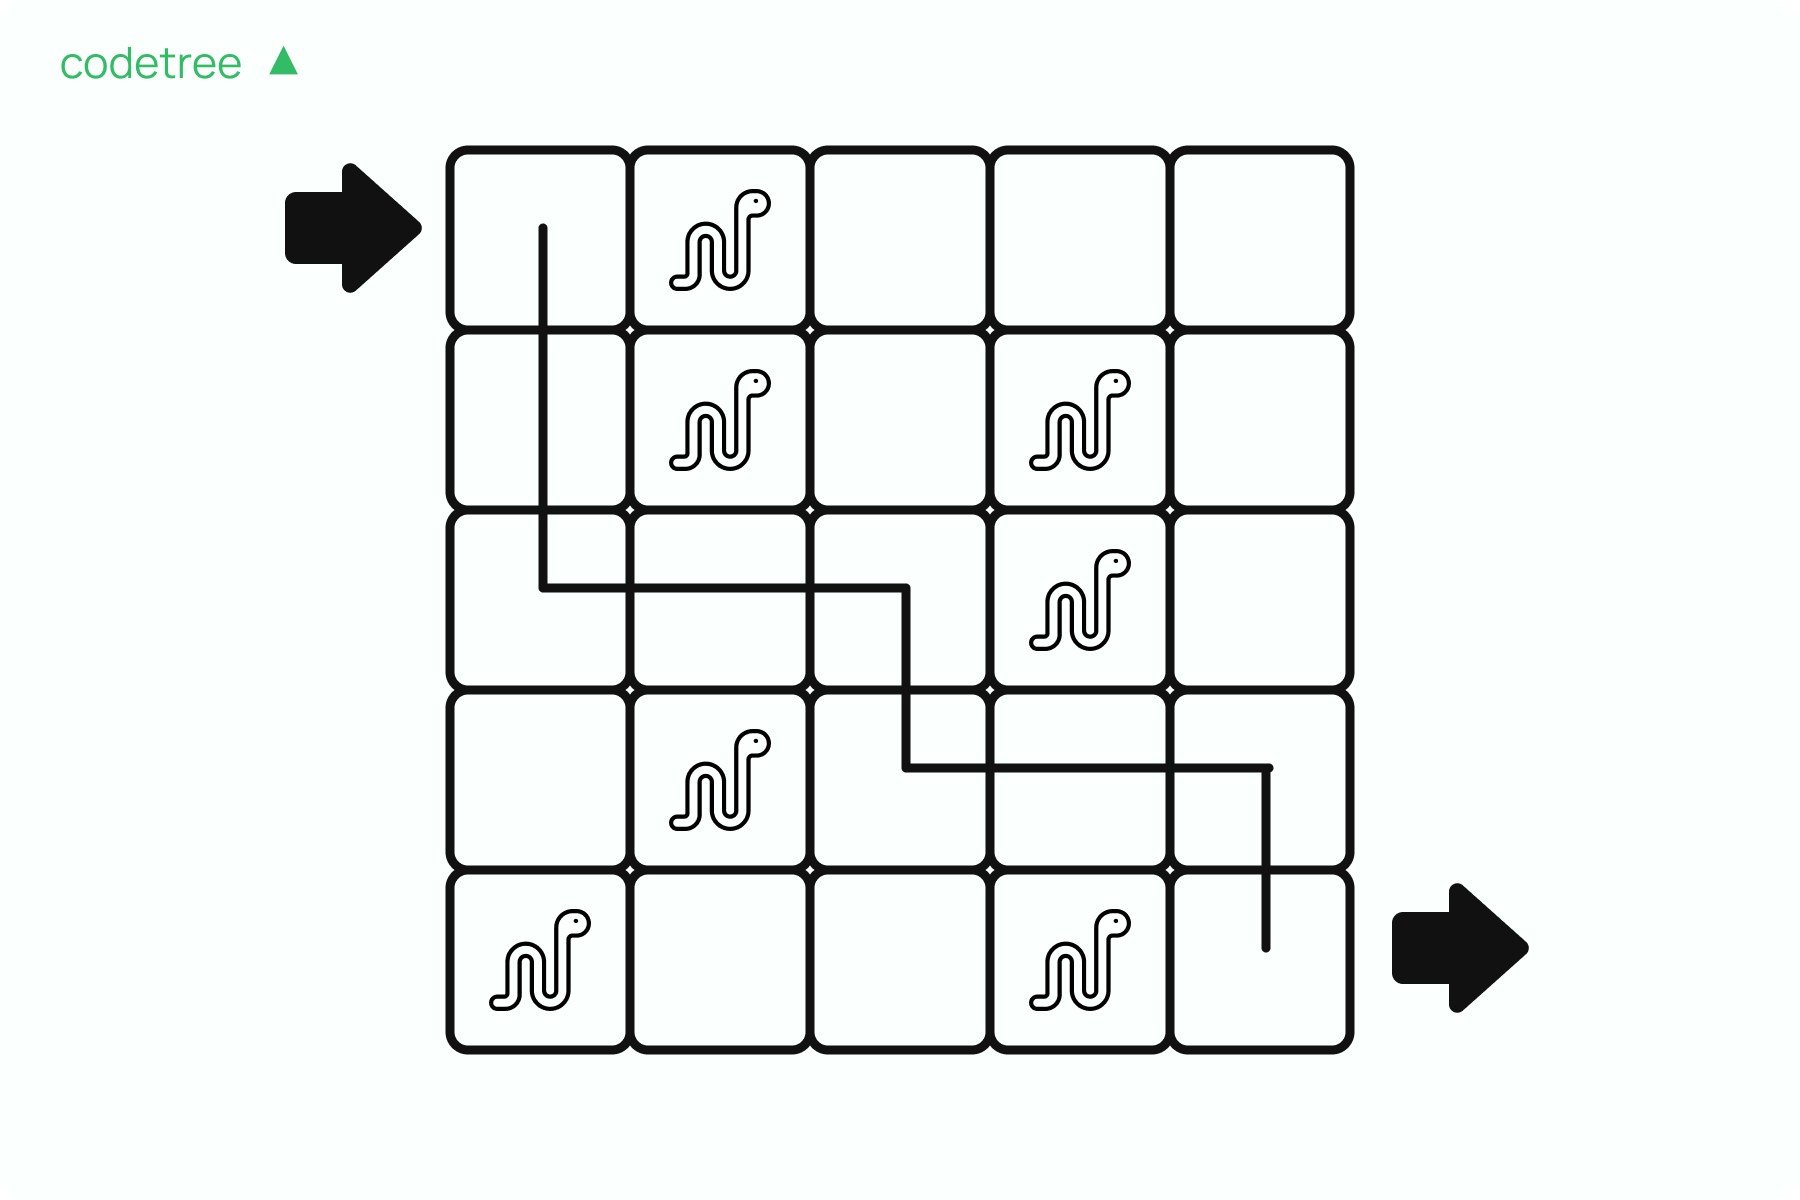

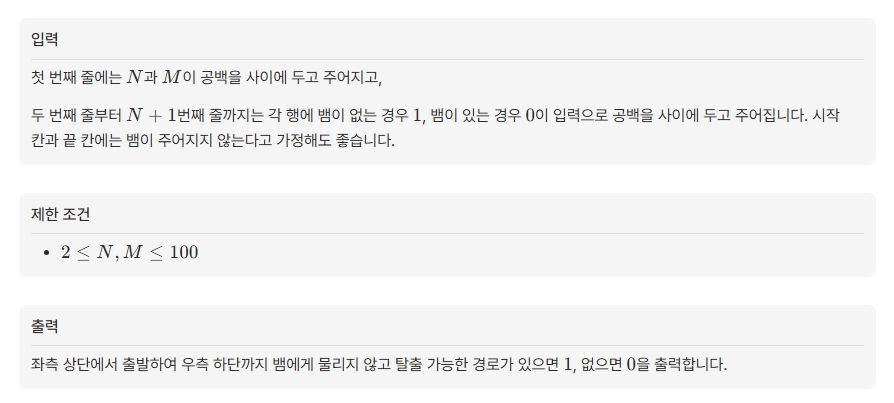

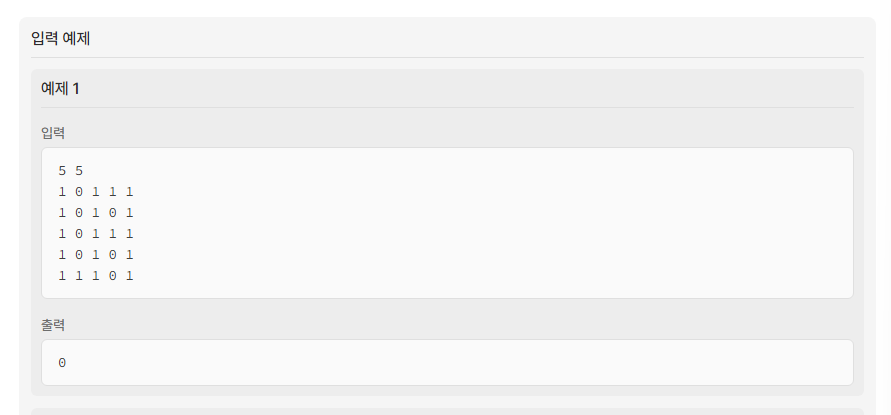

In [ ]:
# 사용자로부터 격자의 크기 N(행)과 M(열)을 입력받습니다.
N, M = map(int, input().split())

# 뱀과 길의 정보가 담긴 N x M 크기의 2차원 지도를 입력받습니다.
# for문을 N번 반복하며 한 줄씩 리스트로 만들어 2차원 리스트를 구성합니다.
grid = [list(map(int, input().split())) for _ in range(N)]

# 방문 여부를 체크할 N x M 크기의 2차원 체크리스트를 만듭니다.
# 처음에는 아무 곳도 방문하지 않았으므로 모두 False로 채웁니다.
visited = [[False] * M for _ in range(N)]

# 이동할 방향을 정해주는 방향키 배열을 만듭니다. (매우 중요!)
# 문제에서 아래와 오른쪽으로만 이동 가능하다고 했습니다.
# [아래로 이동, 오른쪽으로 이동]을 의미합니다.
dx = [1, 0] # 행(x)의 변화량: 아래로 가면 1 증가, 오른쪽으로 가면 그대로(0)
dy = [0, 1] # 열(y)의 변화량: 아래로 가면 그대로(0), 오른쪽으로 가면 1 증가

# 해당 좌표(x, y)가 지도의 범위 안에 있는지 확인하는 함수입니다.
def in_range(x, y):
    # x가 0 이상 N 미만이고, y가 0 이상 M 미만이면 True를 반환합니다.
    return 0 <= x < N and 0 <= y < M

# 해당 좌표(x, y)로 이동할 수 있는지 종합적으로 검사하는 함수입니다.
def can_go(x, y):
    # 1. 지도를 벗어났다면 갈 수 없습니다.
    if not in_range(x, y):
        return False
    # 2. 이미 방문했던 곳이거나, 뱀이 있는 곳(0)이라면 갈 수 없습니다.
    if visited[x][y] or grid[x][y] == 0:
        return False
    # 위의 모든 조건을 무사히 통과했다면 갈 수 있는 안전한 곳입니다.
    return True

# 깊이 우선 탐색(DFS)을 수행할 재귀 함수를 정의합니다.
def dfs(x, y):
    # 현재 위치(x, y)에 도착했으므로 방문 처리를 합니다.
    visited[x][y] = True

    # 2가지 방향(아래, 오른쪽)을 순서대로 살펴봅니다.
    for i in range(2):
        # 현재 위치에서 dx, dy를 더해 다음으로 이동할 위치(nx, ny)를 계산합니다.
        nx = x + dx[i]
        ny = y + dy[i]

        # 만약 그 다음 위치로 이동할 수 있다면? (can_go 함수 통과)
        if can_go(nx, ny):
            # 그 위치로 이동해서 탐색을 계속 이어나갑니다. (재귀 호출)
            dfs(nx, ny)

# 가장 처음 시작점인 좌측 상단 (0, 0)에서 탐색을 시작합니다.
dfs(0, 0)

# 모든 탐색이 끝난 후, 목적지인 우측 하단 (N-1, M-1)에 도달했는지 확인합니다.
# 인덱스는 0부터 시작하므로 N크기면 N-1이 마지막 칸입니다.
if visited[N-1][M-1] == True:
    print(1) # 도달했다면 1 출력
else:
    print(0) # 도달하지 못했다면 0 출력

5 5
1 0 1 1 1
1 0 1 0 1
1 0 1 1 1
1 0 1 0 1
1 1 1 0 1
0


# 마을 구분하기

70XP

평균 46분

77% 정답률

총 제출 3,211회
___
N×N크기의 이차원 영역에 사람 혹은 벽이 놓여져있습니다. 이 때 상하좌우의 인접한 영역에 있는 사람들은 같은 마을에 있는 것으로 간주한다고 합니다. 예를 들어 그림과 같이 사람과 벽이 배치되어 있는 경우, 그림 안의 점선과 같이 마을을 나눌 수 있습니다. 이 때 총 마을의 개수와 같은 마을에 있는 사람의 수를 오름차순으로 정렬하여 출력하는 코드를 작성해보세요.


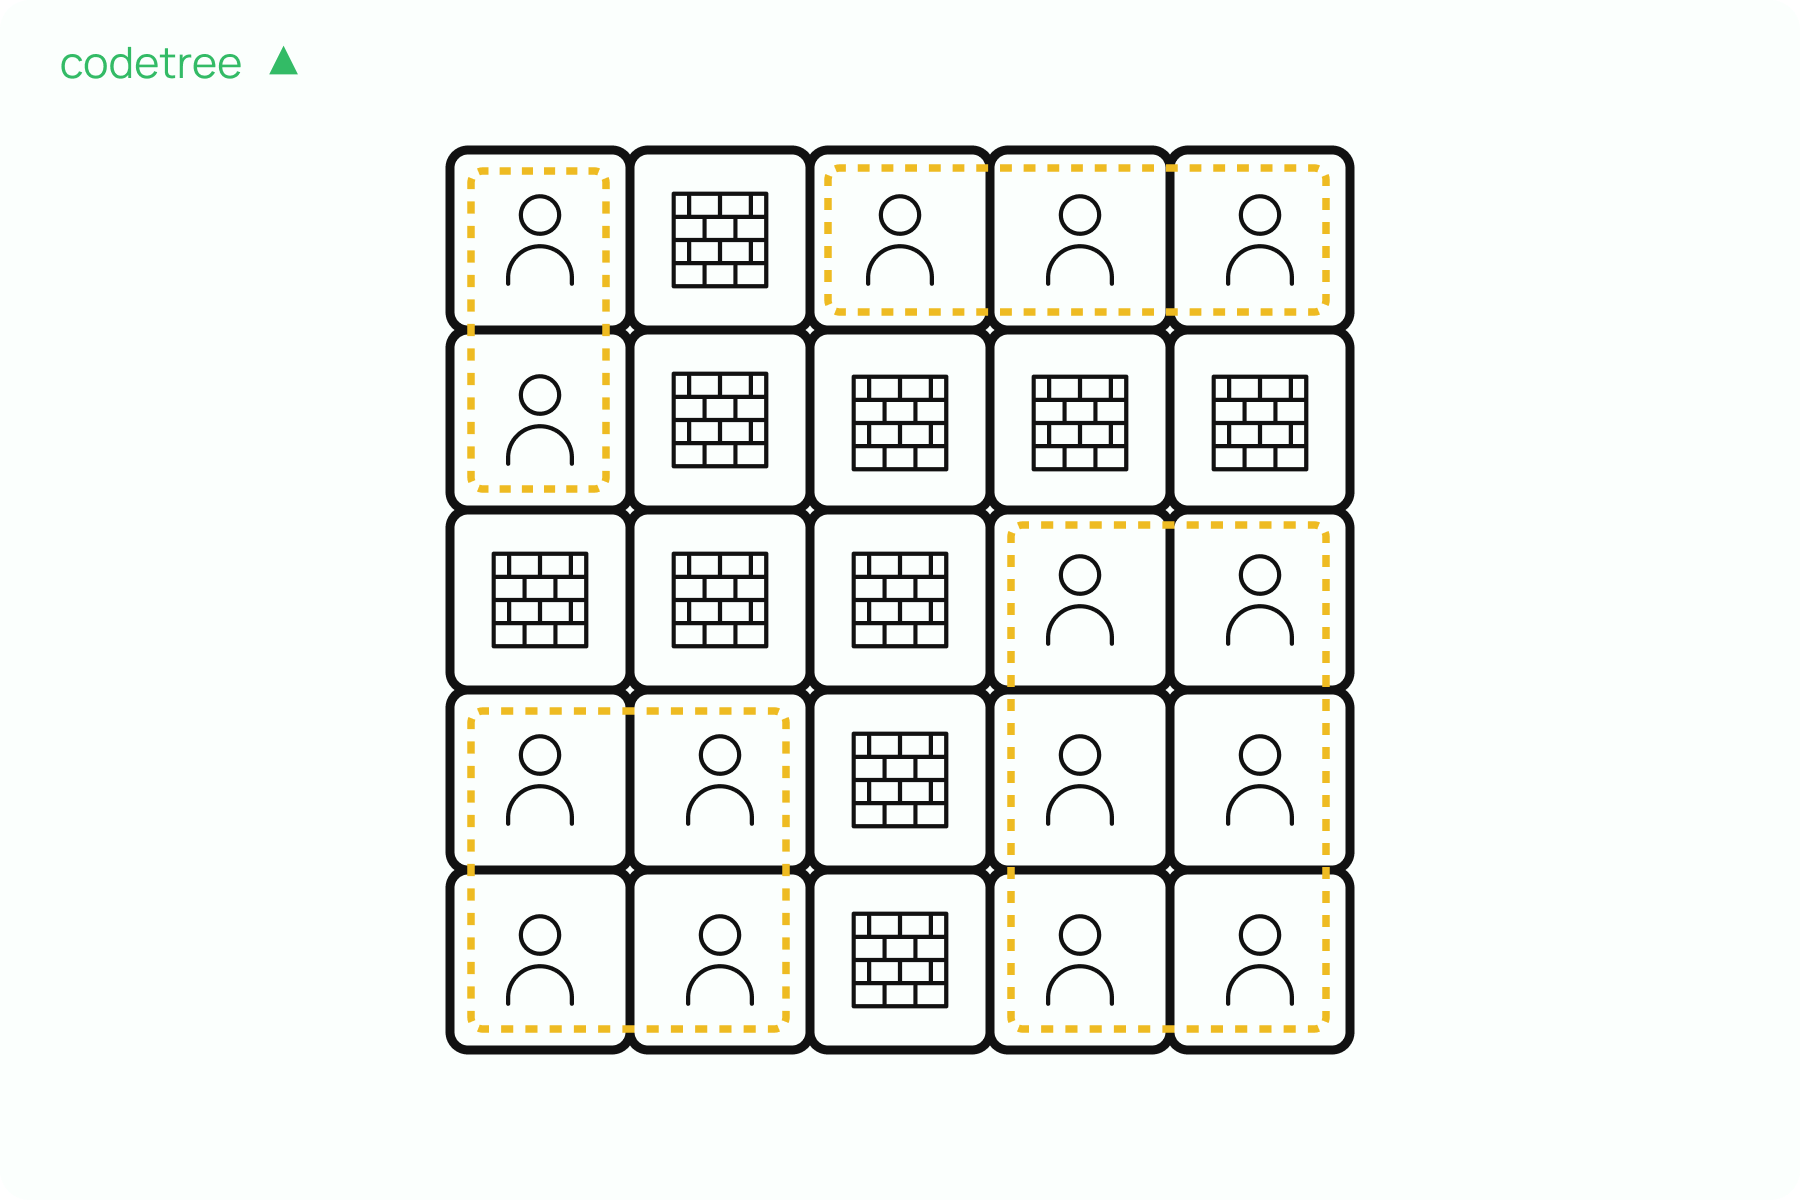

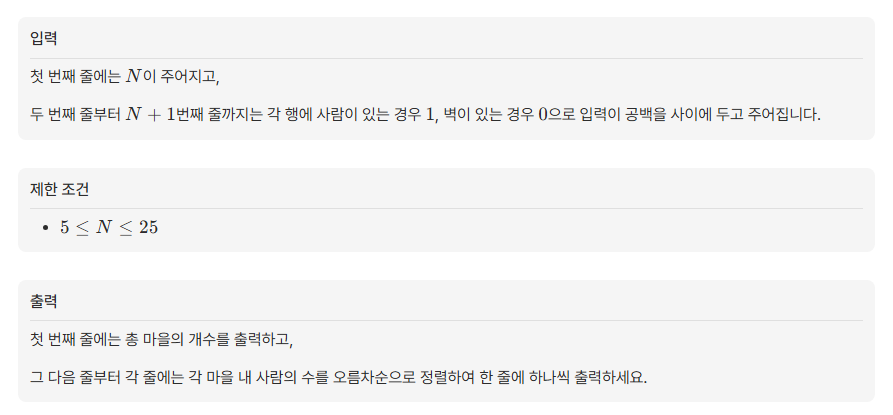

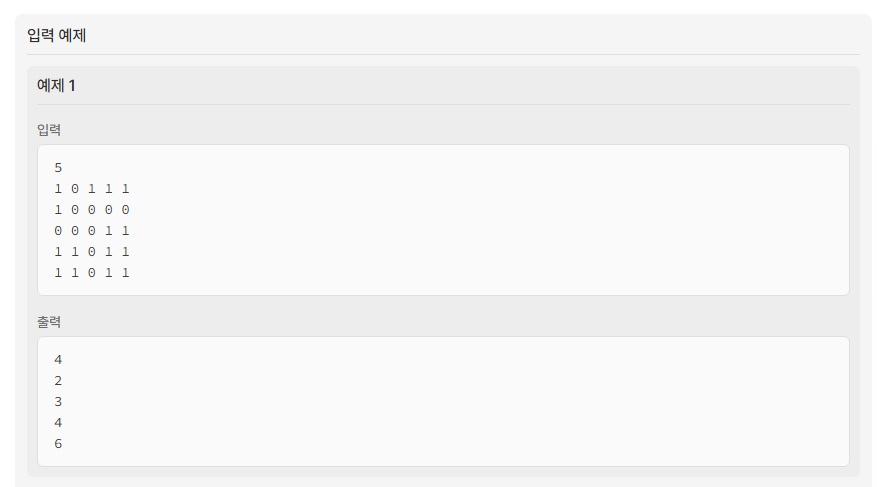

In [ ]:
# 사용자로부터 격자의 크기 N을 입력받습니다.
N = int(input())

# 사람(1)과 벽(0)의 정보가 담긴 N x N 크기의 2차원 지도를 입력받습니다.
grid = [list(map(int, input().split())) for _ in range(N)]

# 방문 여부를 체크할 N x N 크기의 2차원 체크리스트를 만들고 모두 False로 채웁니다.
visited = [[False] * N for _ in range(N)]

# 이동할 방향을 정해주는 방향키 배열을 만듭니다. (상, 하, 좌, 우 4방향)
# dx: 행(x)의 변화량 / dy: 열(y)의 변화량
dx = [-1, 1, 0, 0] # 위쪽(-1), 아래쪽(1), 왼쪽(0), 오른쪽(0)
dy = [0, 0, -1, 1] # 위쪽(0), 아래쪽(0), 왼쪽(-1), 오른쪽(1)

# 각 마을의 사람 수를 저장할 빈 리스트를 만듭니다.
village_sizes = []

# 현재 탐색 중인 마을의 사람 수를 셀 전역 변수입니다.
current_people_count = 0

# 해당 좌표(x, y)가 지도의 범위 안에 있는지 확인하는 함수입니다.
def in_range(x, y):
    # x와 y가 모두 0 이상 N 미만이면 True를 반환합니다.
    return 0 <= x < N and 0 <= y < N

# 해당 좌표(x, y)로 이동하여 탐색할 수 있는지 검사하는 함수입니다.
def can_go(x, y):
    # 1. 지도를 벗어났다면 갈 수 없습니다.
    if not in_range(x, y):
        return False
    # 2. 이미 방문했던 곳이거나, 벽(0)이라면 갈 수 없습니다.
    if visited[x][y] or grid[x][y] == 0:
        return False
    # 안전하고 아직 방문 안 한 사람(1)이라면 갈 수 있습니다.
    return True

# 한 마을의 사람들을 모두 찾아내는 DFS 재귀 함수입니다.
def dfs(x, y):
    # 전역 변수인 current_people_count를 1씩 늘려주기 위해 global 키워드를 씁니다.
    global current_people_count

    # 현재 위치(사람)를 방문 처리합니다.
    visited[x][y] = True

    # 마을 사람을 한 명 찾았으므로 카운터를 1 증가시킵니다.
    current_people_count += 1

    # 상, 하, 좌, 우 4가지 방향을 순서대로 살펴봅니다.
    for i in range(4):
        # 현재 위치에서 dx, dy를 더해 다음 위치(nx, ny)를 구합니다.
        nx = x + dx[i]
        ny = y + dy[i]

        # 만약 그 방향으로 갈 수 있다면 (이웃한 사람이 있다면)?
        if can_go(nx, ny):
            # 연결된 사람을 찾기 위해 그 위치로 이동하여 다시 DFS를 이어갑니다.
            dfs(nx, ny)

# 1. 지도의 모든 칸(0,0 부터 N-1,N-1 까지)을 하나씩 검사합니다.
for i in range(N):
    for j in range(N):
        # 2. 만약 해당 칸이 방문한 적 없는 사람(1)이라면? -> 새로운 마을 발견!
        if can_go(i, j):
            # 3. 새로운 마을의 사람 수를 세기 위해 카운터를 0으로 초기화합니다.
            current_people_count = 0

            # 4. DFS 탐색을 시작하여 이 마을에 속한 모든 사람을 찾아 방문 처리하고 인원수를 셉니다.
            dfs(i, j)

            # 5. 마을 탐색이 완전히 끝났다면, 기록된 사람 수를 리스트에 추가합니다.
            village_sizes.append(current_people_count)

# 찾은 마을의 총개수(리스트의 길이)를 출력합니다.
print(len(village_sizes))

# 마을 안의 사람 수를 오름차순(작은 수부터 큰 수 순서)으로 정렬합니다.
village_sizes.sort()

# 정렬된 사람 수를 하나씩 꺼내어 출력합니다.
for size in village_sizes:
    print(size)

5
1 0 1 1 1
1 0 0 0 0
0 0 0 1 1
1 1 0 1 1
1 1 0 1 1
4
2
3
4
6


# 안전 지대

70XP

평균 80분

33% 정답률

총 제출 5,608회
___
N×M 크기의 격자로 구성된 마을이 있습니다. 격자마다 한 집을 의미하며, 각 집의 높이는 1이상 100이하의 숫자로 이루어져 있습니다.
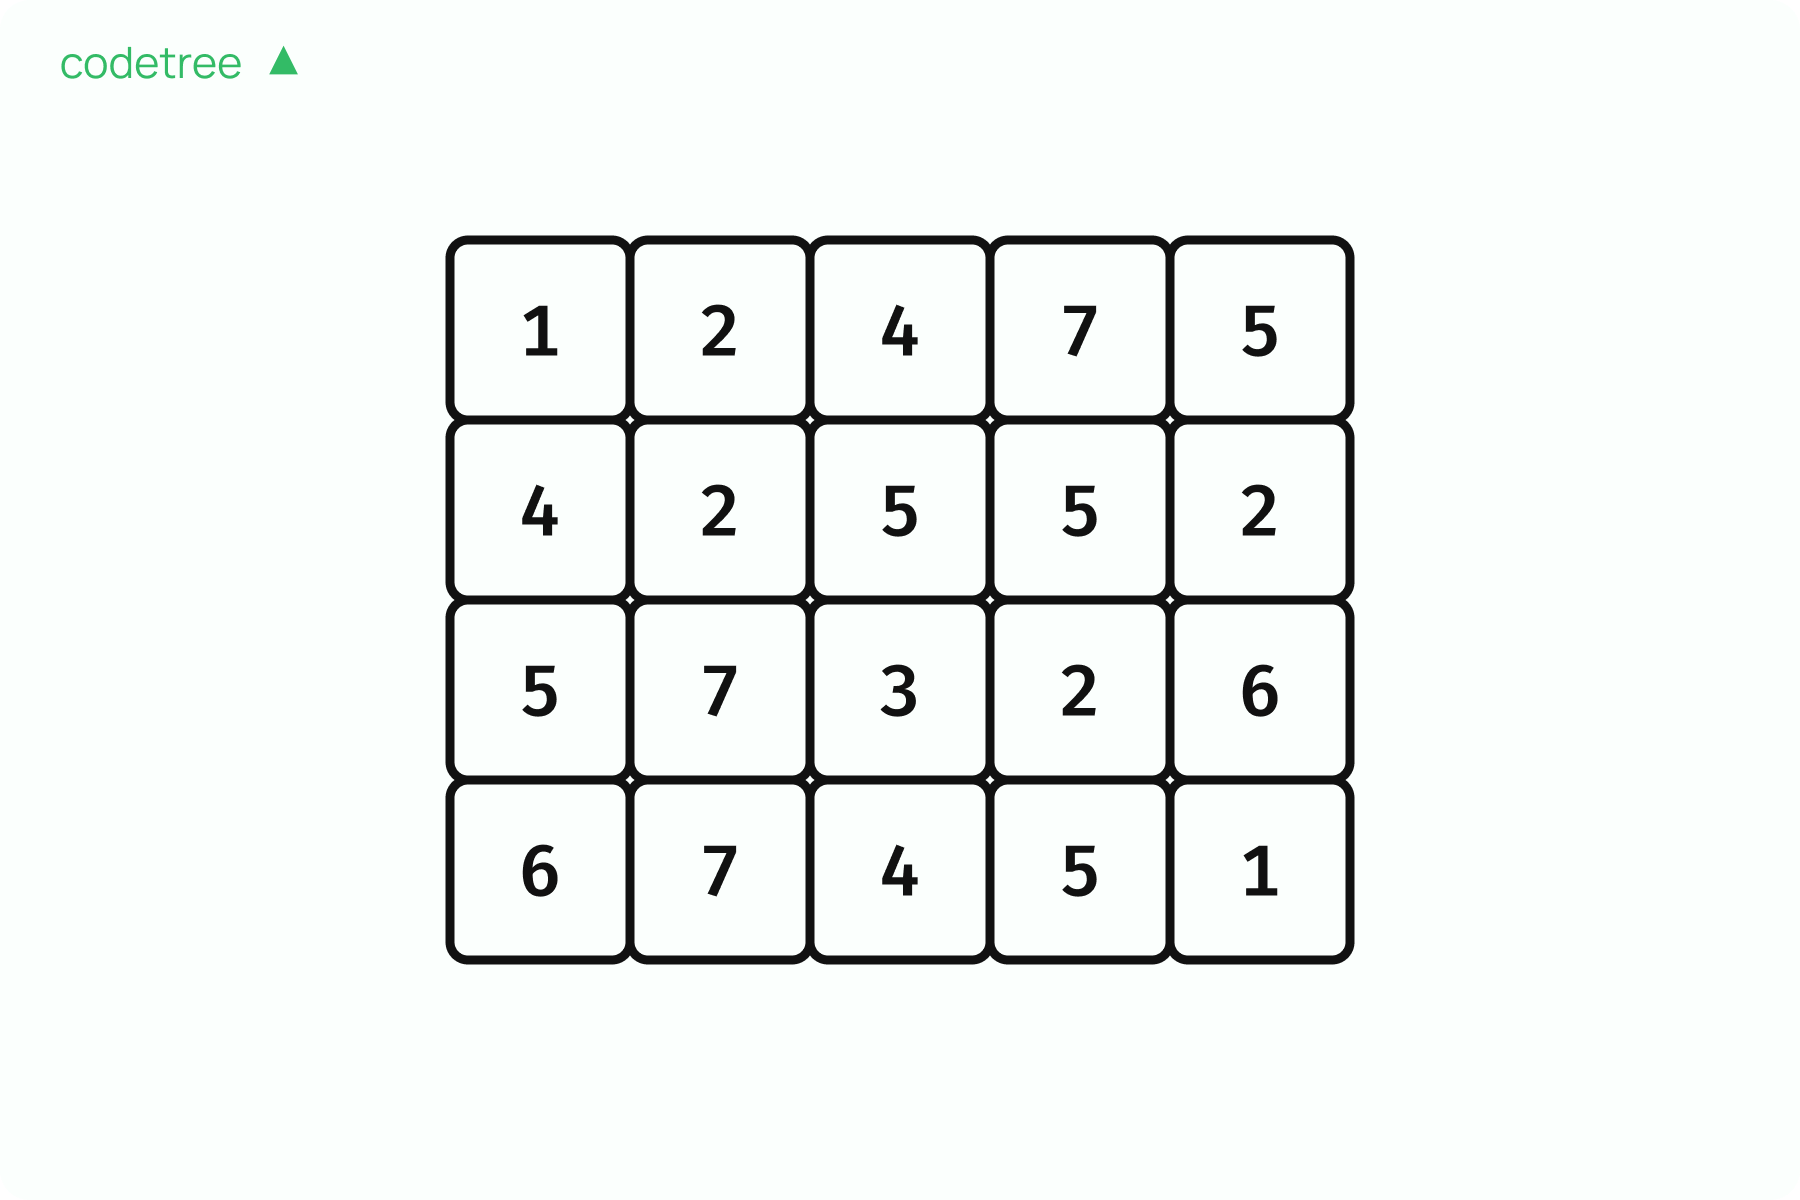


이런 상황에서 만약 비가 K(K≥1)만큼 온다고 한다면, 마을에 있는 집들 중 높이가 K 이하인 집들은 전부 물에 잠기게 되기 때문에, 대책을 세우기 위해 미리 각 K에 따라 안전 영역의 개수가 어떻게 달라지는지를 보려고 합니다. 여기서 안전 영역이란 잠기지 않은 집들로 이루어져 있으며, 잠기지 않은 집들끼리 서로 인접해 있는 경우 동일한 안전 영역에 있는 것으로 봅니다.

위의 예에서 K=1인 경우에는 안전한 영역은 1개 입니다.
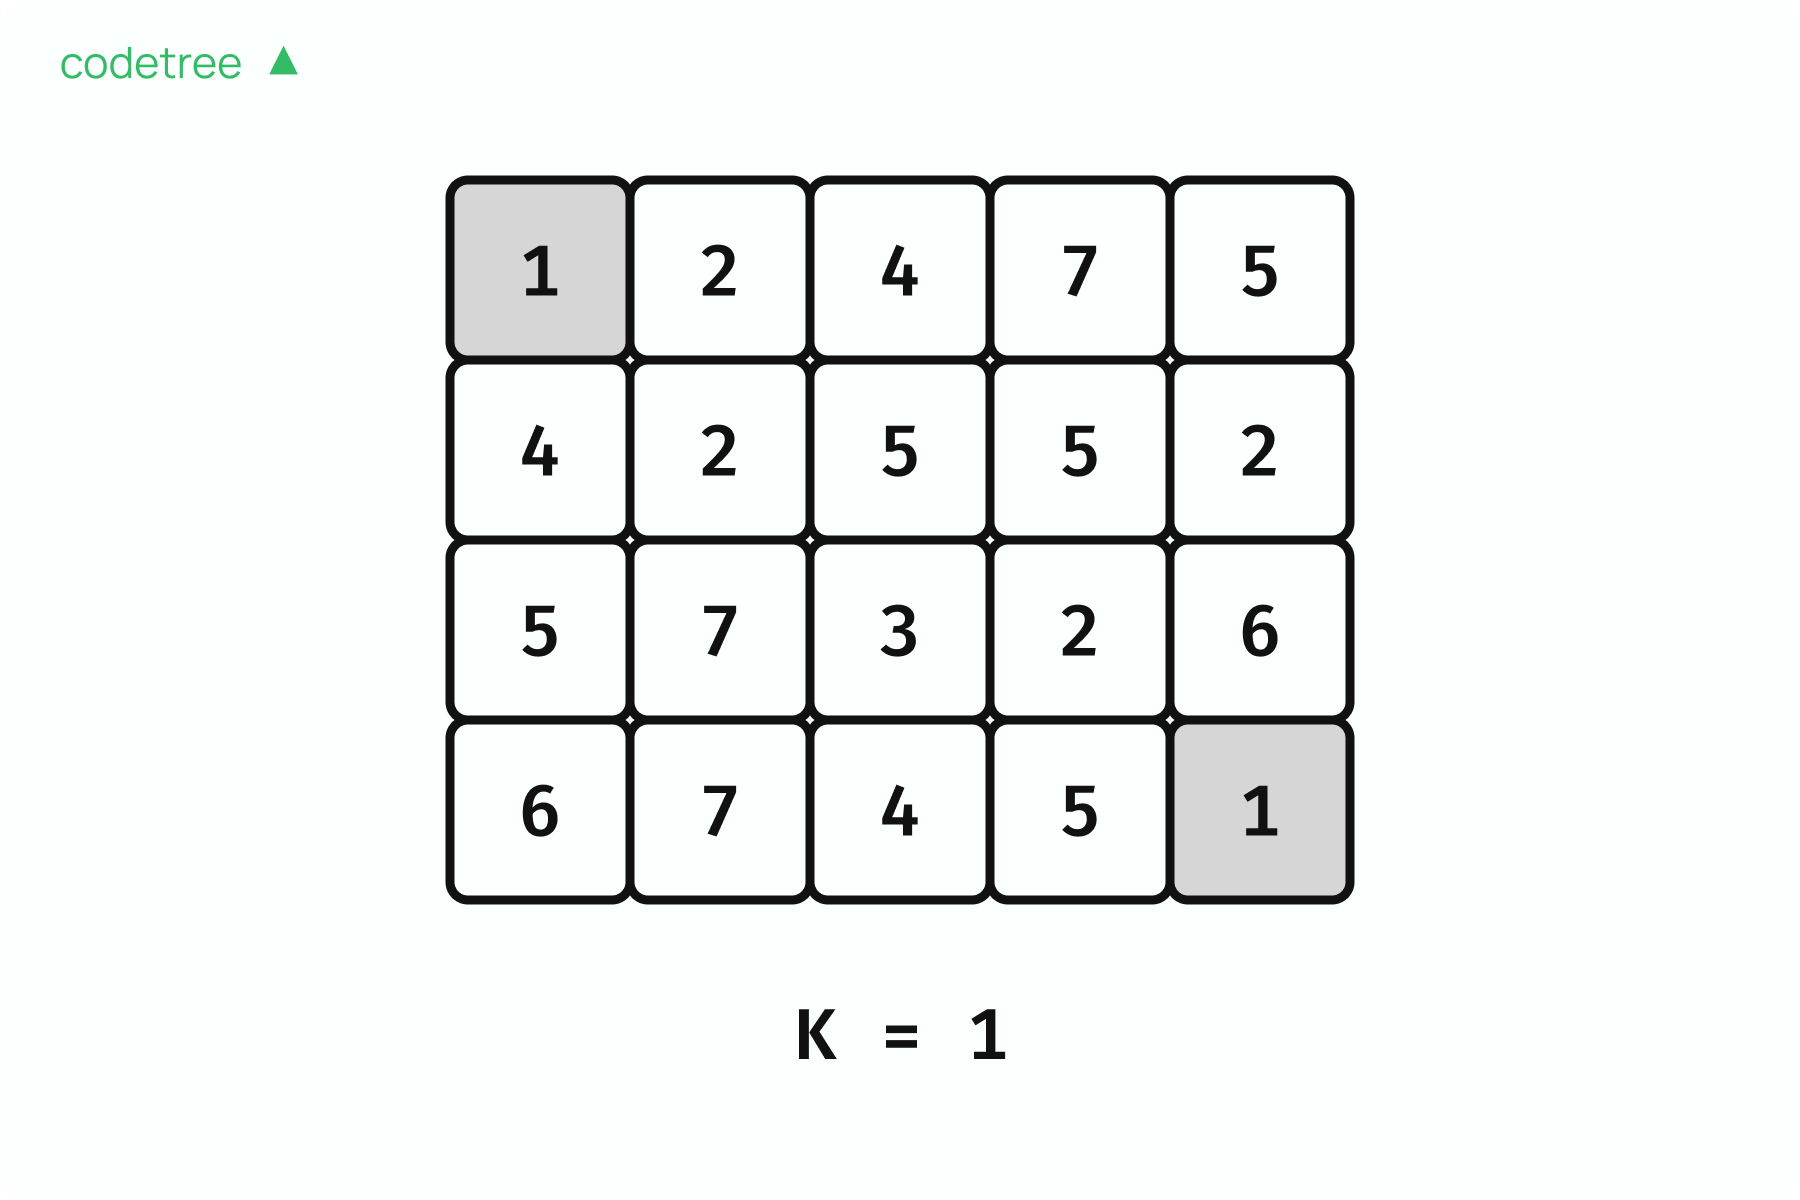


K=3 인 경우에는 안전 영역의 수가 3이 되며
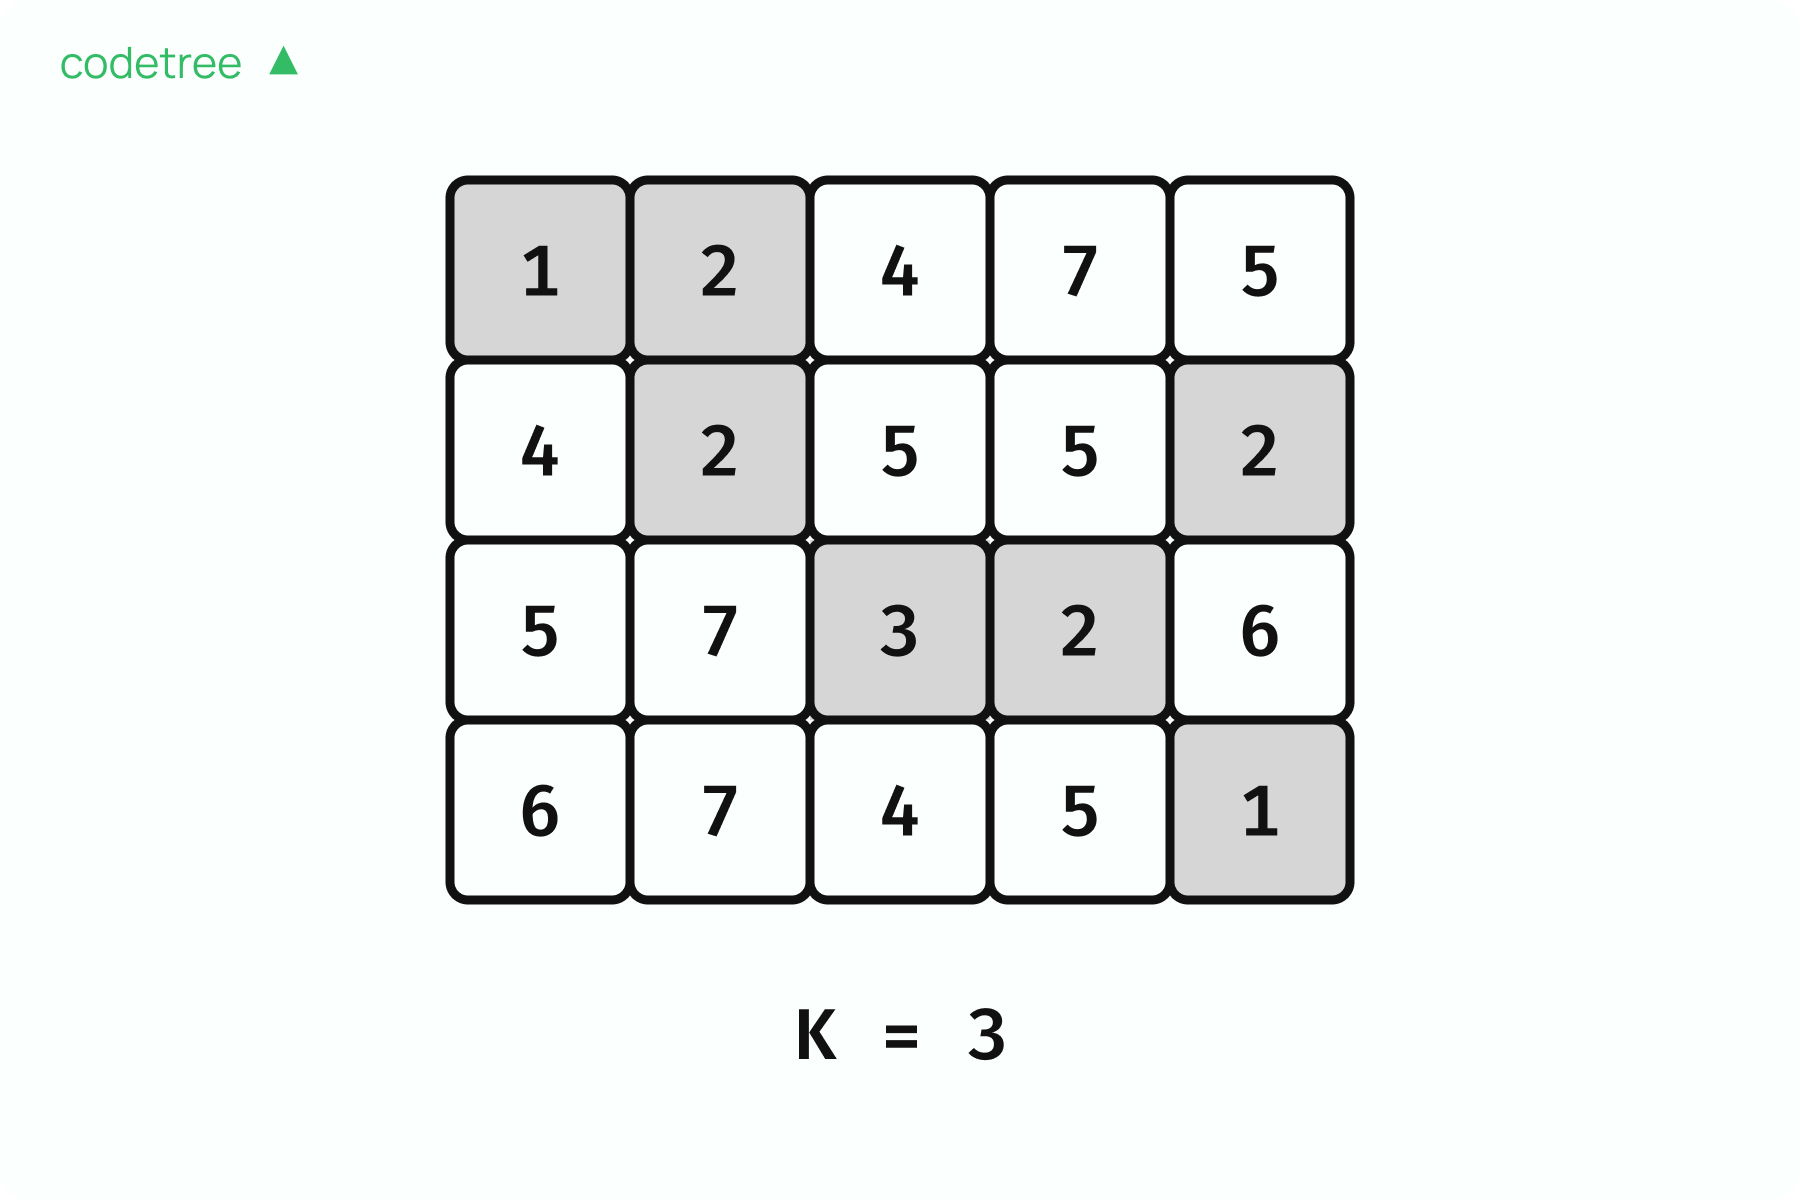


K=4 일때는 안전 영역의 수가 4가 됩니다.
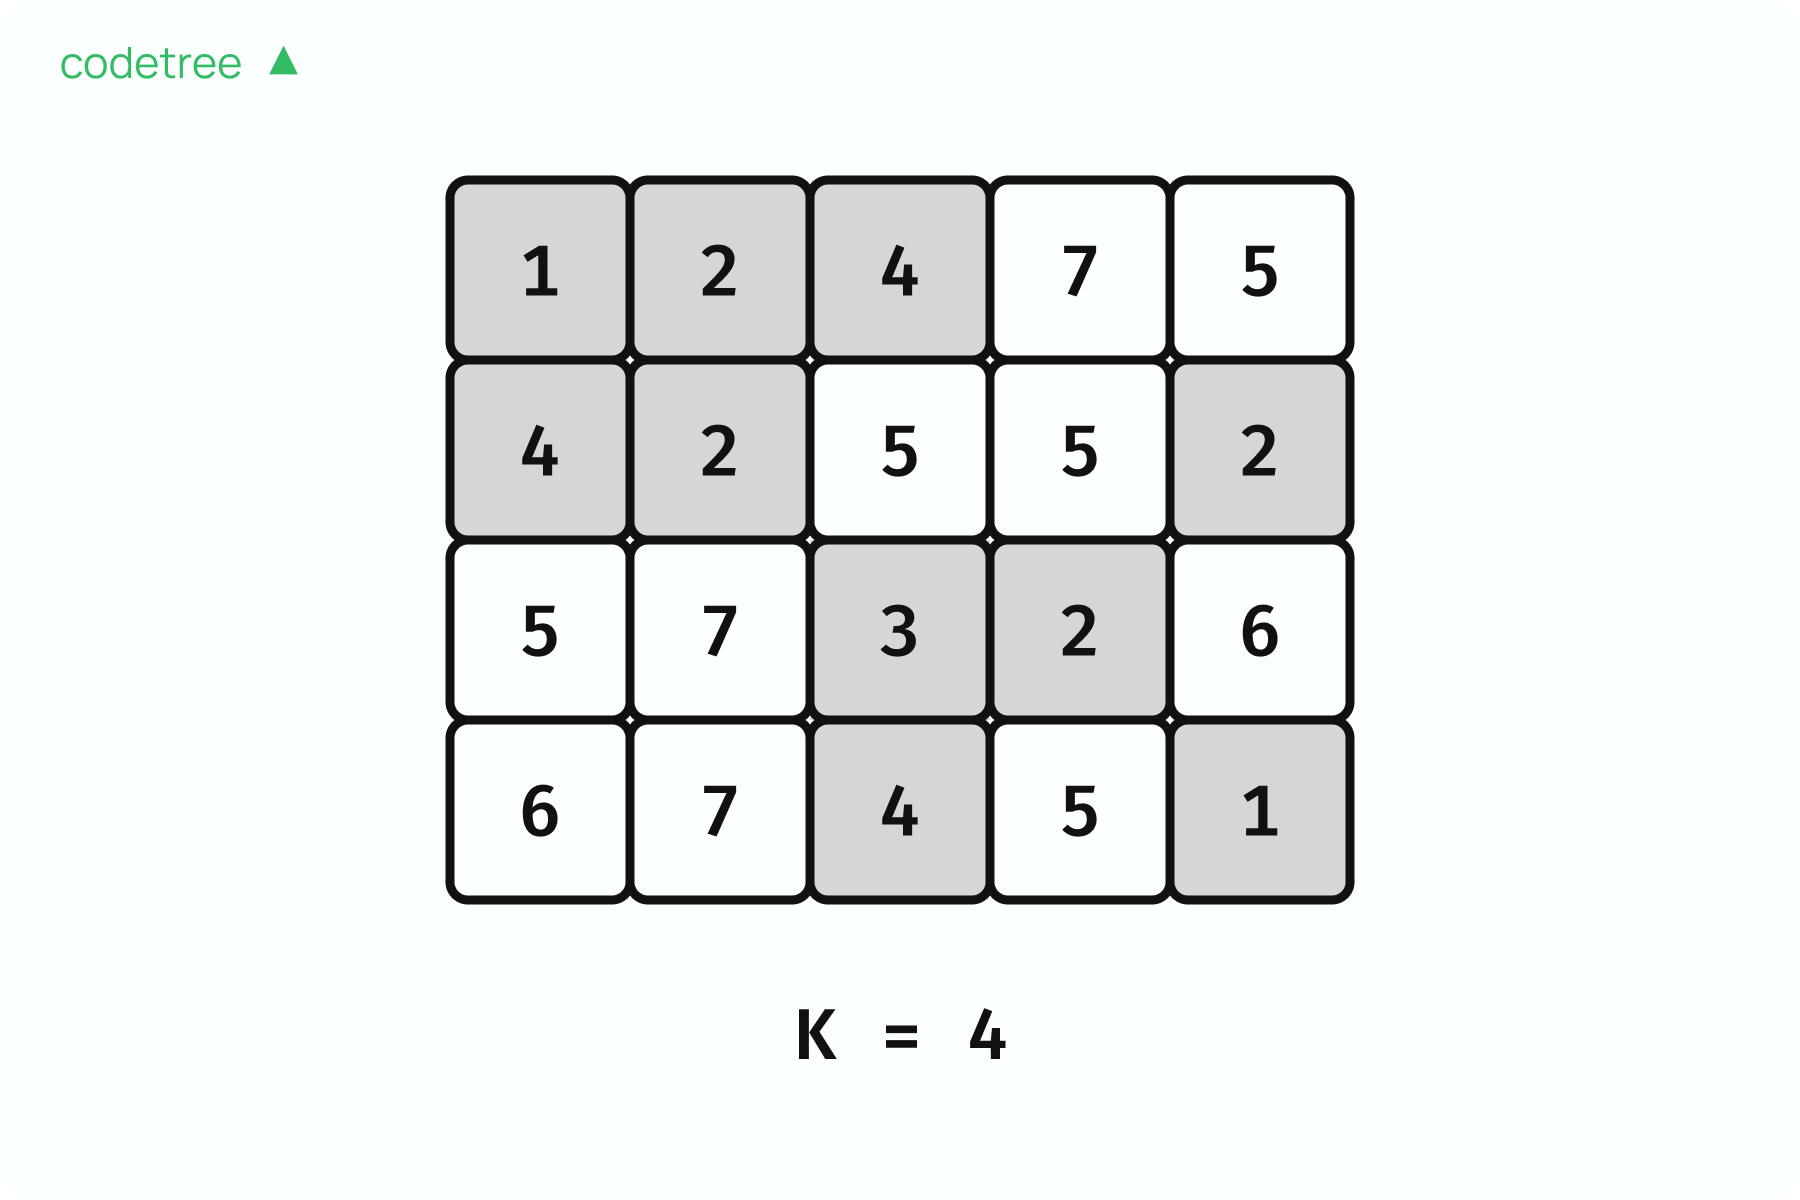



이런 상황에서 안전 영역의 수가 최대가 될때의 K와 그때의 안전 영역의 수를 구해주는 프로그램을 작성해보세요.

위의 예에서는 K=4일때 안전 영역의 수가 4로 최대가 됩니다.

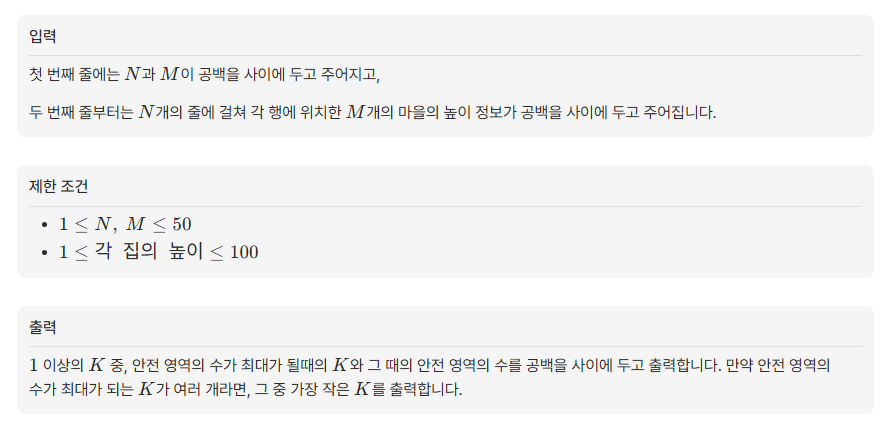

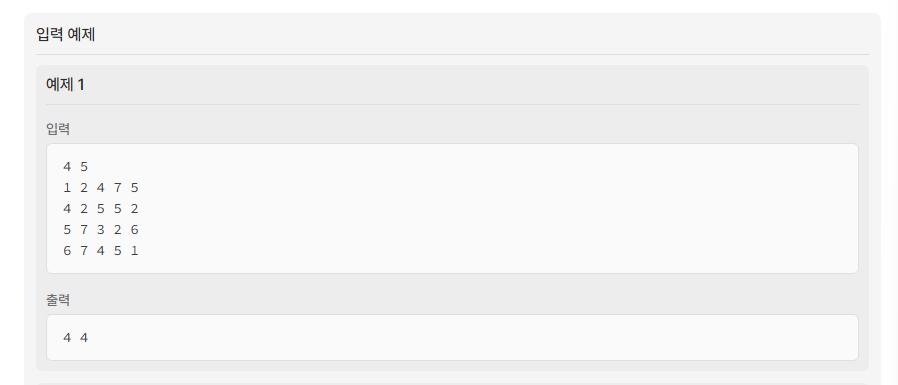

In [ ]:
# 사용자로부터 마을의 크기 N(행)과 M(열)을 입력받습니다.
N, M = map(int, input().split())

# 마을의 집 높이 정보가 담긴 2차원 지도를 입력받습니다.
grid = [list(map(int, input().split())) for _ in range(N)]

# 마을에서 가장 높은 집의 높이를 찾습니다. (비를 이 높이까지만 내려보면 됩니다)
# 각 줄(row)의 최댓값들 중 가장 큰 값을 찾아 max_height에 저장합니다.
max_height = 0
for row in grid:
    if max(row) > max_height:
        max_height = max(row)

# 이동할 방향을 정해주는 방향키 배열입니다. (상, 하, 좌, 우)
dx = [-1, 1, 0, 0]
dy = [0, 0, -1, 1]

# 정답을 저장할 변수입니다.
# max_safe_areas: 가장 많았던 안전 영역의 수 (초기값은 -1)
# best_k: 그때의 비의 양 K
max_safe_areas = -1
best_k = 0

# 특정 비의 양(K)에 대해 안전 영역의 개수를 구해주는 함수입니다.
def get_safe_areas(K):
    # 각 K마다 방문 기록을 새로 해야 하므로, 함수 안에서 visited를 0으로 초기화합니다.
    visited = [[False] * M for _ in range(N)]
    safe_areas = 0 # 이번 K에서 찾은 안전 영역의 개수

    # 지도의 모든 칸을 스캔합니다.
    for i in range(N):
        for j in range(M):
            # 만약 현재 칸이 아직 방문하지 않았고, 비(K)보다 높아서 안전하다면? -> 새로운 영역 발견!
            if not visited[i][j] and grid[i][j] > K:
                safe_areas += 1 # 영역 개수를 1 증가시킵니다.

                # ------ 여기서부터 '스택'을 이용한 반복문 DFS가 시작됩니다 ------

                # 재귀 대신 리스트(스택)에 시작 위치를 넣고 방문 처리합니다.
                stack = [(i, j)]
                visited[i][j] = True

                # 스택에 탐색할 곳이 남아있는 동안 계속 반복합니다.
                while stack:
                    # 스택의 맨 위(가장 최근에 넣은 곳)에서 위치(x, y)를 하나 꺼냅니다.
                    x, y = stack.pop()

                    # 현재 위치에서 상하좌우 4방향을 살펴봅니다.
                    for d in range(4):
                        nx = x + dx[d]
                        ny = y + dy[d]

                        # 1. 지도를 벗어나지 않았고
                        if 0 <= nx < N and 0 <= ny < M:
                            # 2. 아직 방문하지 않았으며, 3. 비(K)보다 높아서 안전한 곳이라면?
                            if not visited[nx][ny] and grid[nx][ny] > K:
                                # 방문했다고 체크한 뒤
                                visited[nx][ny] = True
                                # 다음번에 탐색하기 위해 스택에 추가합니다.
                                stack.append((nx, ny))

                # -----------------------------------------------------------

    # 지도를 다 돌았으면 총 안전 영역의 개수를 반환합니다.
    return safe_areas

# 비의 양 K를 1부터 가장 높은 집의 높이(max_height)까지 증가시키며 확인합니다.
for current_k in range(1, max_height + 1):
    # 현재 비의 양(current_k)일 때의 안전 영역 개수를 구합니다.
    current_areas = get_safe_areas(current_k)

    # 만약 방금 구한 안전 영역의 수가 역대 최댓값보다 크다면?
    # (같은 경우엔 무시하므로, 자연스럽게 K가 가장 작은 경우가 정답이 됩니다.)
    if current_areas > max_safe_areas:
        max_safe_areas = current_areas # 최댓값을 갱신합니다.
        best_k = current_k             # 그때의 비의 양 K를 기억합니다.

# 문제에서 요구한 대로 "최대 영역일 때의 K"와 "그때의 영역 수"를 공백으로 띄워 출력합니다.
print(best_k, max_safe_areas)

4 5
1 2 4 7 5
4 2 5 5 2
5 7 3 2 6
6 7 4 5 1
4 4


# 4일차

# K번 최댓값으로 이동하기

90XP

평균 180분

55% 정답률

총 제출 2,653회
___
각 칸이 1이상 100이하의 정수로 이루어진 N×N 크기의 격자가 주어져 있습니다.

이때 특정 위치에서 시작하여 아래 조건을 만족하는 숫자의 위치를 찾아 상하좌우로만 이동한다 합니다.

이렇게 이동하는 것을 K번 반복한 이후의 위치를 구하는 프로그램을 작성해보세요.

만약 아직 K번을 반복하지 못했지만, 더 이상 새로 이동할 위치가 없다면 움직이는 것을 종료합니다.

이동하기 위한 조건은 다음과 같습니다.

1. 시작 위치에 적혀있는 숫자를 x라고 했을 때, 시작 위치에서 출발하여 인접한 칸들 중 적혀있는 숫자가 x보다 작은 곳으로는 전부 이동이 가능합니다.

다음 그림을 예로 들어보겠습니다. 시작 위치가 4행 3열인 숫자 10이라고 했을 때, 10보다 큰 11을 제외한 인접한 모든 숫자들로 이동이 가능합니다.

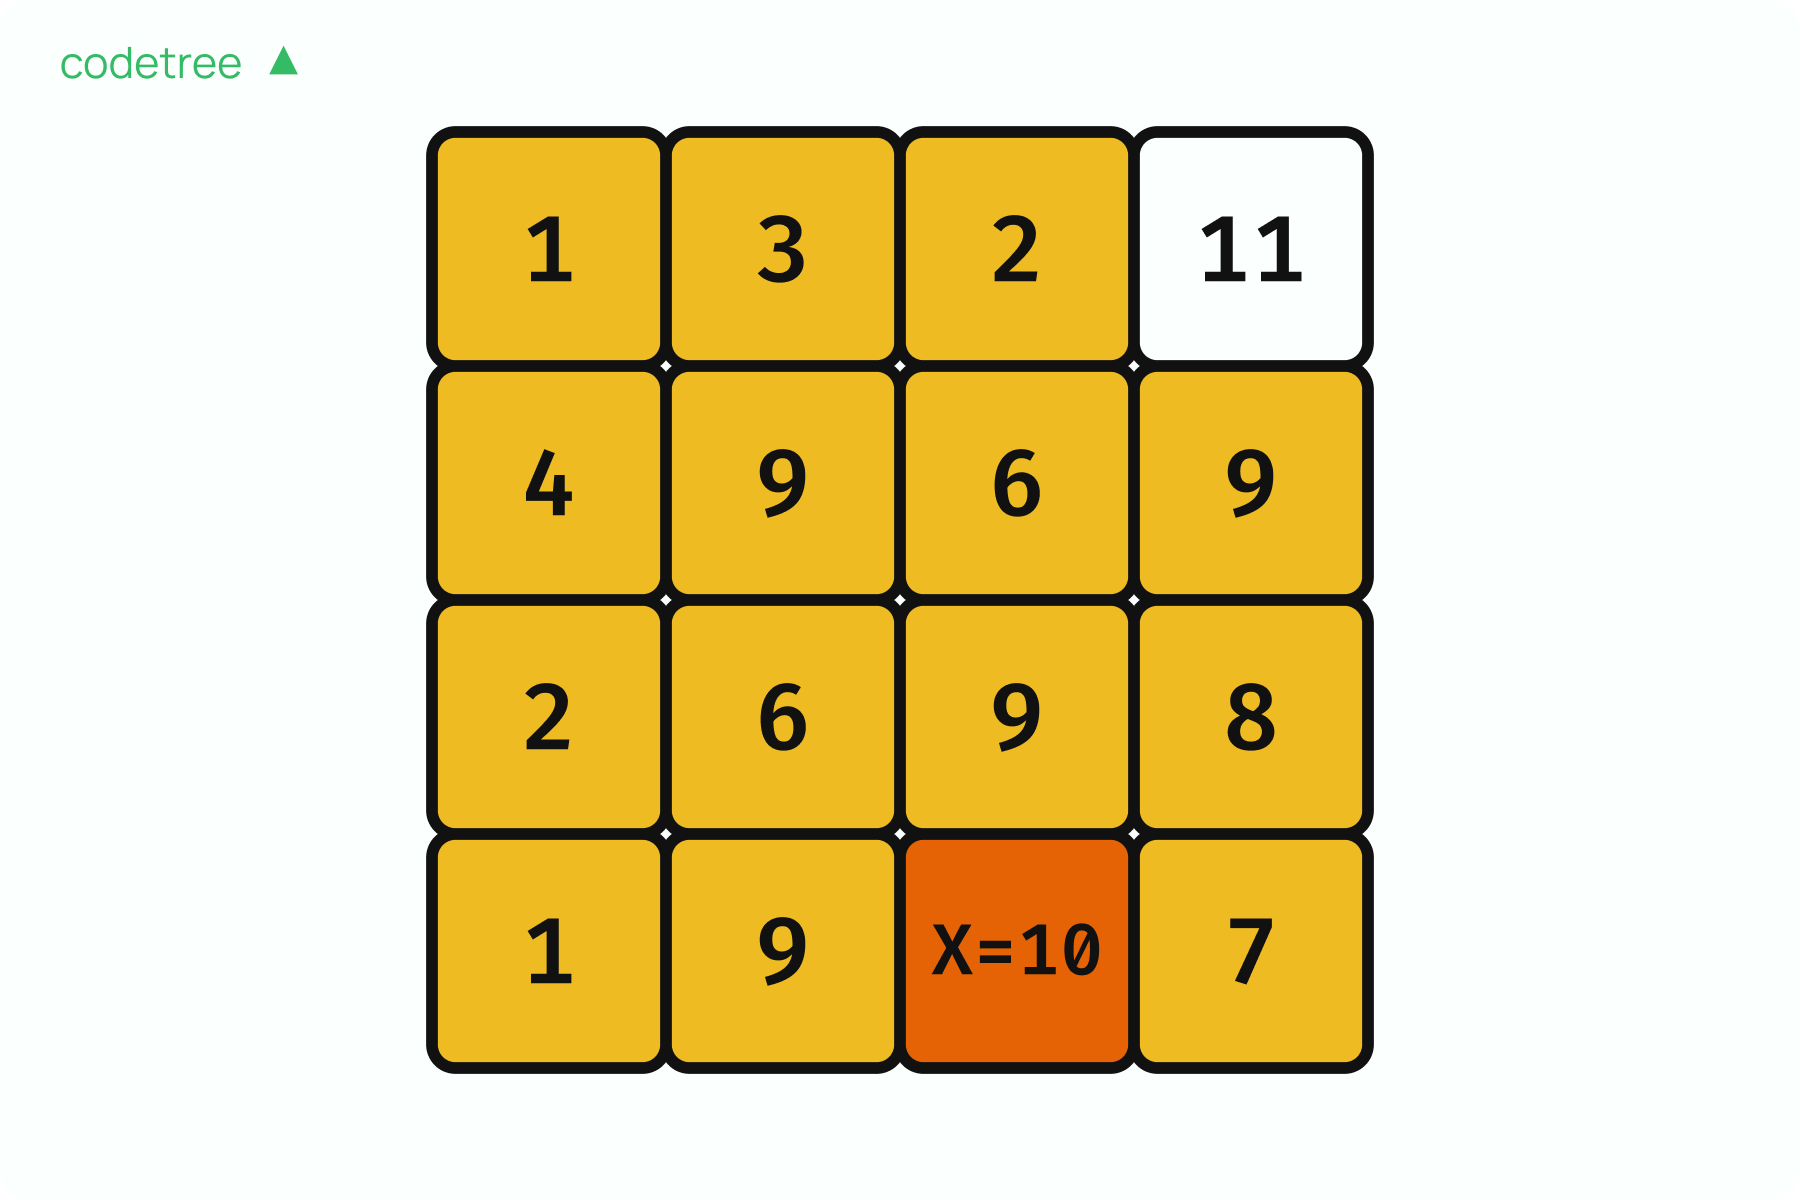

1-1. 하지만 만약에 아래 그림처럼 시작 위치의 상하좌우가 시작 숫자(=10)보다 큰 숫자들(=11)로 둘러싸여져 있으면 이동이 불가합니다.

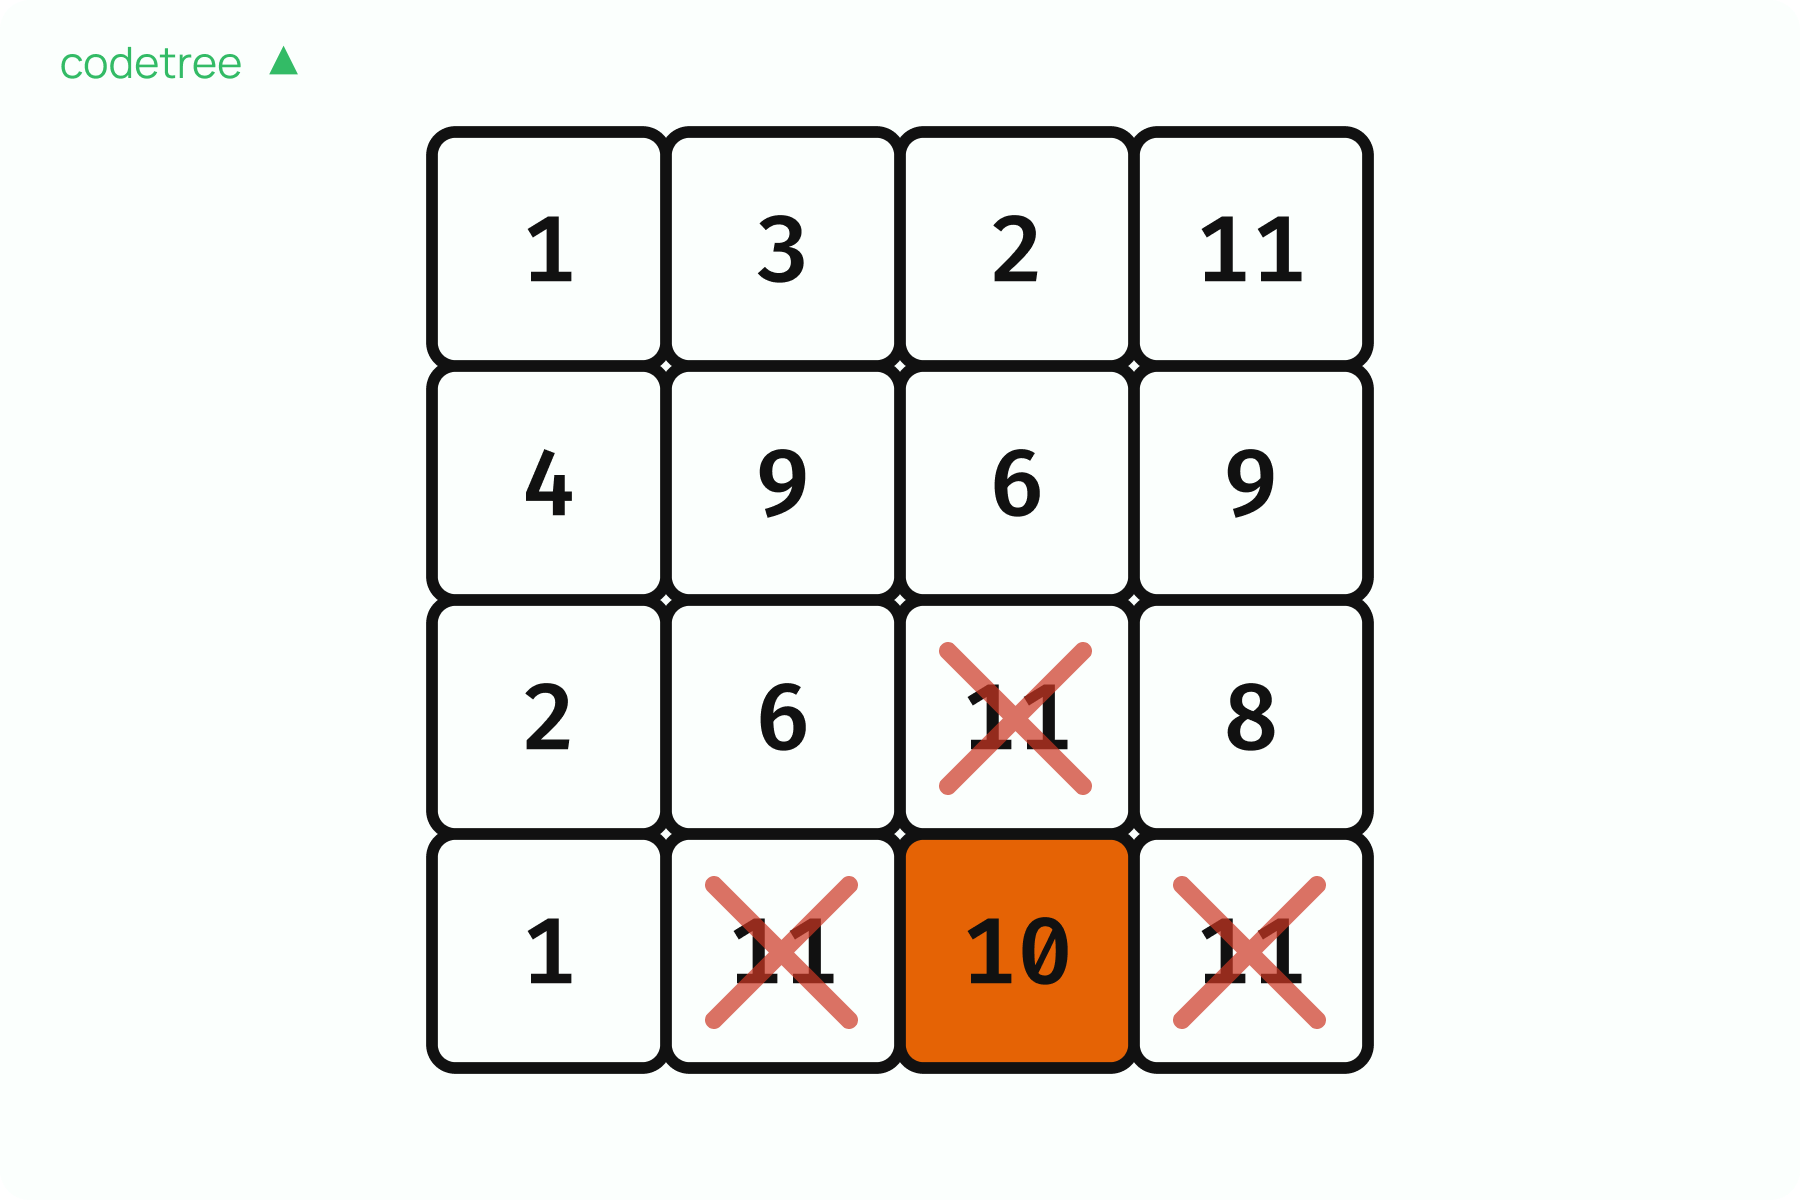



2. 1번 조건을 만족하며 도달할 수 있는 칸들에 적혀있는 숫자 중 최댓값으로 이동합니다.

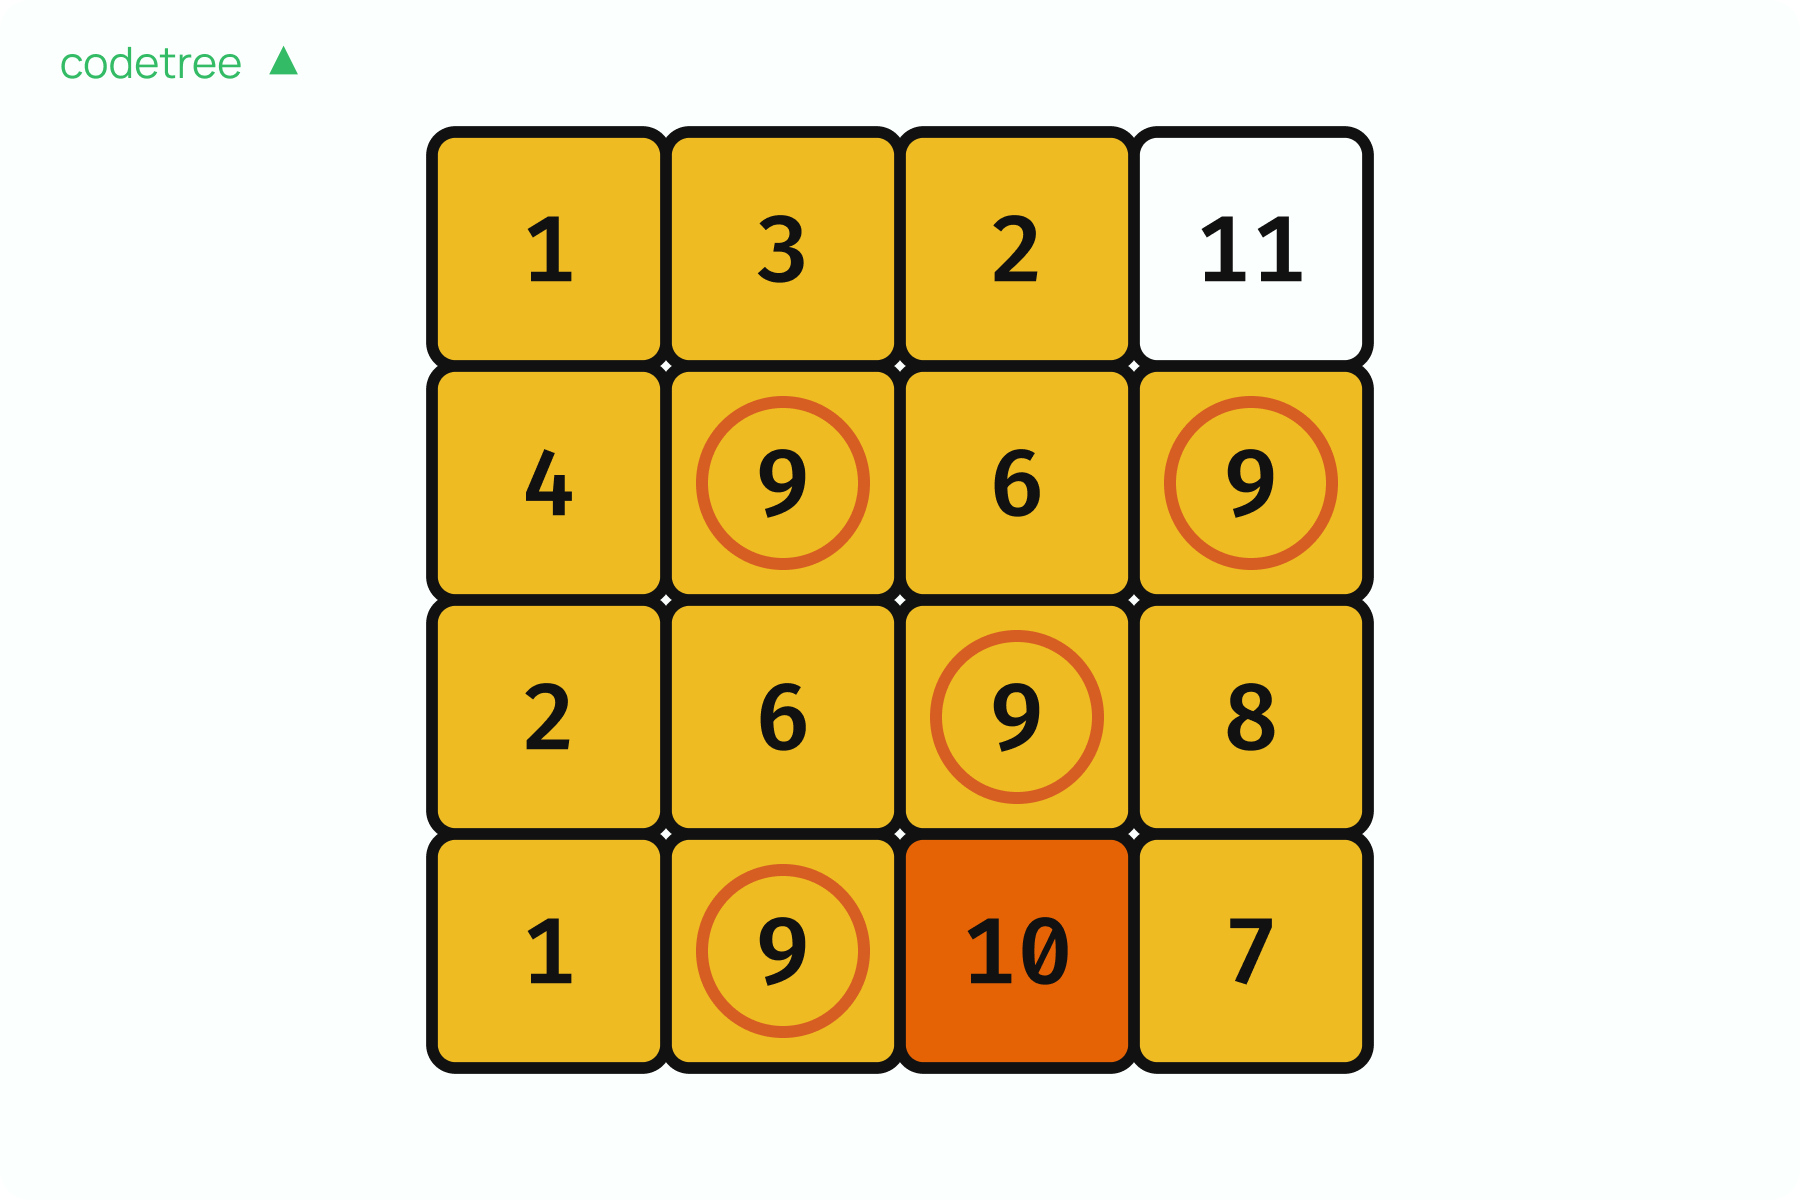

위 그림과 같이 시작 위치에 적혀있는 숫자 10에서 출발하여 인접한 칸들 중 10보다 작지만 그 중 최댓값인 9로 이동을 고려합니다.

3. 2번 조건을 만족하는 숫자가 여러개 일경우, 행 번호가 가장 작은 곳으로 이동합니다. 아래 그림과 같이 2행에 있는 최댓값(=9)이 두개 있습니다.

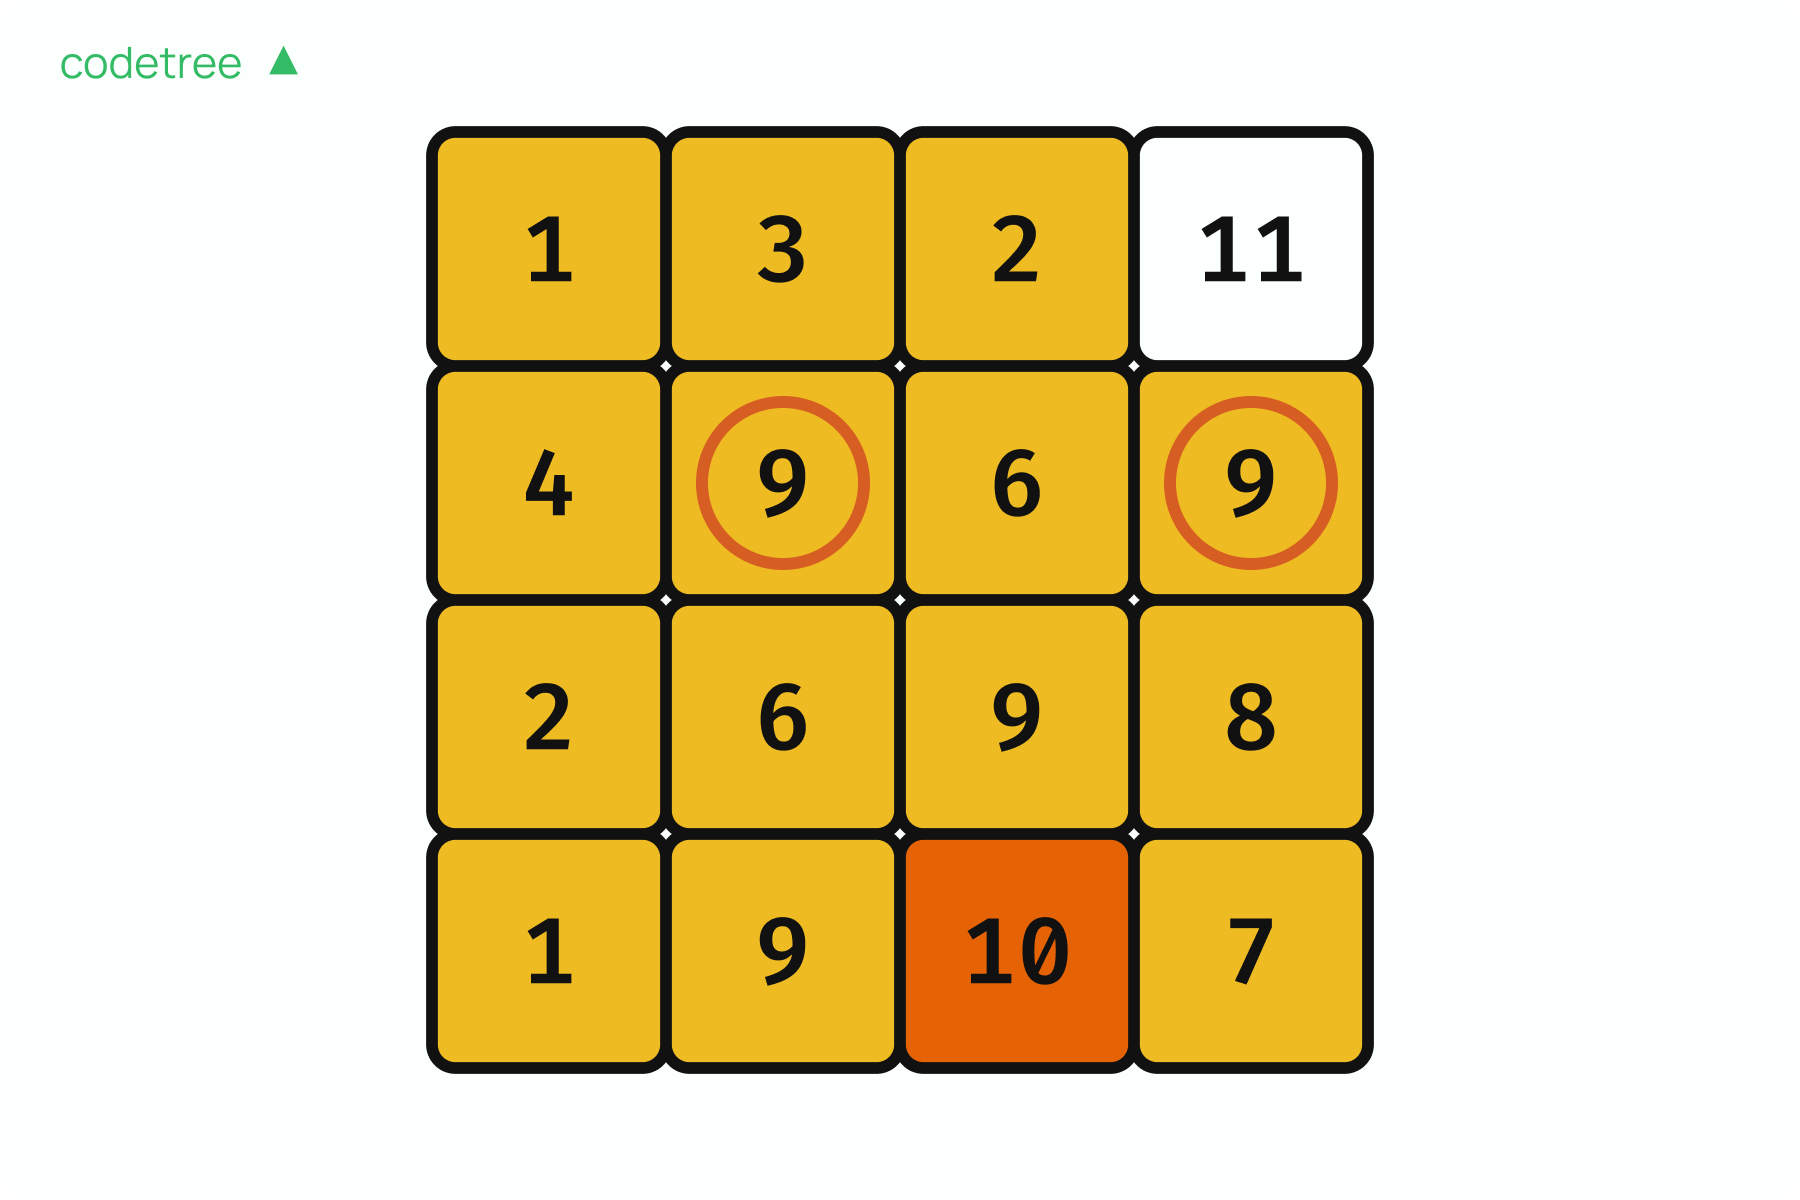

4. 2번 조건을 만족하고, 행 번호도 같은 숫자가 여러개 일경우, 열 번호가 가장 작은 곳으로 이동합니다.

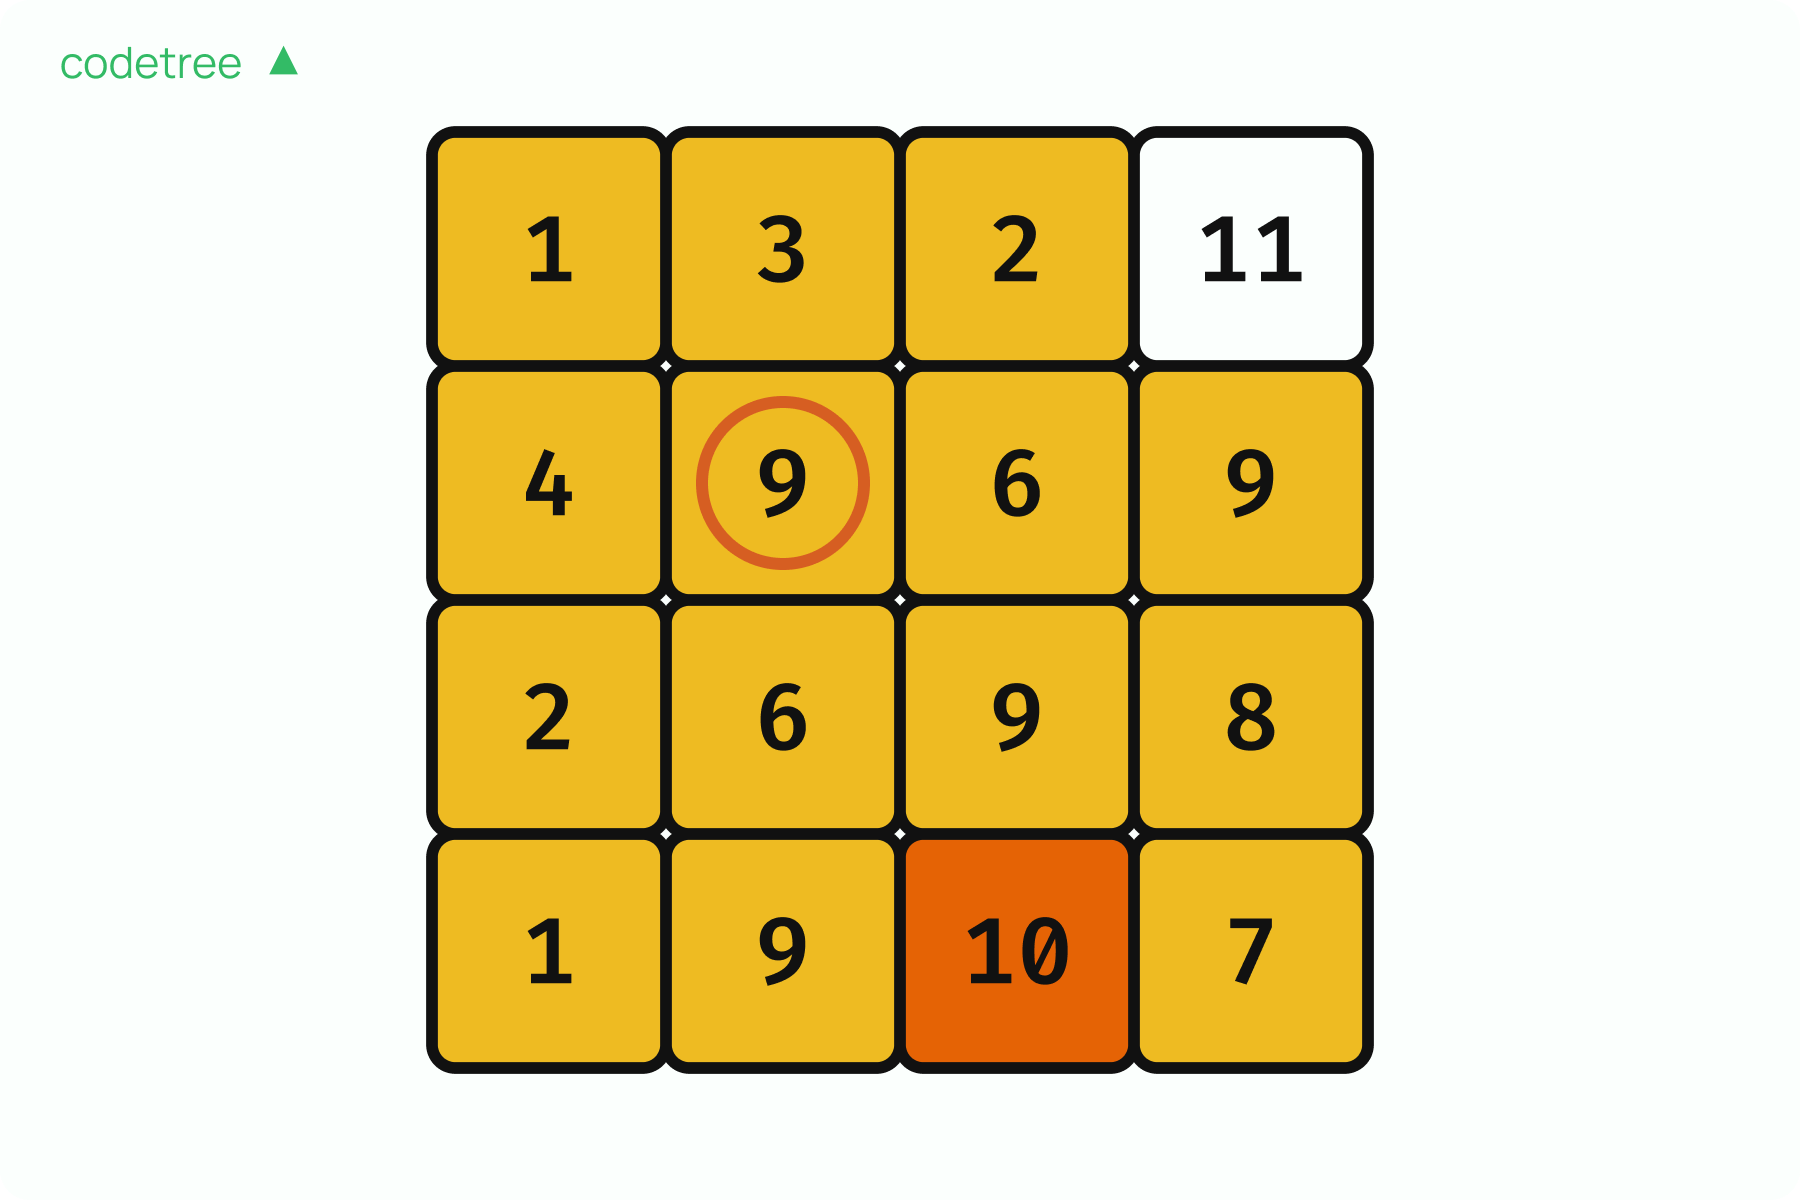

결론적으로 4행 3열에서 시작하여 인접한 곳으로 숫자 10보다 작은 곳들로 이동했을 때 갈 수 있는 칸들 중 최대 숫자는 9이고, 그 중 우선순위가 가장 높은 곳은 2행 2열입니다. 따라서 2행 2열 위치로 이동하게 됩니다.

2행 2열 위치를 시작으로 한번 더 움직임을 반복해보면, 2행 2열에서 시작하여 인접한 곳으로 숫자 9보다 작은 곳들로 이동했을 때 갈 수 있는 칸들 중 최대 숫자는 6이고, 그 중 우선순위가 가장 높은 곳은 2행 3열입니다. 따라서 2행 3열 위치로 이동하게 됩니다.

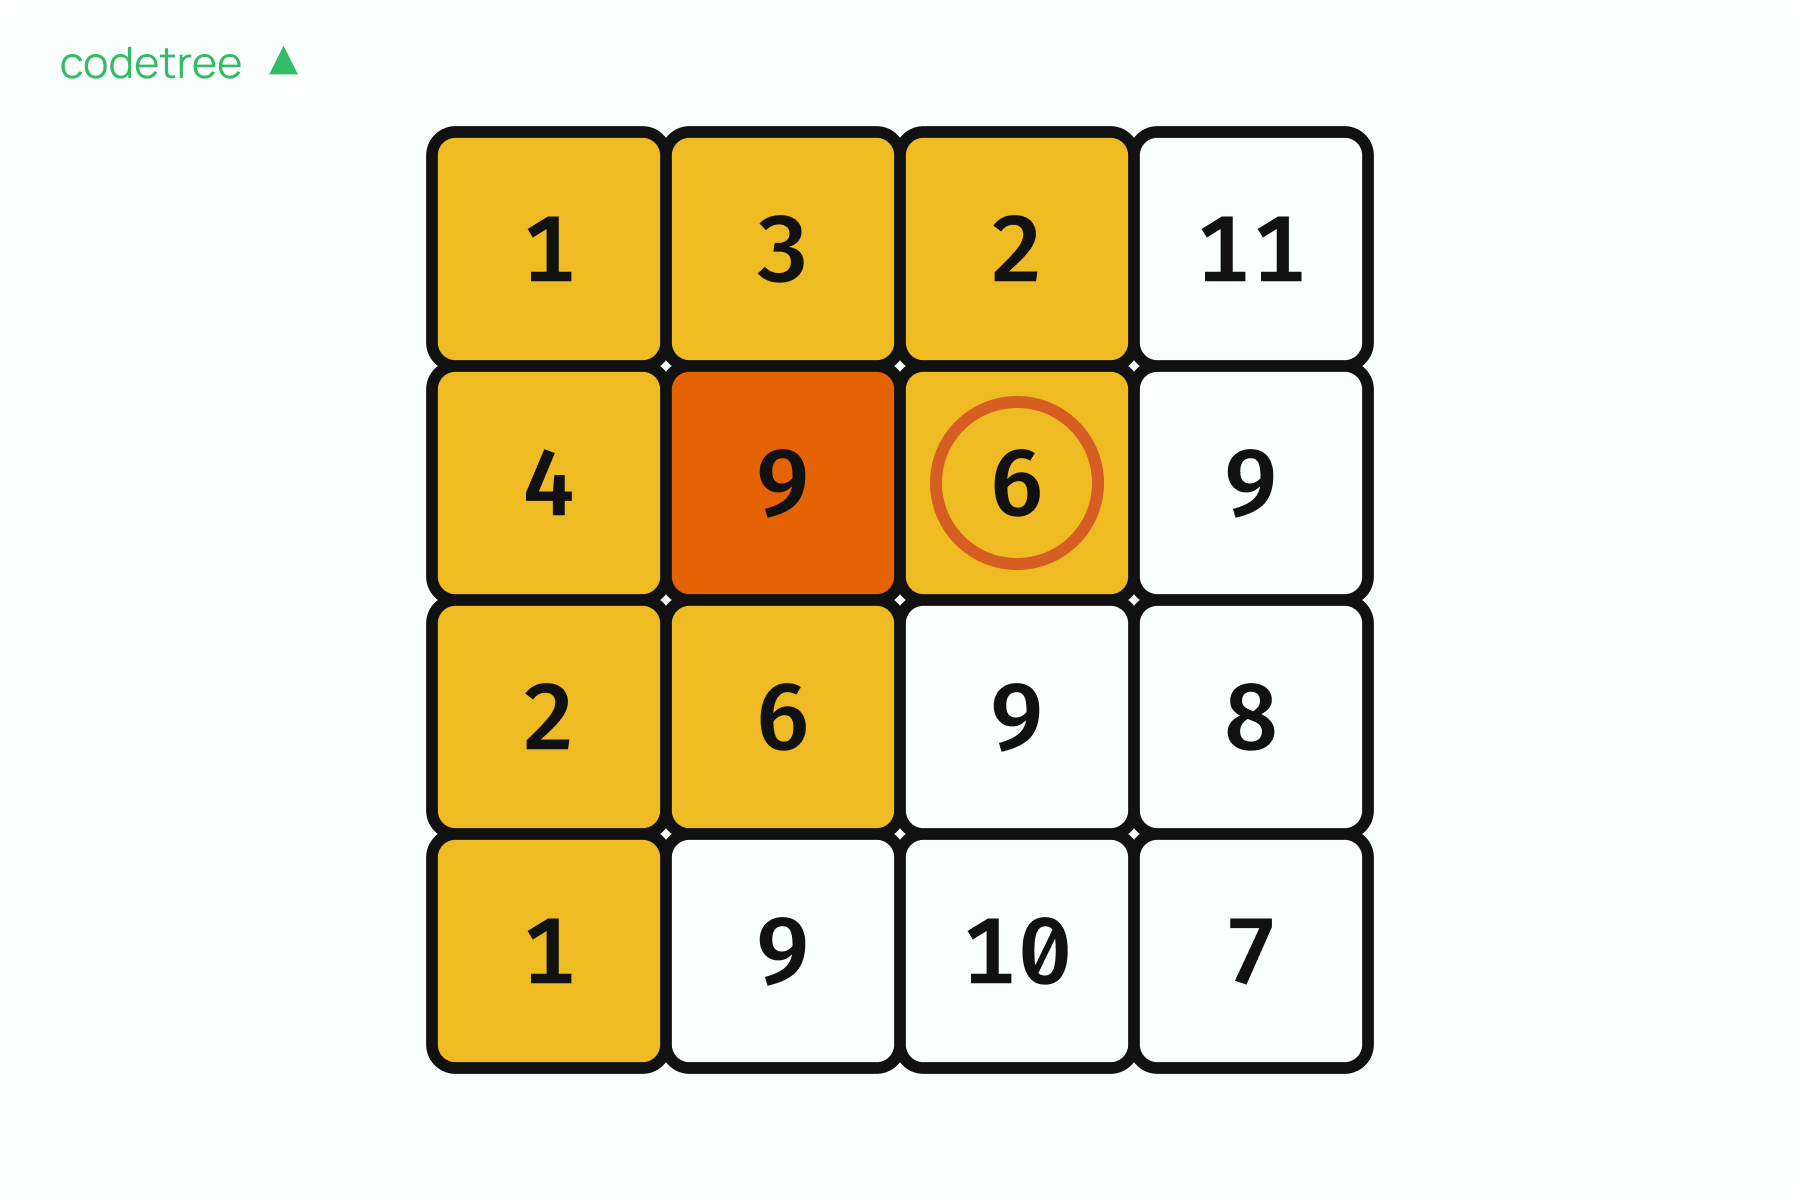

2행 3열 위치를 시작으로 한번 더 움직임을 반복해보면, 2행 3열에서 시작하여 인접한 곳으로 숫자 6보다 작은 곳들로 이동했을 때 갈 수 있는 칸들 중 최대 숫자는 4이고, 4는 2행 1열입니다. 따라서 2행 1열 위치로 이동하게 됩니다.

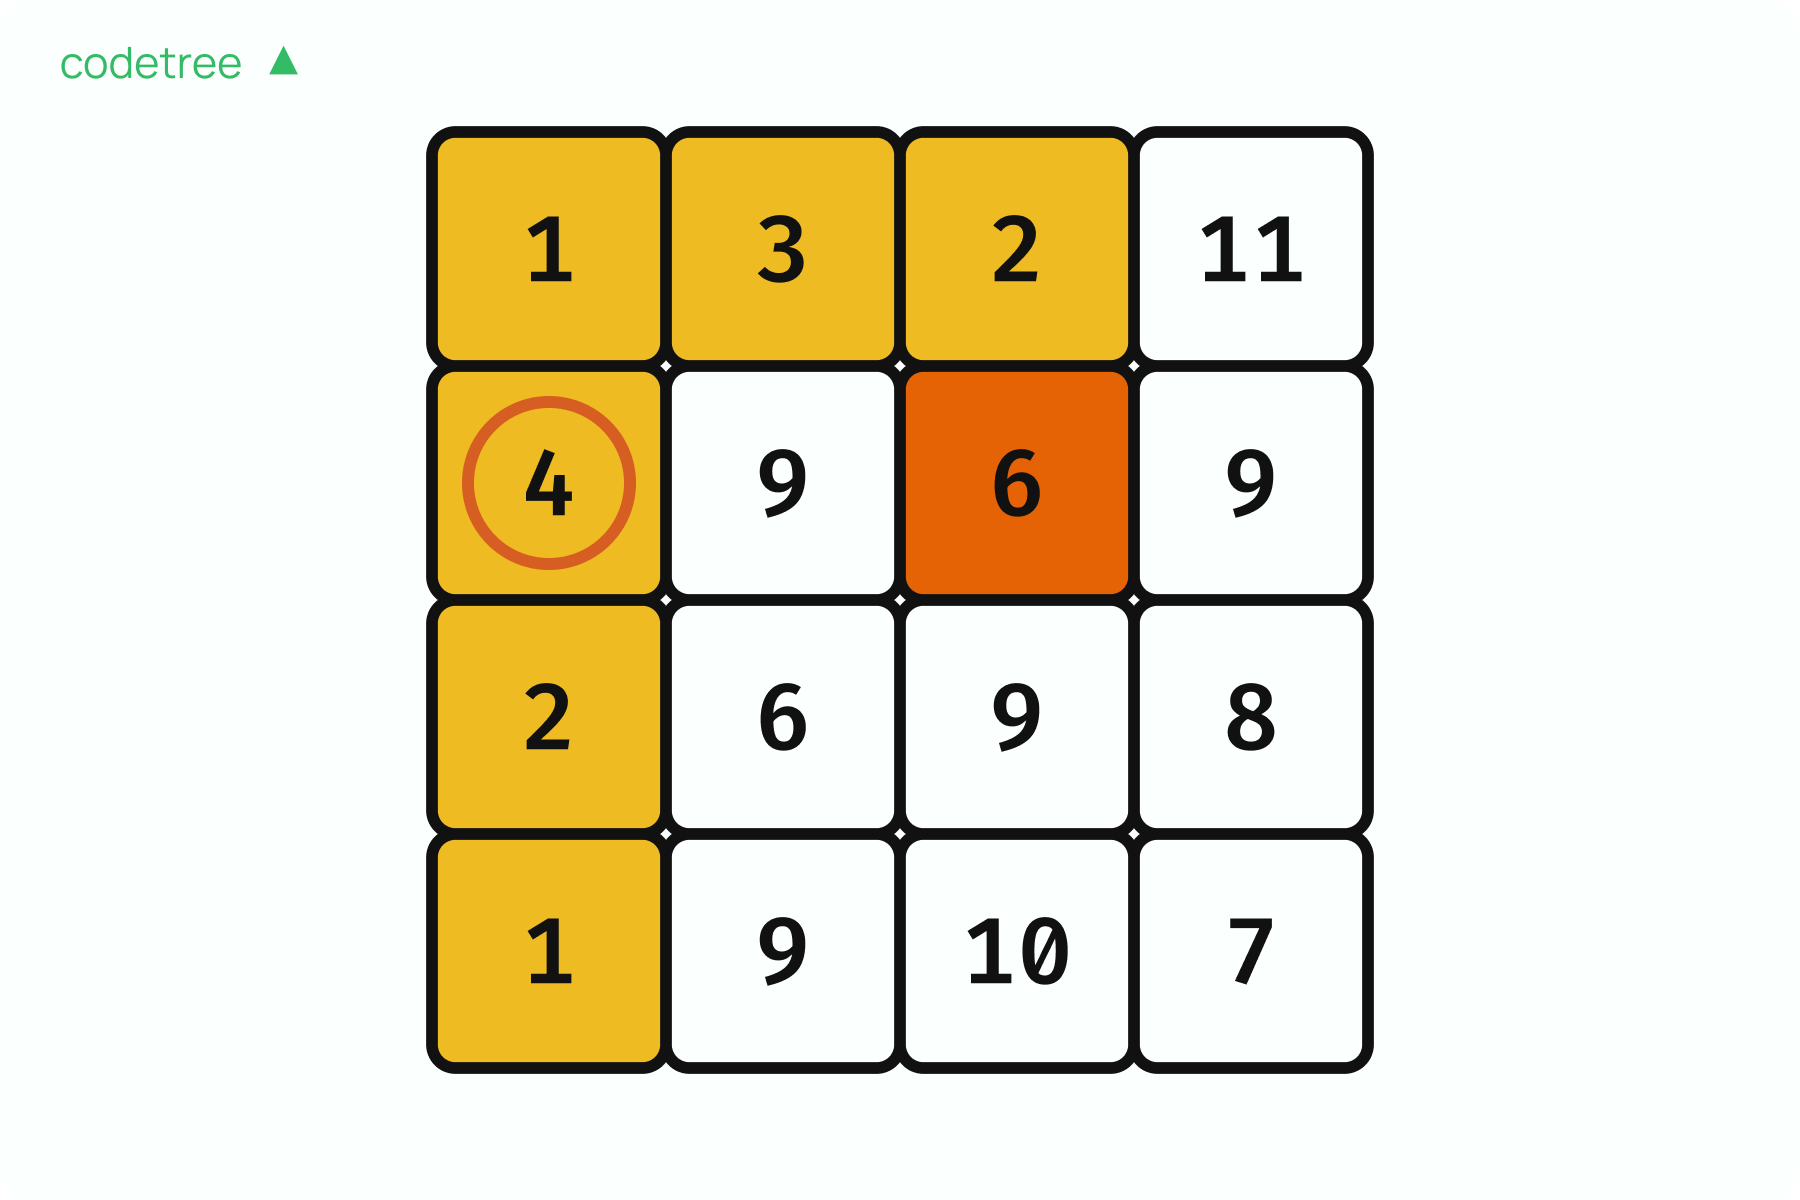

이렇게 이동하는 것을 K번 반복한 후의 위치를 구하는 프로그램을 작성해보세요. 아직 K번을 반복하지 못했더라도, 더 이상 새로 이동할 위치가 없다면 움직이는 것을 종료해야함에 유의합니다.

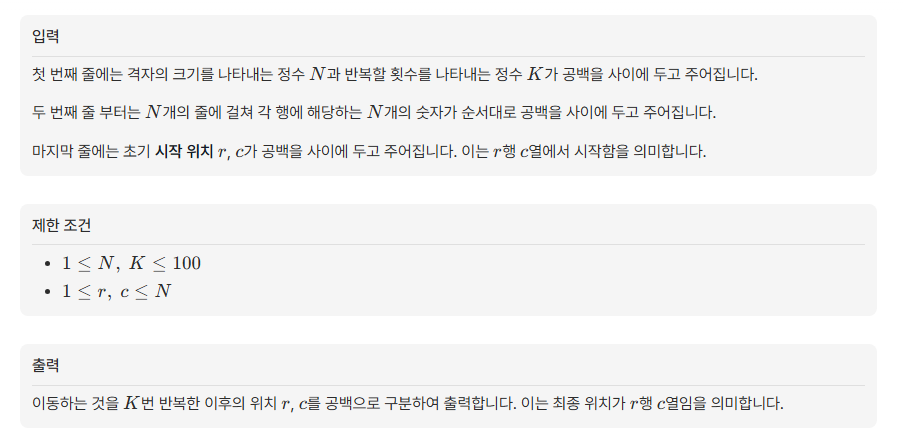

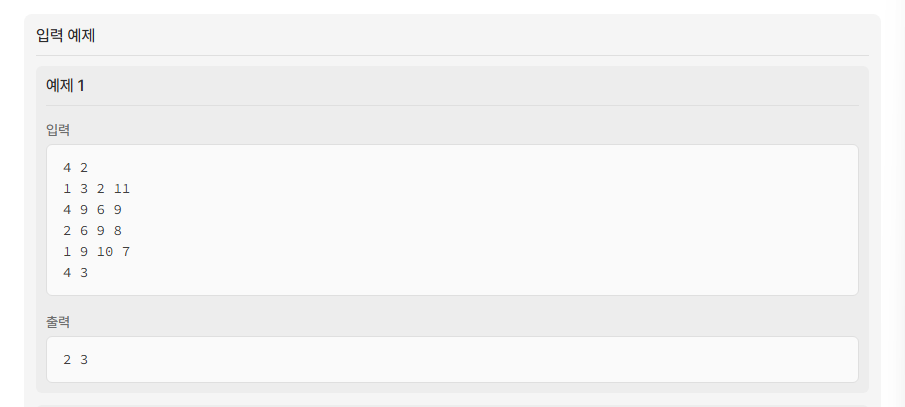

In [ ]:
# 사용자로부터 격자의 크기 N과 반복 횟수 K를 입력받습니다.
N, K = map(int, input().split())

# N x N 크기의 격자(지도) 정보를 입력받습니다.
grid = [list(map(int, input().split())) for _ in range(N)]

# 시작 위치 r(행), c(열)를 입력받습니다.
r, c = map(int, input().split())

# 문제에서는 1행 1열부터 시작하지만, 파이썬 인덱스는 0부터 시작하므로 1씩 빼줍니다.
r -= 1
c -= 1

# 이동할 방향을 정해주는 방향키 배열입니다. (상, 하, 좌, 우)
dx = [-1, 1, 0, 0]
dy = [0, 0, -1, 1]

# K번 반복해서 이동을 시도합니다.
for _ in range(K):
    # 매 이동마다 새로운 탐색을 해야 하므로 방문 체크리스트를 초기화합니다.
    visited = [[False] * N for _ in range(N)]

    # 갈 수 있는 후보지들을 모아둘 빈 리스트를 만듭니다.
    candidates = []

    # 현재 서 있는 위치의 숫자를 기준값(target_val)으로 저장합니다.
    target_val = grid[r][c]

    # 시작 위치를 방문 처리하고, 스택에 넣어 DFS 탐색을 준비합니다.
    visited[r][c] = True
    stack = [(r, c)]

    # 스택이 빌 때까지 (연결된 모든 갈 수 있는 곳을 찾을 때까지) 반복합니다.
    while stack:
        # 스택에서 현재 위치(x, y)를 하나 꺼냅니다.
        x, y = stack.pop()

        # 4가지 방향으로 모두 이동을 시도해 봅니다.
        for i in range(4):
            nx = x + dx[i]
            ny = y + dy[i]

            # 1. 지도의 범위를 벗어나지 않았고
            if 0 <= nx < N and 0 <= ny < N:
                # 2. 아직 방문하지 않은 곳이며
                # 3. 그곳의 숫자가 현재 기준값(처음 시작 숫자)보다 작다면 이동 가능합니다!
                if not visited[nx][ny] and grid[nx][ny] < target_val:
                    # 방문 처리 후 스택에 넣어 다음 탐색을 이어갑니다.
                    visited[nx][ny] = True
                    stack.append((nx, ny))

                    # 💡 핵심: 후보지 리스트에 담을 때, 정렬을 쉽게 하기 위해 부호를 바꿉니다.
                    # (-숫자값, 행 위치, 열 위치) 형태로 묶어서 튜플로 저장합니다.
                    candidates.append((-grid[nx][ny], nx, ny))

    # 만약 DFS 탐색을 끝냈는데 후보지가 단 하나도 없다면?
    if not candidates:
        # 더 이상 갈 곳이 없으므로 K번을 다 못 채웠어도 이동을 완전히 종료(break)합니다.
        break

    # 후보지가 있다면, 우선순위에 맞게 정렬합니다.
    # (아래 암기 노트에서 원리를 자세히 설명해 드릴게요!)
    candidates.sort()

    # 정렬된 리스트의 첫 번째(인덱스 0) 요소가 우리가 원하는 1등 목적지입니다.
    best_candidate = candidates[0]

    # 내 현재 위치(r, c)를 1등 목적지의 위치(행, 열)로 갱신하여 이동합니다.
    # best_candidate의 [0]은 -숫자값, [1]은 행(x), [2]는 열(y) 입니다.
    r = best_candidate[1]
    c = best_candidate[2]

# 모든 반복이 끝난 후, 최종 위치를 다시 1부터 시작하는 번호로 바꿔서 출력합니다.
print(r + 1, c + 1)

4 2
1 3 2 11
4 9 6 9
2 6 9 8
1 9 10 7
4 3
2 3


# 빙하

90XP

평균 180분

52% 정답률

총 제출 2,023회
___
N×M 크기의 격자안에 빙하의 정보가 주어집니다. 격자의 가장 바깥 부분은 항상 빙하가 아니고, 빙하를 제외한 나머지 위치에는 전부 물이 채워져 있습니다. 숫자 1은 빙하를, 숫자 0은 물을 나타냅니다.

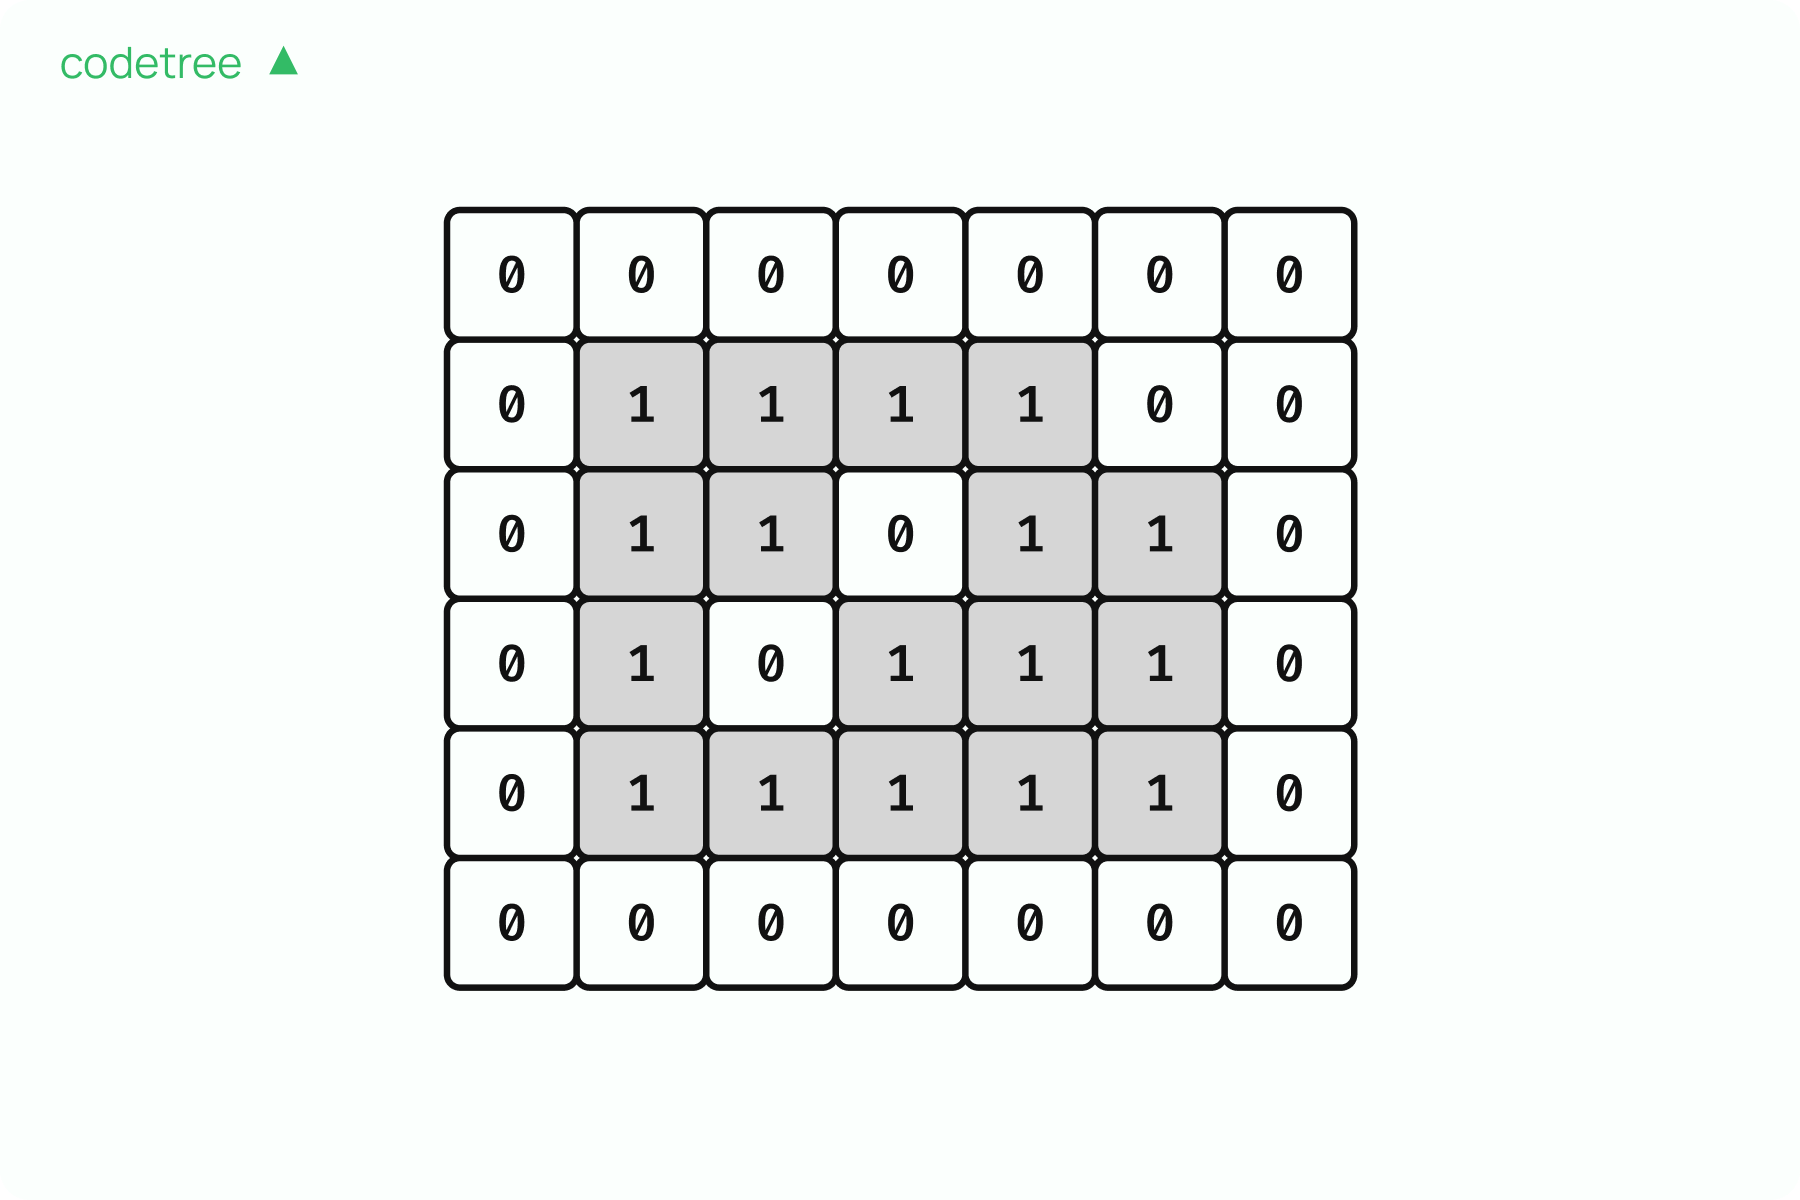

빙하는 1초에 한 번씩 물에 닿아있는 부분들이 동시에 녹습니다. 하지만 빙하로 둘러싸여있는 물의 경우에는 붙어있는 빙하를 녹이지 못합니다. 여기서 닿아있다는 말은 상하좌우로 인접한 경우를 의미하며, 다음의 경우 역시 안쪽에 있는 0들은 빙하로 둘러쌓인 것이기 때문에 빙하가 녹는데 영향을 주지 못합니다.

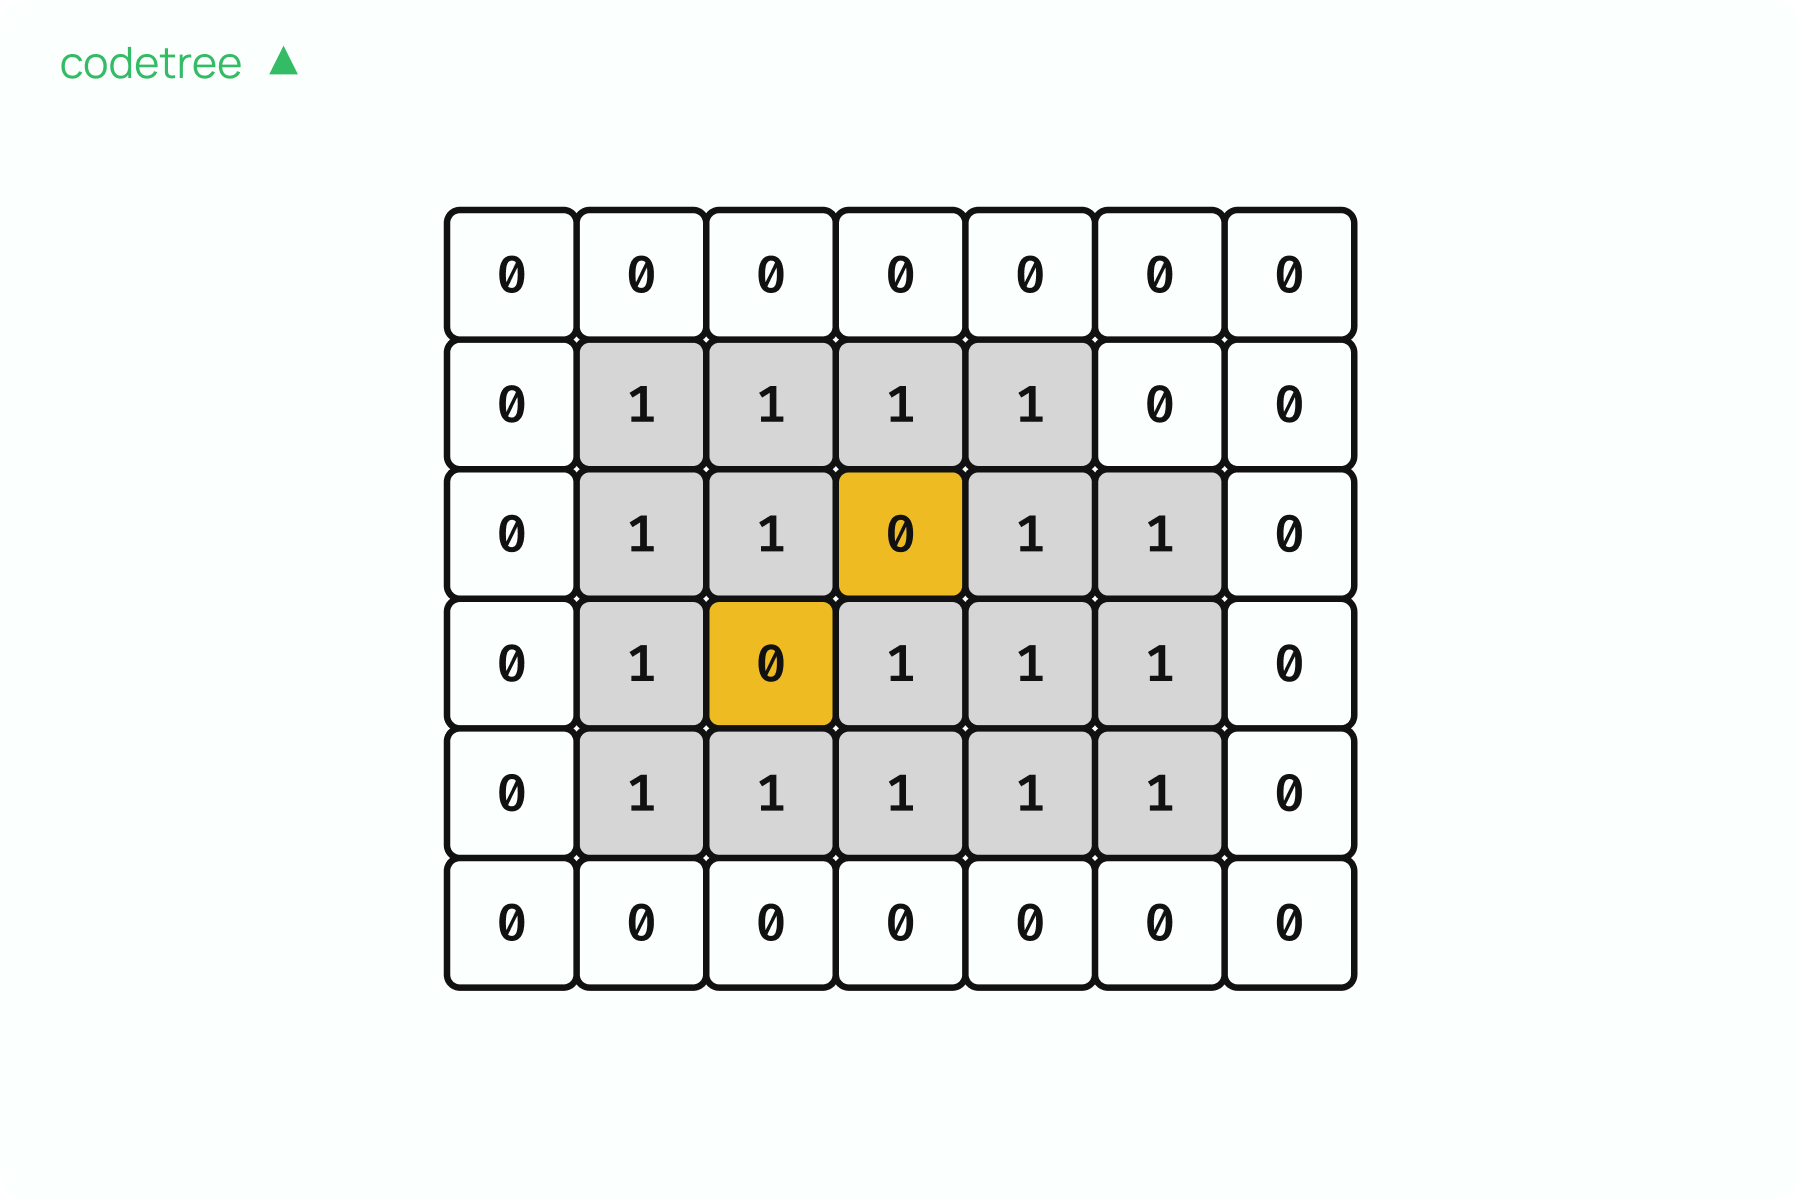

맨 위에서 주어진 예시의 경우 안쪽에 있는 0은 빙하로 둘러싸여 있으므로 바깥쪽에 있는 0만이 빙하가 녹는데 영향을 미칩니다.

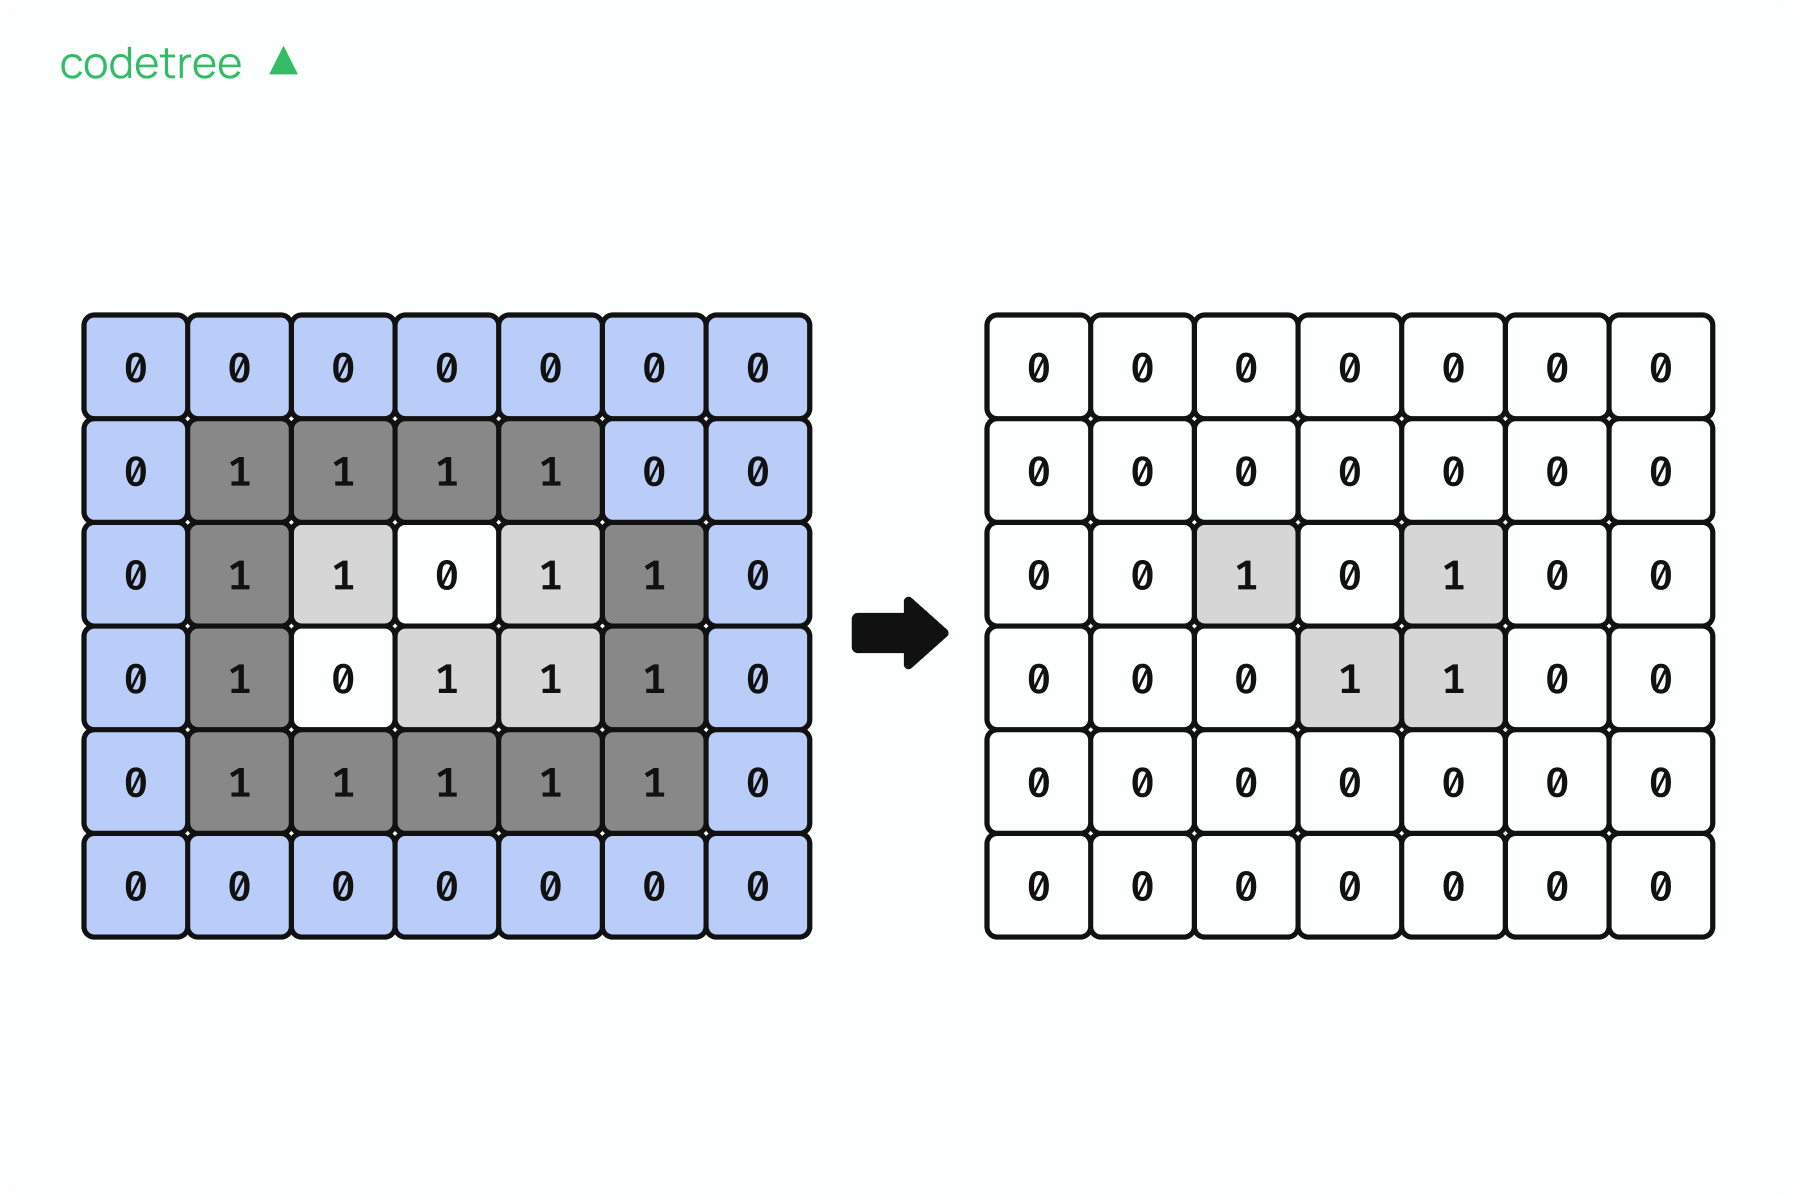

빙하가 전부 녹는데 걸리는 시간과 마지막으로 녹은 빙하의 크기(1의 개수)를 구하는 프로그램을 작성해보세요.

위의 예에서는 빙하가 녹는데 2초의 시간이 소요되며, 마지막으로는 크기가 4인 빙하가 녹으며 전부 없어지게 됩니다.

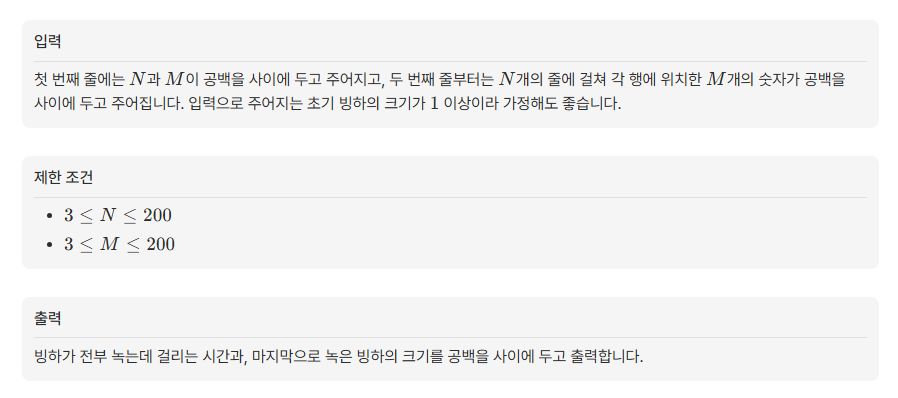

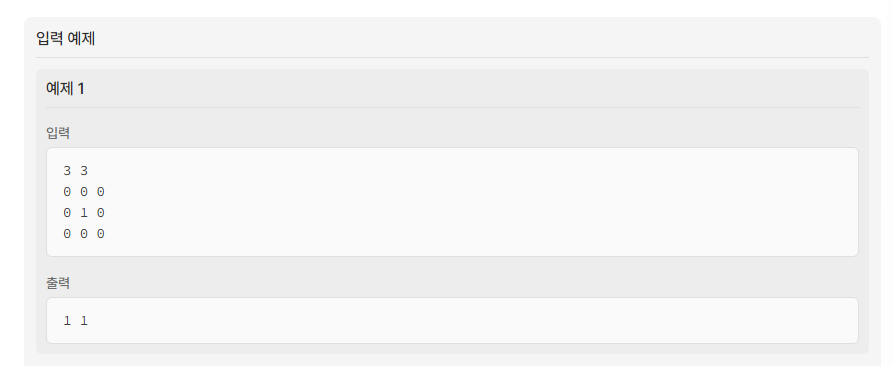

In [ ]:
# 사용자로부터 격자의 크기 N(행)과 M(열)을 입력받습니다.
N, M = map(int, input().split())

# 빙하(1)와 물(0)의 정보가 담긴 N x M 크기의 지도를 입력받습니다.
grid = [list(map(int, input().split())) for _ in range(N)]

# 방문 여부를 체크할 N x M 크기의 체크리스트입니다.
# 전체 탐색이 끝날 때까지 단 한 번도 초기화하지 않습니다! (핵심)
visited = [[False] * M for _ in range(N)]

# 이동할 방향 (상, 하, 좌, 우)
dx = [-1, 1, 0, 0]
dy = [0, 0, -1, 1]

# 첫 시작은 무조건 가장자리 바깥 물인 (0, 0)입니다.
# water_q: 물이 퍼져나갈 위치들을 담아두는 리스트 (BFS 큐 역할)
water_q = [(0, 0)]
visited[0][0] = True

# 정답으로 출력할 총 걸린 시간과, 마지막으로 녹은 빙하의 크기입니다.
total_time = 0
last_melt_size = 0

# 더 이상 녹을 빙하가 없을 때까지 무한 반복합니다.
while True:
    # 이번 1초 동안 겉면에 닿아서 녹아야 할 빙하들의 위치를 담을 리스트입니다.
    melt_q = []

    # 큐(queue)에서 데이터를 꺼낼 때 pop(0)을 쓰면 너무 느리므로,
    # 어디까지 읽었는지 표시하는 head(머리) 인덱스를 사용합니다.
    head = 0

    # 물결이 퍼져나갑니다. (현재 water_q에 있는 모든 물을 확인)
    while head < len(water_q):
        # 현재 물의 위치를 가져오고, 다음 위치를 읽기 위해 head를 1 늘립니다.
        r, c = water_q[head]
        head += 1

        # 상하좌우 4방향으로 물결을 보냅니다.
        for i in range(4):
            nr = r + dx[i]
            nc = c + dy[i]

            # 1. 지도를 벗어나지 않았고, 2. 아직 방문하지 않은 곳이라면
            if 0 <= nr < N and 0 <= nc < M and not visited[nr][nc]:
                # 즉시 방문 처리를 합니다.
                visited[nr][nc] = True

                # 만약 그곳이 물(0)이라면?
                if grid[nr][nc] == 0:
                    # 계속해서 물결이 퍼져나가야 하므로 water_q에 추가합니다.
                    water_q.append((nr, nc))
                # 만약 그곳이 빙하(1)라면? (바깥 물과 닿은 빙하 발견!)
                else:
                    # 물결은 막히지만, 이번 턴에 녹아야 하므로 melt_q에 추가합니다.
                    melt_q.append((nr, nc))

    # 더 이상 바깥 물과 닿아있는 빙하가 없다면? (탐색 종료)
    if len(melt_q) == 0:
        break

    # 방금 찾은 '녹을 빙하들'의 개수를 마지막 크기로 기억해 둡니다.
    last_melt_size = len(melt_q)

    # 1초의 시간이 흘렀습니다.
    total_time += 1

    # 찾아둔 빙하들을 모두 녹여서 물(0)로 만듭니다.
    for r, c in melt_q:
        grid[r][c] = 0

    # 💡 [초고속 탐색의 비결]
    # 다음 1초 뒤의 물결은 처음부터 다시 찾을 필요 없이,
    # '방금 빙하에서 물로 변한 곳(melt_q)'부터 다시 시작하면 됩니다!
    water_q = melt_q

# 모든 과정이 끝나면 걸린 시간과 마지막 빙하의 크기를 출력합니다.
print(total_time, last_melt_size)

6 7
0 0 0 0 0 0 0
0 1 1 1 1 0 0
0 1 1 0 1 1 0
0 1 0 1 1 1 0
0 1 1 1 1 1 0
0 0 0 0 0 0 0
2 4


# 5일차

# 나이트

40XP

평균 27분

56% 정답률

총 제출 2,796회
___
나이트는 다음과 같이 노란색 위치를 기준으로 검은색 8곳으로 움직임이 가능합니다. N×N 격자 위에서 격자를 벗어나지 않고 나이트가 시작점에서 도착점까지 가는 데 걸리는 최소 이동 횟수를 구하는 프로그램을 작성해보세요.

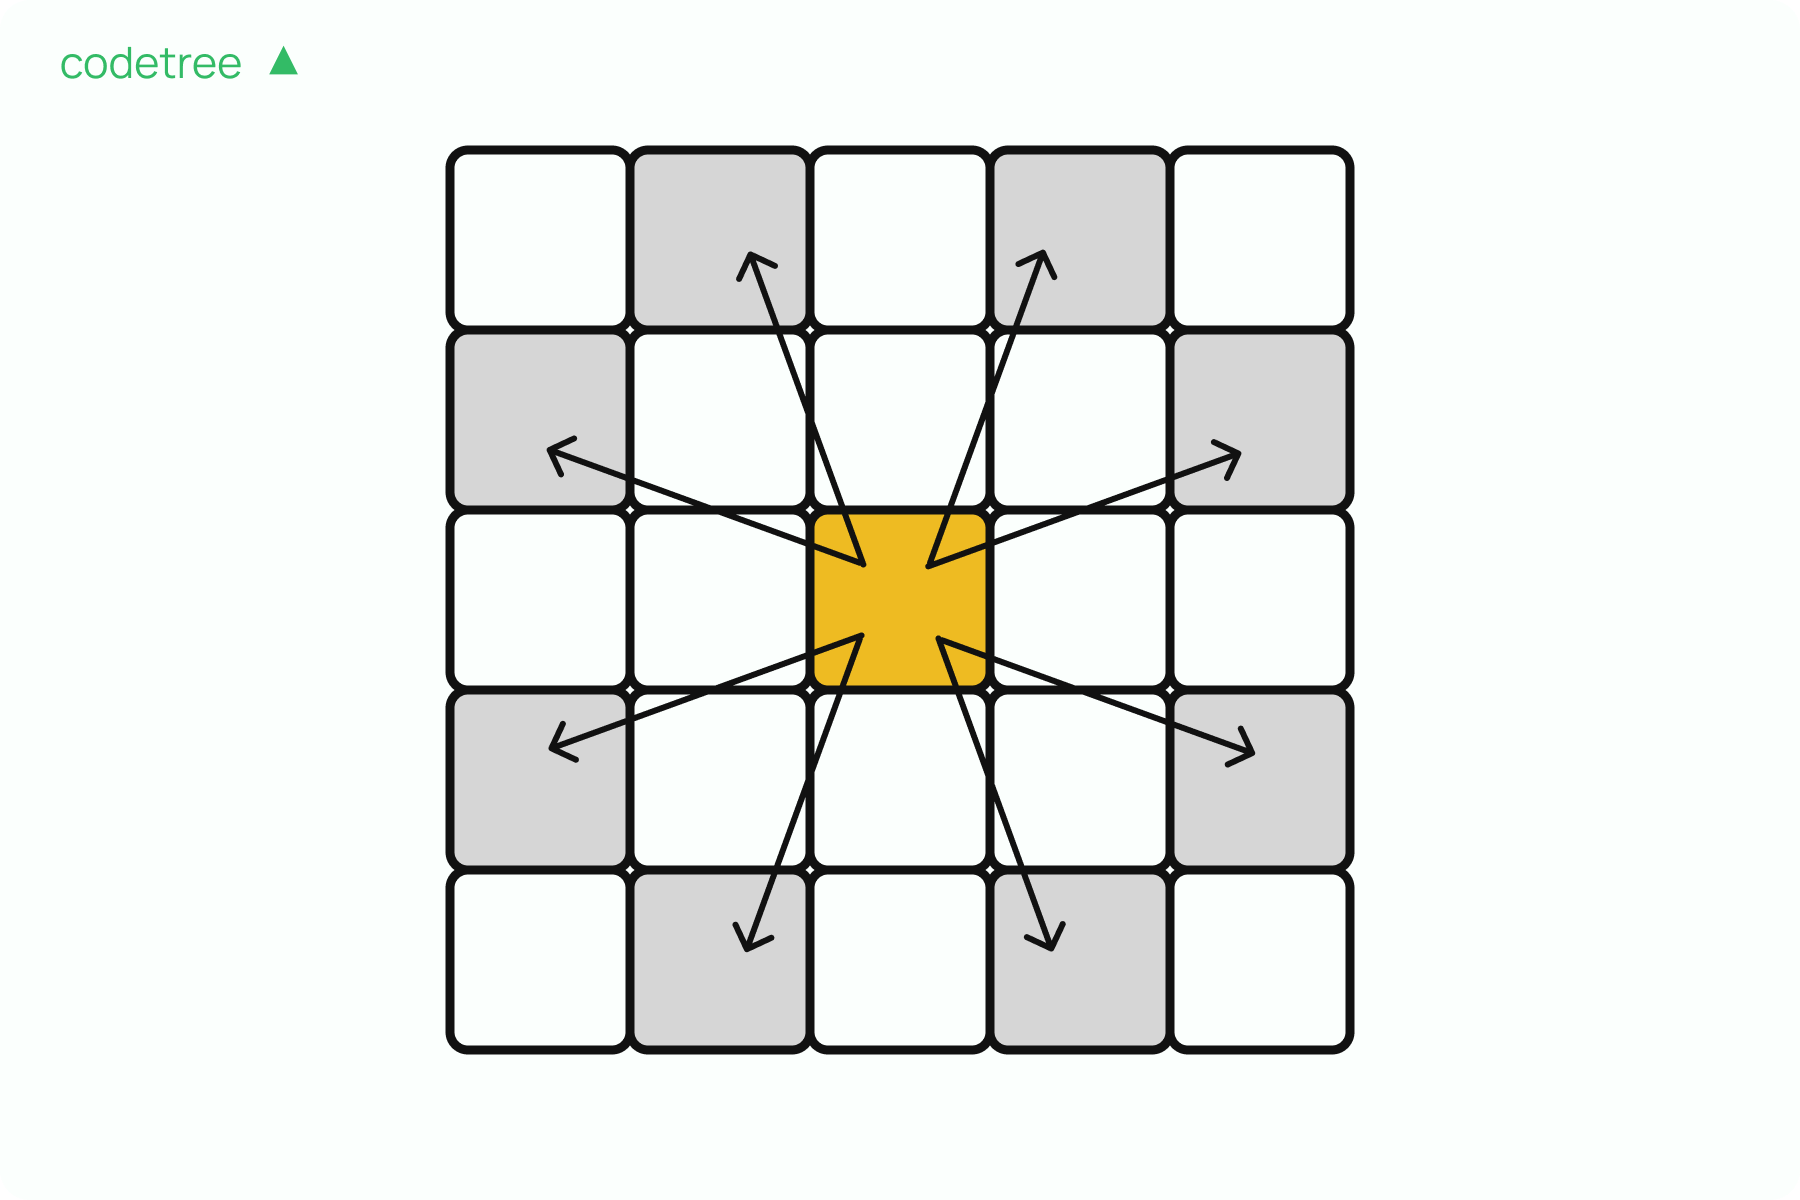

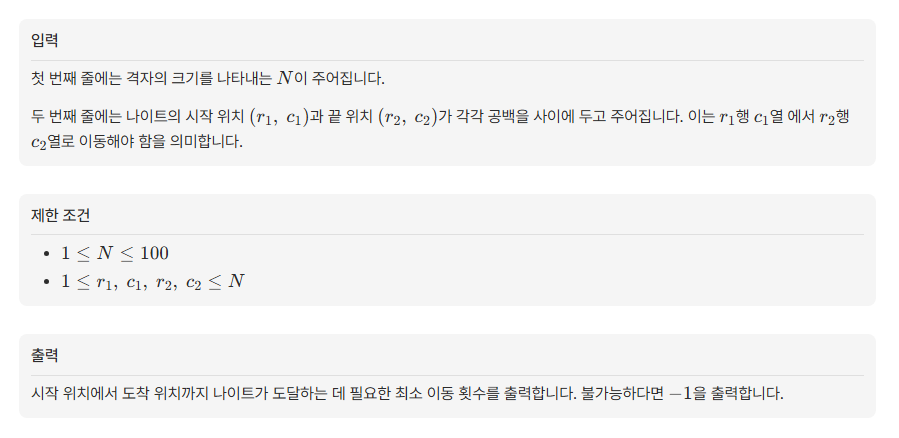

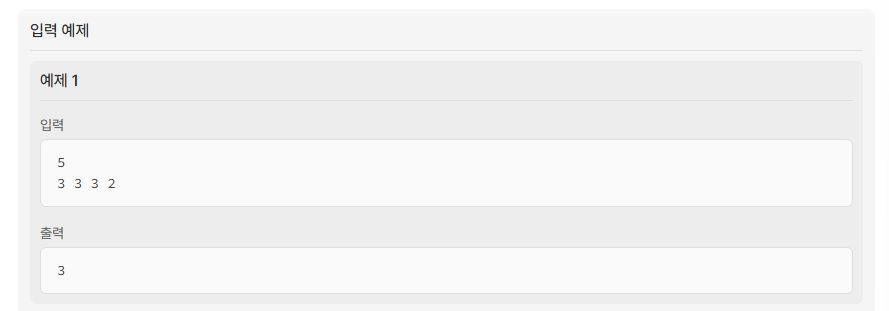

In [ ]:
# 사용자로부터 격자의 크기 N을 입력받습니다.
N = int(input())

# 시작점(r1, c1)과 도착점(r2, c2)의 좌표를 입력받습니다.
r1, c1, r2, c2 = map(int, input().split())

# 문제의 좌표는 1부터 시작하므로, 파이썬 리스트 인덱스(0부터 시작)에 맞게 모두 1씩 빼줍니다.
r1 -= 1
c1 -= 1
r2 -= 1
c2 -= 1

# 나이트가 이동할 수 있는 8가지 방향을 정의합니다. (그림 참고)
# dx: 행(위아래) 변화, dy: 열(좌우) 변화
dx = [-2, -2, -1, -1, 1, 1, 2, 2]
dy = [-1, 1, -2, 2, -2, 2, -1, 1]

# 방문 여부와 동시에 '최소 이동 횟수'를 기록할 2차원 리스트를 만듭니다.
# 아직 방문하지 않은 곳은 -1로 초기화합니다.
dist = [[-1] * N for _ in range(N)]

# BFS 탐색을 위한 큐(리스트)를 만들고 시작점을 넣습니다.
queue = [(r1, c1)]

# 시작점은 이동 횟수가 0번이므로 0으로 설정합니다. (-1에서 0이 되었으니 방문 처리도 된 것입니다!)
dist[r1][c1] = 0

# 초고속 큐를 위한 머리(head) 인덱스입니다.
head = 0

# 큐에 탐색할 위치가 남아있는 동안 계속 반복합니다.
while head < len(queue):
    # 큐에서 현재 위치(x, y)를 하나 꺼냅니다.
    x, y = queue[head]
    head += 1

    # [종료 조건] 만약 현재 위치가 도착점과 같다면?
    if x == r2 and y == c2:
        # 더 탐색할 필요 없이 무조건 이 순간이 최단 거리이므로 탐색을 종료합니다.
        break

    # 나이트의 8가지 이동 방향을 하나씩 확인합니다.
    for i in range(8):
        nx = x + dx[i]
        ny = y + dy[i]

        # 1. 지도를 벗어나지 않았고
        if 0 <= nx < N and 0 <= ny < N:
            # 2. 아직 방문하지 않은 곳(-1)이라면?
            if dist[nx][ny] == -1:
                # 다음 목적지에 (현재까지 온 횟수 + 1)을 적어줍니다.
                dist[nx][ny] = dist[x][y] + 1
                # 다음번에 이 목적지에서 또 퍼져나가기 위해 큐에 추가합니다.
                queue.append((nx, ny))

# BFS 탐색이 끝난 후, 도착점(r2, c2)에 적혀있는 숫자를 출력합니다.
# 이 숫자가 바로 최소 이동 횟수입니다.
print(dist[r2][c2])

5
3 3 3 2
3


# 4가지 연산을 이용하여 1 만들기

90XP

평균 81분

48% 정답률

총 제출 1,638회
___
정수 N이 주어졌을 때, 다음 4가지 연산을 적절히 사용하여 연산의 횟수를 최소화 하여 숫자 1을 만들어 내려고 합니다.

현재 수에서 1을 뺍니다.
현재 수에 1을 더합니다.
현재 수가 2로 나누어 떨어질 경우, 현재 수를 2로 나눕니다.
현재 수가 3으로 나누어 떨어질 경우, 현재 수를 3으로 나눕니다.
예를 들어 수 11에서 시작하여 수 1을 만들어 내기 위해서는 최소 4번의 연산이 필요합니다.

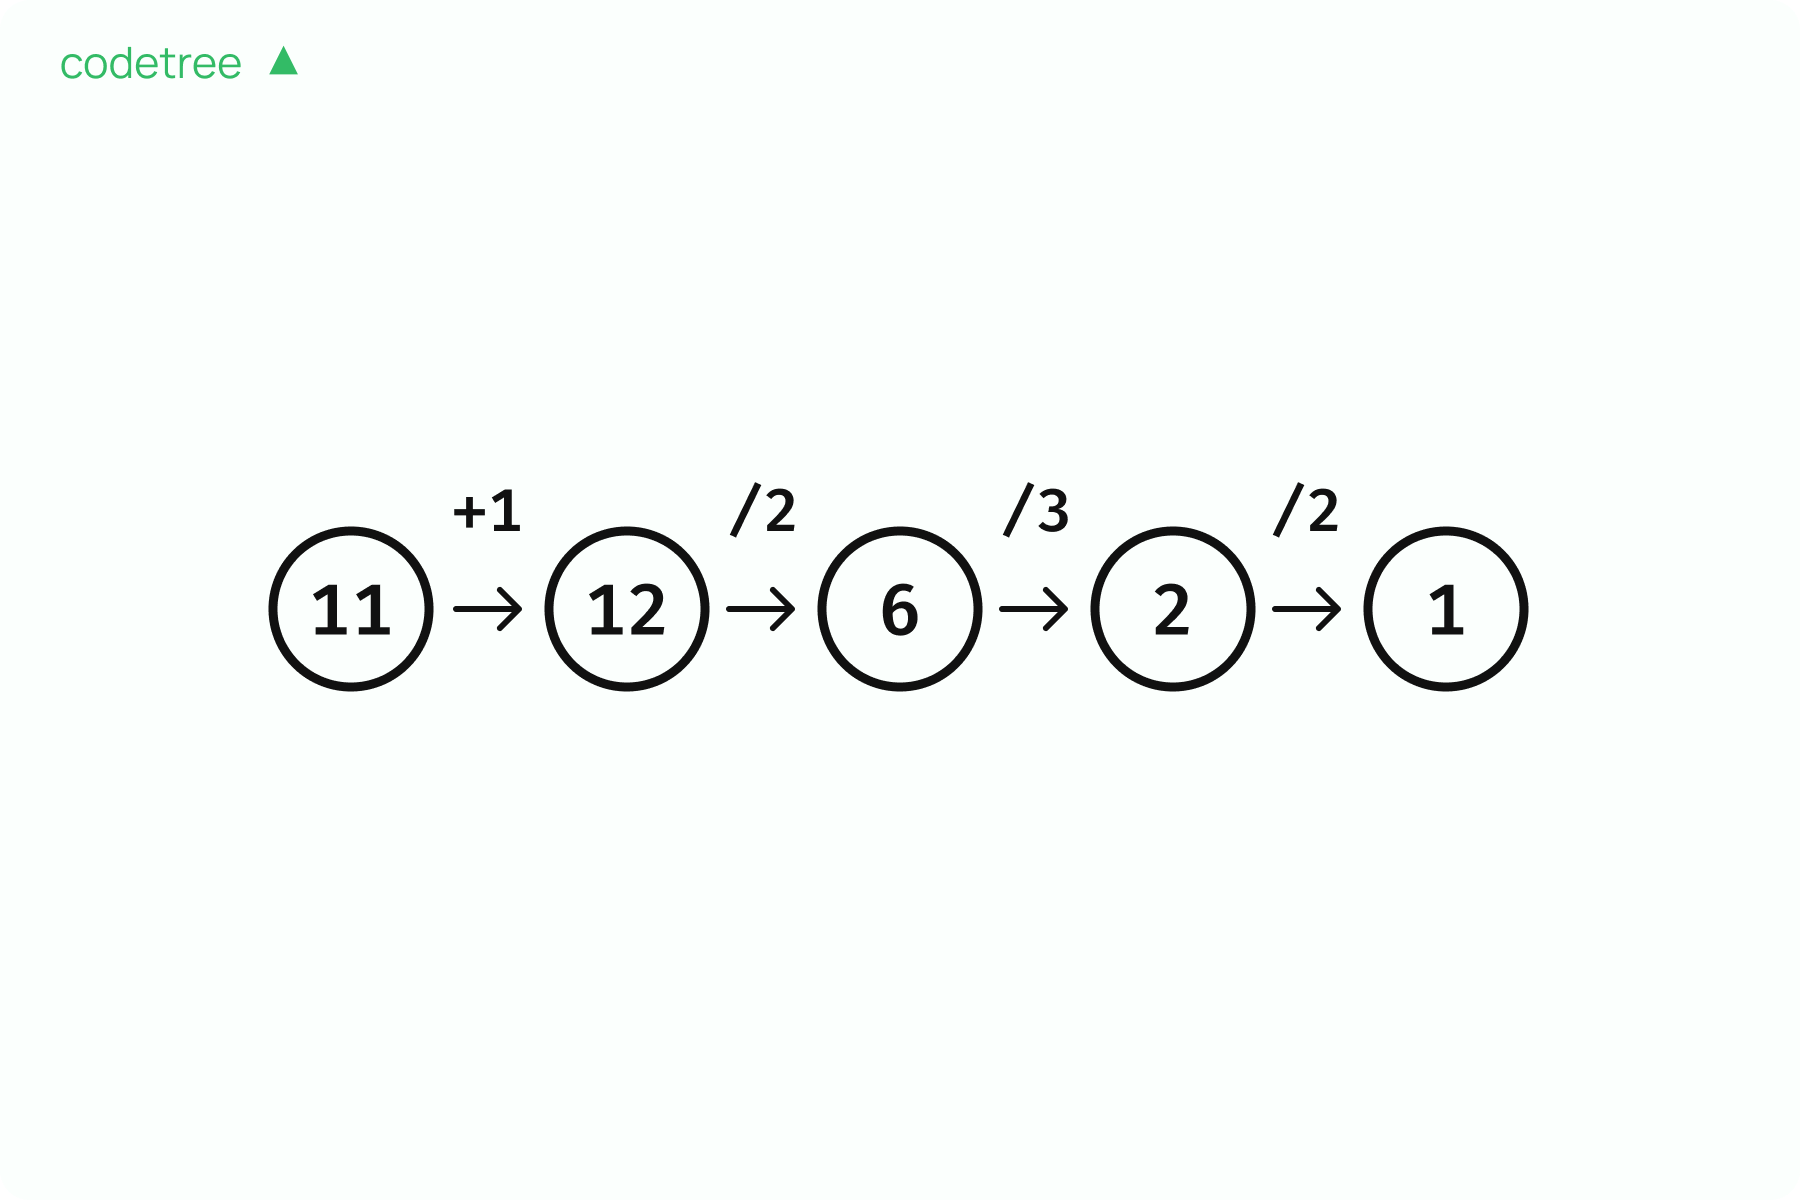

1을 만들기 위해 필요한 최소 연산 횟수를 구하는 프로그램을 작성해보세요.

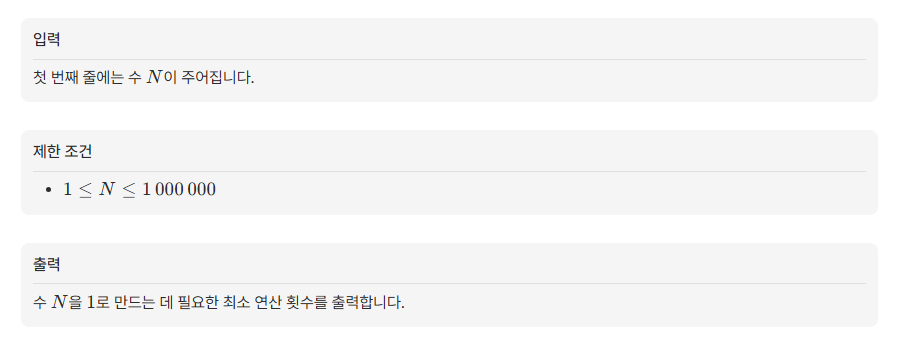

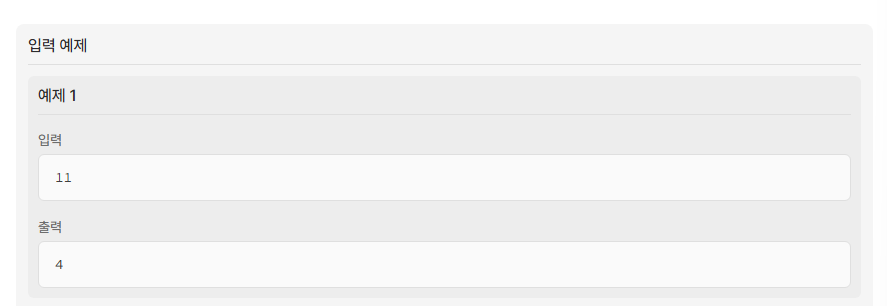

In [2]:
# 사용자로부터 정수 N을 입력받습니다.
N = int(input())

# 시작 숫자가 이미 1이라면 연산이 0번 필요하므로 0을 출력하고 끝냅니다.
if N == 1:
    print(0)
else:
    # 숫자들을 정점(위치)으로 생각하고, 넉넉하게 N의 2배 크기의 거리 기록장(배열)을 만듭니다.
    # (+1 연산 때문에 N보다 조금 더 커졌다가 나누어지는 경우도 있으므로 여유 공간을 둡니다.)
    MAX_SIZE = N * 2

    # 각 숫자에 도달하는 데 걸린 '최소 연산 횟수'를 저장할 리스트입니다.
    # 아직 한 번도 만들지 않은 숫자는 -1로 표시합니다.
    dist = [-1] * MAX_SIZE

    # BFS 탐색을 위한 큐(리스트)를 만들고 시작점 N을 넣습니다.
    queue = [N]

    # 시작점 N은 연산 횟수가 0번이므로 0으로 설정합니다. (-1에서 0이 되어 방문 처리 완료!)
    dist[N] = 0

    # 초고속 큐를 위한 머리(head) 인덱스입니다.
    head = 0

    # 큐에 숫자가 남아있는 동안 계속 반복합니다.
    while head < len(queue):
        # 큐에서 현재 숫자(curr)를 하나 꺼냅니다.
        curr = queue[head]
        head += 1

        # [종료 조건] 만약 현재 숫자가 우리가 목표로 하는 1이 되었다면?
        if curr == 1:
            # 1에 도달하기까지 걸린 최소 연산 횟수를 출력하고 탐색을 완전히 종료합니다.
            print(dist[curr])
            break

        # 현재 숫자에서 할 수 있는 4가지 연산의 결과를 담을 빈 리스트를 만듭니다.
        next_steps = []

        # 1. 현재 수에서 1을 뺍니다.
        next_steps.append(curr - 1)

        # 2. 현재 수에 1을 더합니다.
        next_steps.append(curr + 1)

        # 3. 현재 수가 2로 나누어 떨어지면, 2로 나눈 몫을 추가합니다.
        if curr % 2 == 0:
            next_steps.append(curr // 2)

        # 4. 현재 수가 3으로 나누어 떨어지면, 3으로 나눈 몫을 추가합니다.
        if curr % 3 == 0:
            next_steps.append(curr // 3)

        # 만들어진 다음 숫자(nxt)들을 하나씩 확인합니다.
        for nxt in next_steps:
            # 1. 숫자가 1 이상이고, 우리가 만든 배열의 범위를 벗어나지 않으며
            # 2. 아직 한 번도 도달한 적 없는 숫자(-1)라면?
            if 1 <= nxt < MAX_SIZE and dist[nxt] == -1:
                # 다음 숫자에 (현재까지의 연산 횟수 + 1)을 기록합니다.
                dist[nxt] = dist[curr] + 1
                # 다음 번에 이 숫자에서 또 연산을 뻗어나가기 위해 큐에 추가합니다.
                queue.append(nxt)

11
4


# 6일차

# 각 정점까지의 최단 경로

20XP

평균 27분

60% 정답률

총 제출 1,086회
___
정점 N 개와 간선 M 개로 구성된 무방향 그래프가 주어집니다. 편의상, 각 정점에 1번부터 N번까지 번호를 부여합니다.

K번 정점에서 다른 모든 정점으로 가는 최단 경로를 구하는 프로그램을 작성하세요.

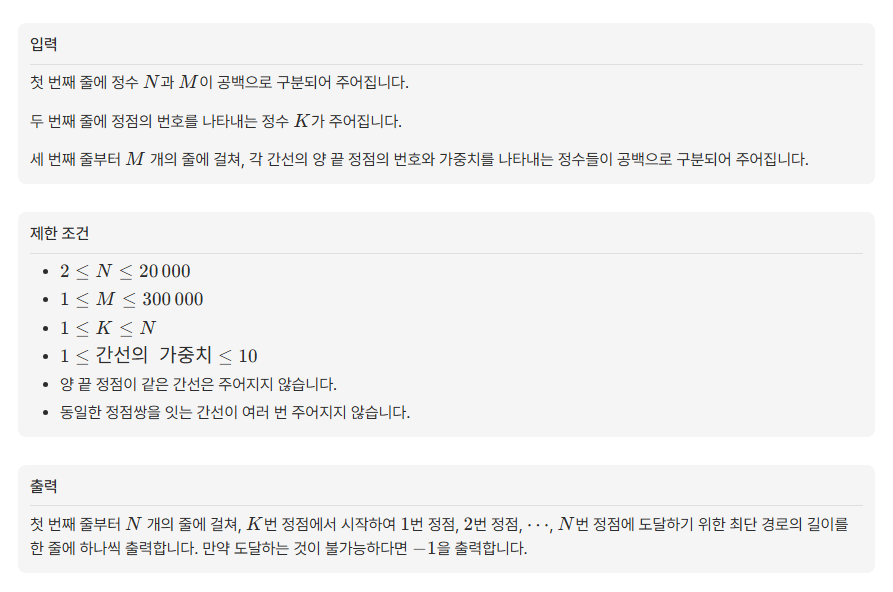

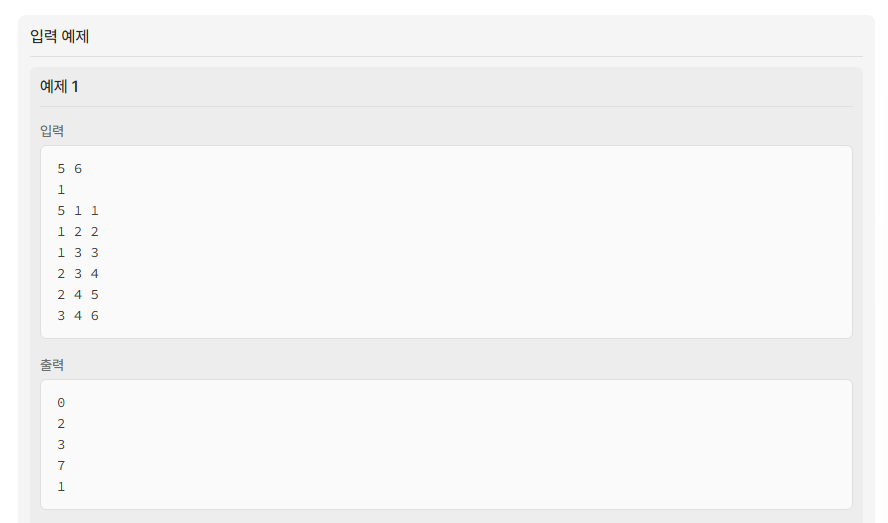

In [3]:
# 파이썬에 기본으로 내장된 우선순위 큐 모듈을 불러옵니다. (시간 단축의 핵심!)
import heapq

# sys 모듈을 쓸 수 없으므로, 무한대(INT_MAX)를 10억(1e9)으로 직접 설정합니다.
INF = int(1e9)

# 첫째 줄에서 정점의 개수(n)와 간선의 개수(m)를 공백 기준으로 입력받습니다.
n, m = map(int, input().split())

# 둘째 줄에서 시작 정점(k)을 따로 입력받습니다. (런타임 에러 완벽 해결!)
k = int(input())

# 그래프의 연결 상태를 저장할 2차원 빈 리스트를 만듭니다. (1번부터 쓰기 위해 n + 1 크기)
graph = [[] for _ in range(n + 1)]

# 거리 기록장(dist)을 만듭니다. 처음에는 아는 길이 없으니 전부 무한대(INF)로 설정합니다.
dist = [INF] * (n + 1)

# m개의 줄에 걸쳐 간선 정보를 입력받아 그래프 지도를 그립니다.
for _ in range(m):
    x, y, z = map(int, input().split())
    # 양방향 통행이 가능하므로 양쪽 정점에 모두 가중치(거리)를 추가합니다.
    graph[x].append((y, z))
    graph[y].append((x, z))

# 시작점(k)에서 자기 자신(k)으로 가는 최단 거리는 당연히 0입니다.
dist[k] = 0

# 가장 거리가 짧은 정점을 자동으로 1등으로 뽑아주는 마법의 바구니(우선순위 큐)를 만듭니다.
pq = []

# 시작점의 정보 (거리: 0, 정점 번호: k)를 큐에 넣습니다.
# 파이썬의 heapq는 항상 '튜플의 첫 번째 값'을 기준으로 오름차순 정렬하므로 반드시 거리를 먼저 써야 합니다!
heapq.heappush(pq, (0, k))

# 큐에 탐색할 정점이 남아있는 동안 무한 반복합니다.
while pq:
    # 큐에서 현재 갈 수 있는 곳 중 '가장 거리가 짧은' 정점의 정보(거리, 번호)를 꺼냅니다.
    min_dist, min_index = heapq.heappop(pq)

    # [핵심 가지치기] 방금 꺼낸 거리(min_dist)가 기록장(dist)에 이미 갱신된 거리보다 멀다면?
    # 이는 과거에 큐에 들어갔던 '느린 낡은 정보'이므로 굳이 탐색할 필요 없이 무시(pass)합니다.
    if min_dist > dist[min_index]:
        continue

    # 현재 가장 가깝다고 확정된 정점(min_index)과 연결된 이웃 정점들을 하나씩 살펴봅니다.
    for target_index, target_dist in graph[min_index]:
        # (시작점에서 현재 정점까지 온 최단 거리) + (이웃 정점까지 가는 거리)를 계산합니다.
        new_dist = min_dist + target_dist

        # 만약 이 새롭게 계산한 길이 기록장에 적혀있는 이웃의 기존 거리보다 더 짧다면?
        if new_dist < dist[target_index]:
            # 1. 기록장의 거리를 이 더 짧은 새로운 거리로 쓱싹 지우고 업데이트합니다!
            dist[target_index] = new_dist

            # 2. 이 이웃 정점이 다른 곳으로 가는 더 빠른 징검다리가 될 수 있으므로 큐에 넣어줍니다.
            heapq.heappush(pq, (new_dist, target_index))

# 모든 맵의 탐색이 끝난 후, 1번 정점부터 n번 정점까지의 최단 거리를 차례대로 출력합니다.
for i in range(1, n + 1):
    # 만약 도달할 수 없는 끊어진 정점이라 여전히 무한대(INF)라면?
    if dist[i] == INF:
        print(-1) # 문제의 조건에 맞게 -1을 출력합니다.
    else:
        # 무사히 도달했다면 계산된 최단 거리를 출력합니다.
        print(dist[i])

5 6
1
5 1 1
1 2 2
1 3 3
2 3 4
2 4 5
3 4 6
0
2
3
7
1


# 가장 오래 걸리는 학생 2

20XP

평균 22분

73% 정답률

총 제출 607회
___
N개의 서로 다른 장소가 있습니다. 1번부터 N−1번 장소에는 학생이 한 명씩 살고 있고, N번 장소는 학교입니다. 두 개의 장소를 연결하는 간선은 없거나, 있다면 최대 1개만 있으며, 주어지는 모든 간선은 방향성을 갖습니다. 간선마다 길이 d가 주어지며, 각 학생은 등교 시 최단거리로 학교로 이동한다고 합니다. 모든 학생은 거리 1을 이동하는 데 1초의 시간이 걸린다고 했을 때, 학교에 등교하는 데 가장 오래 걸리는 학생의 소요 시간을 구하는 프로그램을 작성해보세요.

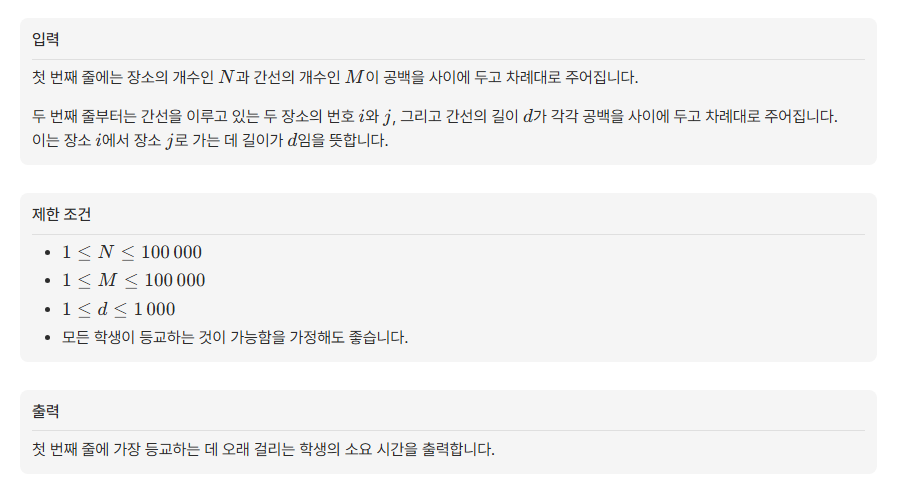

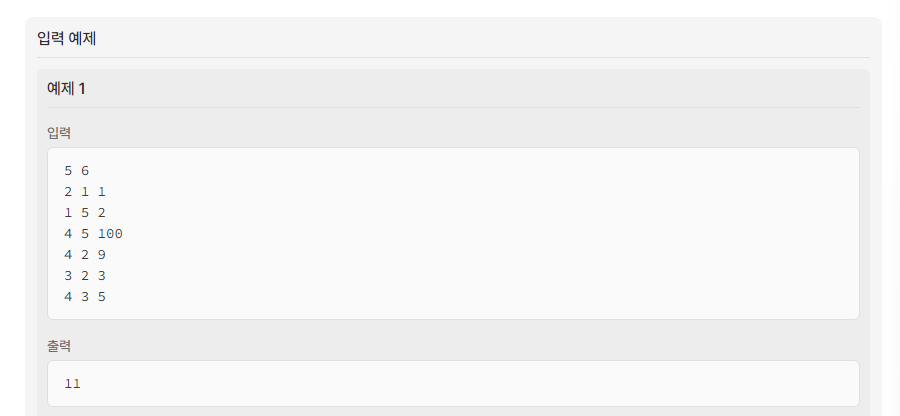

In [4]:
import heapq

# 사용자로부터 장소의 수(N)와 간선의 수(M)를 입력받습니다.
N, M = map(int, input().split())

# 도착지(학교)에서 거꾸로 출발하기 위해 '방향이 뒤집힌 그래프'를 만듭니다.
reversed_graph = [[] for _ in range(N + 1)]

# M개의 간선 정보를 입력받습니다.
for _ in range(M):
    u, v, d = map(int, input().split())
    # 원래는 u에서 v로 가는 길이지만, 학교에서 거꾸로 탐색할 것이므로
    # v에서 u로 가는 길로 방향을 뒤집어서 저장합니다! (핵심 아이디어)
    reversed_graph[v].append((u, d))

# 최단 거리를 기록할 배열을 만듭니다. 무한대는 10억(1e9)으로 설정합니다.
INF = int(1e9)
dist = [INF] * (N + 1)

# 학교(N번 장소)에서 거꾸로 출발하므로, 학교의 거리를 0으로 설정합니다.
dist[N] = 0

# 가장 거리가 짧은 정점을 자동으로 찾아주는 우선순위 큐(heapq)를 준비합니다.
pq = []

# 시작점인 학교의 정보 (거리: 0, 정점 번호: N)를 큐에 넣습니다.
heapq.heappush(pq, (0, N))

# 큐에 탐색할 곳이 남아있는 동안 다익스트라 알고리즘을 진행합니다.
while pq:
    # 현재 가장 거리가 짧은 정점(min_index)과 그 거리(min_dist)를 꺼냅니다.
    min_dist, min_index = heapq.heappop(pq)

    # 이미 더 짧은 경로로 기록장이 갱신된 적이 있다면 (오래된 정보라면) 무시합니다.
    if min_dist > dist[min_index]:
        continue

    # 현재 정점과 연결된 이웃 정점(원래 그래프에서는 나에게로 오던 출발지들)을 확인합니다.
    for target_index, target_dist in reversed_graph[min_index]:
        # 학교에서 현재 정점을 거쳐 이웃 정점까지 가는 거리를 계산합니다.
        new_dist = min_dist + target_dist

        # 만약 새롭게 계산한 거리가 기존에 알고 있던 거리보다 짧다면?
        if new_dist < dist[target_index]:
            # 최단 거리를 갱신하고 다음 탐색을 위해 큐에 넣습니다.
            dist[target_index] = new_dist
            heapq.heappush(pq, (new_dist, target_index))

# 1번부터 N-1번 장소(학생들이 사는 곳)까지의 최단 거리 중 가장 큰 값을 찾습니다.
max_time = 0
for i in range(1, N):
    # 도달할 수 있는 학생들 중, 가장 오래 걸리는 시간을 갱신합니다.
    if dist[i] != INF and dist[i] > max_time:
        max_time = dist[i]

# 학교에 등교하는 데 가장 오래 걸리는 학생의 소요 시간을 출력합니다.
print(max_time)

5 6
2 1 1
1 5 2
4 5 100
4 2 9
3 2 3
4 3 5
11


# 가장 가까운 거리의 최댓값

40XP

평균 123분

59% 정답률

총 제출 371회
___
N개의 정점과 M개의 간선으로 이루어진 양방향 그래프에 대한 정보가 주어집니다. 정점 A, B, C가 주어졌을 때, 특정 정점을 잘 잡아 정점 A, B, C 중 가장 가까운 정점까지의 거리가 최대가 되도록 하는 프로그램을 작성해보세요.

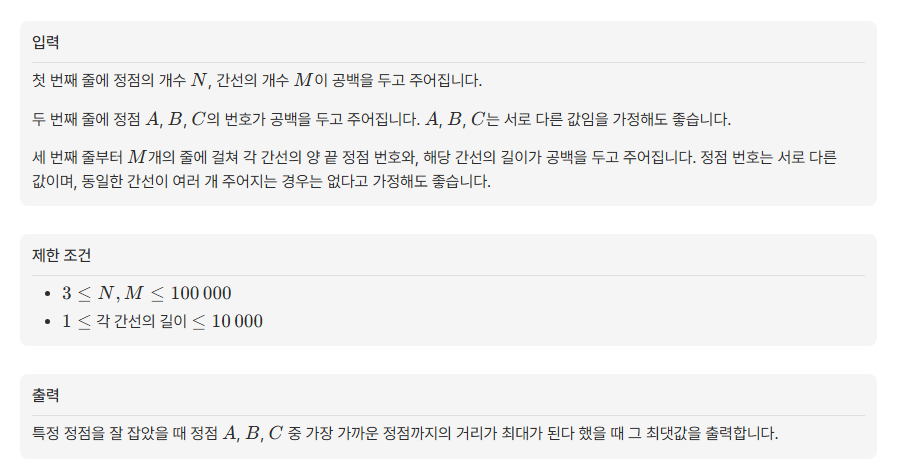

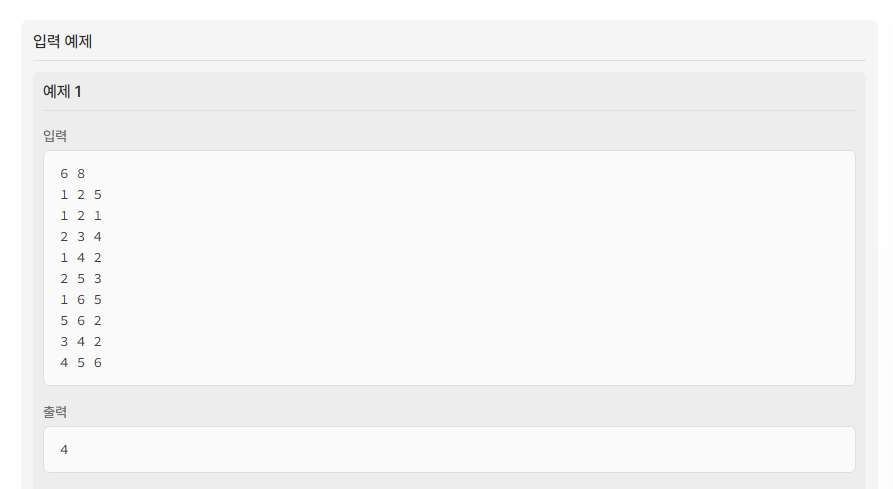

In [5]:
import heapq

# 무한대를 의미하는 아주 큰 수(10억)를 설정합니다.
INF = int(1e9)

# 사용자로부터 정점의 개수(N)와 간선의 개수(M)를 입력받습니다.
N, M = map(int, input().split())

# 세 명의 친구가 출발할 시작점 A, B, C를 입력받습니다.
A, B, C = map(int, input().split())

# 그래프의 연결 상태를 저장할 2차원 리스트를 만듭니다. (정점 번호 1번부터 시작)
graph = [[] for _ in range(N + 1)]

# M개의 줄에 걸쳐 양방향 간선 정보를 입력받습니다.
for _ in range(M):
    u, v, w = map(int, input().split())
    # 양방향 통행이므로 양쪽 모두에 가중치(거리)를 추가합니다.
    graph[u].append((v, w))
    graph[v].append((u, w))

# 다익스트라 알고리즘을 '함수'로 만듭니다. (시작점 start를 입력받아 거리 배열을 반환합니다)
def dijkstra(start):
    # 이 시작점에서부터 다른 모든 정점까지의 거리를 기록할 배열을 무한대로 초기화합니다.
    dist = [INF] * (N + 1)

    # 자기 자신으로 가는 거리는 0입니다.
    dist[start] = 0

    # 최단 거리를 뽑아줄 우선순위 큐를 만들고, 시작점(거리 0, 번호 start)을 넣습니다.
    pq = []
    heapq.heappush(pq, (0, start))

    # 큐에 탐색할 정점이 남아있는 동안 반복합니다.
    while pq:
        # 현재 갈 수 있는 가장 가까운 정점을 꺼냅니다.
        min_dist, min_index = heapq.heappop(pq)

        # 꺼낸 거리가 이미 기록장에 적힌 거리보다 길다면, 오래된 정보이므로 무시합니다.
        if min_dist > dist[min_index]:
            continue

        # 현재 정점과 연결된 이웃들을 확인합니다.
        for target_index, target_dist in graph[min_index]:
            # (현재까지 온 거리) + (이웃으로 가는 거리)를 계산합니다.
            new_dist = min_dist + target_dist

            # 계산된 거리가 기록장의 거리보다 짧다면 업데이트합니다.
            if new_dist < dist[target_index]:
                dist[target_index] = new_dist
                # 갱신된 정보를 큐에 다시 넣어줍니다.
                heapq.heappush(pq, (new_dist, target_index))

    # 탐색이 모두 끝난 후, 이 시작점에서 출발한 완벽한 거리 기록장(배열)을 반환합니다.
    return dist

# 1. A를 시작점으로 하는 모든 정점까지의 거리를 구합니다.
dist_a = dijkstra(A)

# 2. B를 시작점으로 하는 모든 정점까지의 거리를 구합니다.
dist_b = dijkstra(B)

# 3. C를 시작점으로 하는 모든 정점까지의 거리를 구합니다.
dist_c = dijkstra(C)

# 정답(가장 가까운 거리 중 최댓값)을 저장할 변수를 0으로 시작합니다.
max_of_mins = 0

# 1번 정점부터 N번 정점까지 하나씩(i) 살펴보면서 최고의 아지트를 찾습니다.
for i in range(1, N + 1):
    # 현재 정점 i가 만약 도달할 수 없는 곳(INF)이라면 건너뜁니다.
    if dist_a[i] == INF or dist_b[i] == INF or dist_c[i] == INF:
        continue

    # 세 명의 친구(A, B, C) 중 아지트(i)와 '가장 가까운 거리'를 구합니다.
    current_min = min(dist_a[i], dist_b[i], dist_c[i])

    # 그 '가장 가까운 거리'가 기존에 찾았던 최댓값보다 더 크다면 갱신합니다!
    if current_min > max_of_mins:
        max_of_mins = current_min

# 최종적으로 찾아낸 최고의 거리를 출력합니다.
print(max_of_mins)

6 8
1 2  5
1 2 1
2 3 4
1 4 2
2 5 3
1 6 5
5 6 2
3 4 2
4 5 6
4


# 다른 괄호로 이동하기

80XP

평균 165분

52% 정답률

총 제출 370회
___
N×N 개의 칸 안에 ( 또는 ) 가 적혀있습니다. 인접한 칸 사이의 이동이 가능하며, 대각선 방향으로의 이동은 불가능합니다. 이동하려는 칸의 기호가 현재 칸의 기호와 같을 경우 A시간이, 다를 경우 B시간이 걸립니다.

모든 칸에 대해 임의로 출발칸과 도착칸을 정하여 두 칸 사이의 이동시간의 최솟값을 구했을 때, 이 중 최댓값을 구하는 프로그램을 작성해보세요.

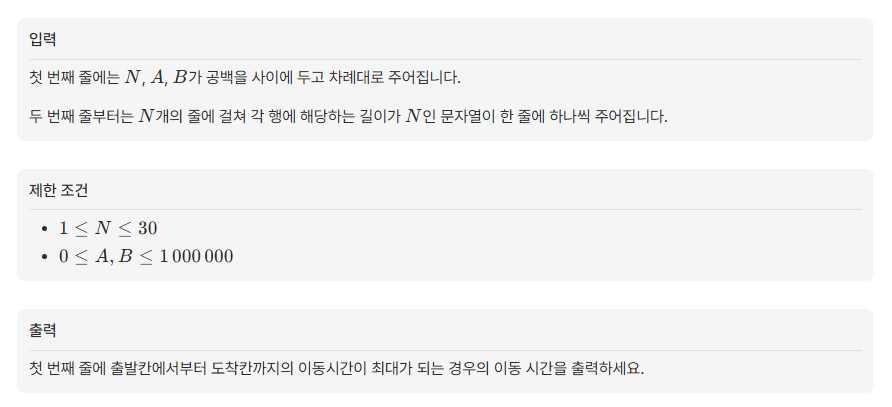

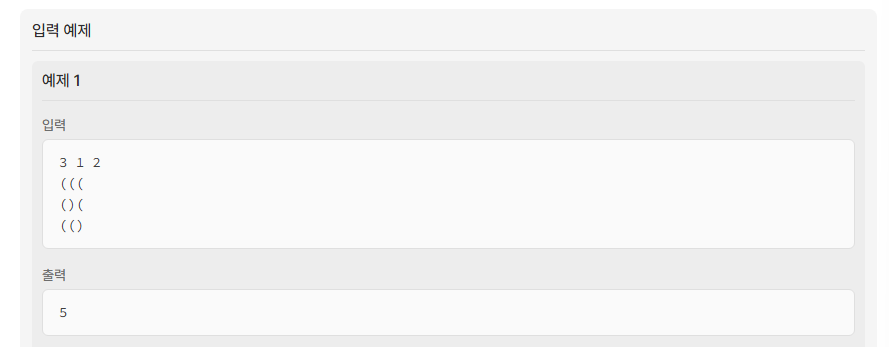

In [6]:
import heapq

# 사용자로부터 격자의 크기 N, 같은 괄호 이동 시간 A, 다른 괄호 이동 시간 B를 입력받습니다.
N, A, B = map(int, input().split())

# 괄호들이 적힌 N x N 크기의 2차원 지도를 입력받습니다.
# 문자열은 그 자체로 리스트처럼 인덱싱이 가능하므로 그대로 리스트에 담습니다.
grid = [list(input()) for _ in range(N)]

# 무한대를 의미하는 10억을 설정합니다. (sys 모듈 대체)
INF = int(1e9)

# 상하좌우 4가지 방향으로 이동하기 위한 방향키입니다.
dx = [-1, 1, 0, 0]
dy = [0, 0, -1, 1]

# 특정 시작점(start_x, start_y)에서 출발했을 때,
# 다른 모든 칸으로 가는 최단 거리를 구하는 다익스트라 함수입니다.
def dijkstra(start_x, start_y):
    # 각 칸까지 가는 데 걸리는 최단 시간을 기록할 2차원 배열을 무한대로 초기화합니다.
    dist = [[INF] * N for _ in range(N)]

    # 자기 자신(출발점)으로 가는 시간은 0입니다.
    dist[start_x][start_y] = 0

    # 가장 짧은 시간을 가진 칸을 뽑아줄 우선순위 큐를 만듭니다.
    pq = []

    # 시작점의 정보 (시간: 0, x좌표, y좌표)를 큐에 넣습니다.
    heapq.heappush(pq, (0, start_x, start_y))

    # 큐에 탐색할 곳이 남아있는 동안 반복합니다.
    while pq:
        # 현재 갈 수 있는 가장 시간이 적게 걸리는 칸을 꺼냅니다.
        current_time, x, y = heapq.heappop(pq)

        # 꺼낸 시간이 이미 기록장에 적힌 시간보다 크다면 (오래된 정보라면) 무시합니다.
        if current_time > dist[x][y]:
            continue

        # 상하좌우 4방향을 확인하며 이웃 칸으로 이동을 시도합니다.
        for i in range(4):
            nx = x + dx[i]
            ny = y + dy[i]

            # 지도의 범위를 벗어나지 않는 안전한 칸이라면?
            if 0 <= nx < N and 0 <= ny < N:
                # 조건에 따라 이동 시간(가중치)을 계산합니다.
                # 현재 칸의 괄호와 다음 칸의 괄호가 같다면 시간 A가 걸립니다.
                if grid[x][y] == grid[nx][ny]:
                    cost = A
                # 괄호 모양이 서로 다르다면 시간 B가 걸립니다.
                else:
                    cost = B

                # (현재 칸까지 온 시간) + (다음 칸으로 가는 이동 시간)을 계산합니다.
                new_time = current_time + cost

                # 만약 이 새로운 시간이 기존 기록장에 적힌 시간보다 더 빠르다면?
                if new_time < dist[nx][ny]:
                    # 최단 시간을 갱신합니다.
                    dist[nx][ny] = new_time
                    # 갱신된 정보를 다음 탐색을 위해 큐에 다시 넣어줍니다.
                    heapq.heappush(pq, (new_time, nx, ny))

    # 이 시작점에서 출발한 탐색이 모두 끝났습니다.
    # 지도의 모든 칸 중에서 '가장 오래 걸린(가장 숫자가 큰) 시간'을 찾아 반환합니다.
    max_time = 0
    for i in range(N):
        for j in range(N):
            # 도달할 수 있는 칸 중에서 최댓값을 찾습니다.
            if dist[i][j] != INF and dist[i][j] > max_time:
                max_time = dist[i][j]

    return max_time

# 정답(모든 시작점에 대한 최댓값 중 가장 큰 값)을 저장할 변수입니다.
answer = 0

# 지도의 모든 칸 (0,0)부터 (N-1, N-1)까지 하나씩 시작점으로 삼아 다익스트라를 실행합니다.
for i in range(N):
    for j in range(N):
        # (i, j) 칸에서 출발했을 때 가장 오래 걸리는 시간을 구합니다.
        current_max = dijkstra(i, j)

        # 그 시간이 역대급으로 컸다면 정답을 갱신합니다.
        if current_max > answer:
            answer = current_max

# 최종적으로 가장 크게 나온 이동 시간의 최댓값을 출력합니다.
print(answer)

3 1 2
(((
()(
(()
5


# 7일차

# 집합의 원소

20XP

평균 20분

66% 정답률

총 제출 528회
___
여러 집합을 관리하는 프로그램을 작성하고자 합니다.
초기에는 다음 집합들이 존재합니다.

{1},{2},{3},…,{N}

다시 말하자면, 1부터 N까지 자기 자신만이 포함된 집합들이 존재합니다.

이제 이러한 집합들에 대해서, 다음 두 연산을 지원하고자 합니다.

0 a b : a가 포함된 집합과 b가 포함된 집합을 합칩니다. 만약 이미 같은 집합에 속한다면, 아무것도 하지 않습니다.

1 a b : a와 b가 같은 집합 안에 있다면 1을, 그렇지 않다면 0을 출력합니다.

위와 같은 연산을 총 M번 실행하는 프로그램을 작성해보세요.

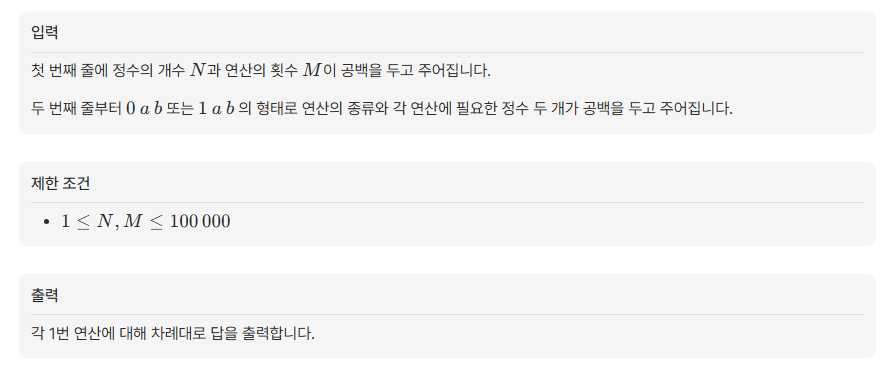

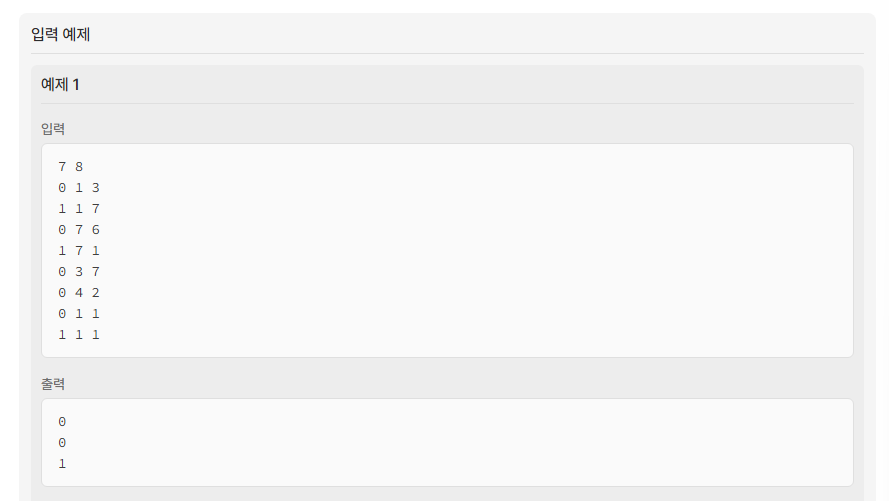

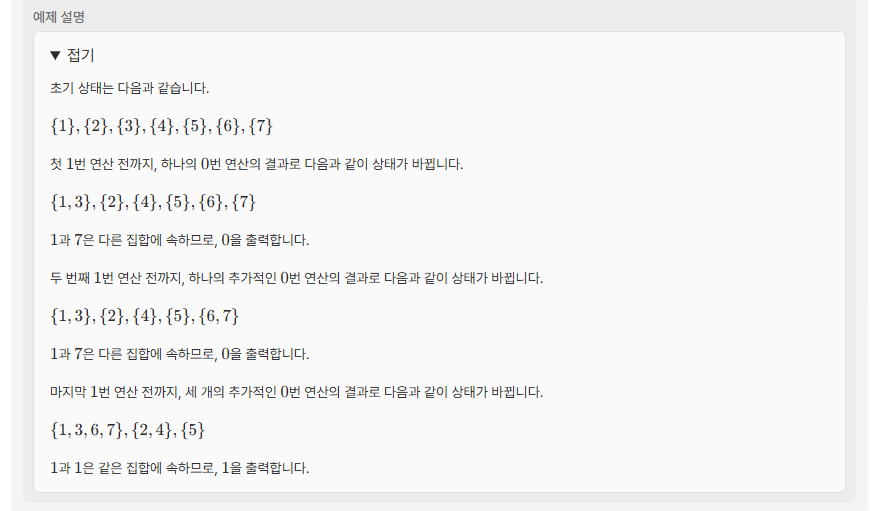

In [8]:
# 사용자로부터 원소의 개수 N과 연산의 개수 M을 입력받습니다.
N, M = map(int, input().split())

# 각 원소의 '직속 보스'를 기록할 배열을 만듭니다.
# 처음에는 모두가 자기 자신을 보스로 모십니다. (1번의 보스는 1번, N번의 보스는 N번)
parent = [i for i in range(N + 1)]

# [Find 연산] 특정 원소(x)의 '최고 보스(루트 노드)'를 찾는 함수입니다.
def find(x):
    # 1. 먼저 최고 보스가 누구인지 거S슬러 올라가며 찾습니다.
    root = x
    # 나의 보스가 나 자신이 아닐 때까지 (즉, 누군가의 밑에 있는 동안) 계속 거슬러 올라갑니다.
    while parent[root] != root:
        root = parent[root]

    # 2. [핵심] 경로 압축 (Path Compression)
    # 최고 보스를 찾았으니, 거슬러 올라왔던 길을 다시 되짚어가며
    # 그 길에 있던 모든 사람들의 직속 보스를 '최고 보스(root)'로 직통 연결해 줍니다!
    curr = x
    while curr != root:
        next_node = parent[curr] # 원래의 직속 보스를 잠시 기억해 둡니다.
        parent[curr] = root      # 나의 보스를 '최고 보스'로 바꿉니다.
        curr = next_node         # 다음 사람(원래 보스)으로 넘어가서 똑같이 작업합니다.

    # 최종적으로 찾은 최고 보스를 반환합니다.
    return root

# [Union 연산] 두 원소(a, b)가 속한 무리를 하나로 합치는 함수입니다.
def union(a, b):
    # a와 b의 최고 보스를 각각 찾습니다.
    root_a = find(a)
    root_b = find(b)

    # 두 최고 보스가 서로 다르다면 (즉, 아직 다른 무리라면)
    if root_a != root_b:
        # b의 최고 보스를 a의 최고 보스 밑으로 집어넣어 한 무리로 만듭니다.
        # (반대로 root_a = root_b 로 해도 상관없습니다)
        parent[root_b] = root_a

# M번의 연산을 하나씩 처리합니다.
for _ in range(M):
    # 연산 종류(cmd)와 두 원소 a, b를 입력받습니다.
    cmd, a, b = map(int, input().split())

    # 1. cmd가 0이면 합치기(Union) 연산입니다.
    if cmd == 0:
        union(a, b)

    # 2. cmd가 1이면 같은 무리인지 확인(Find)하는 연산입니다.
    else:
        # 두 원소의 최고 보스가 같다면 같은 집합입니다.
        if find(a) == find(b):
            print(1) # 같은 집합이므로 1 출력
        else:
            print(0) # 다른 집합이므로 0 출력

7 8
0 1 3
1 1 7
0
0 7 6
1 7 1
0
0 3 7
0 4 2
0 1 1
1 1 1
1


# 연결된 정점

30XP

평균 30분

41% 정답률

총 제출 591회
___
1부터 N까지의 정점이 있습니다.

이 정점들로 다음과 같은 입력에 따라 연산을 하려 합니다.

x a b : 정점 a와 정점 b를 간선으로 연결합니다.

y a : 정점 a 와 연결되어있는 정점의 개수를 출력합니다.

위와 같은 연산을 총 M번 실행하는 프로그램을 작성하세요.

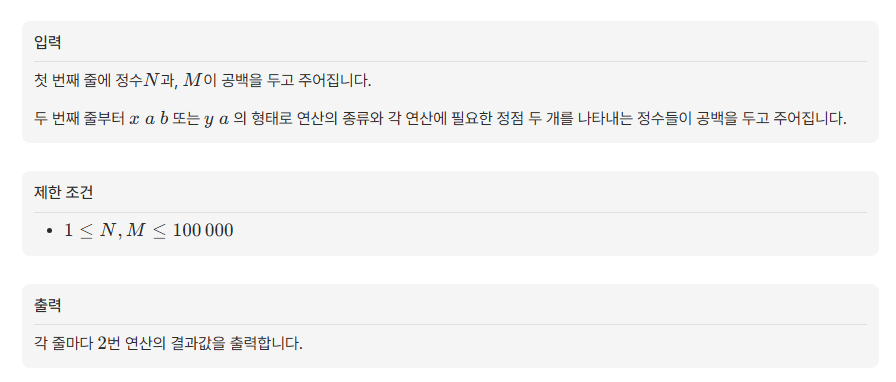

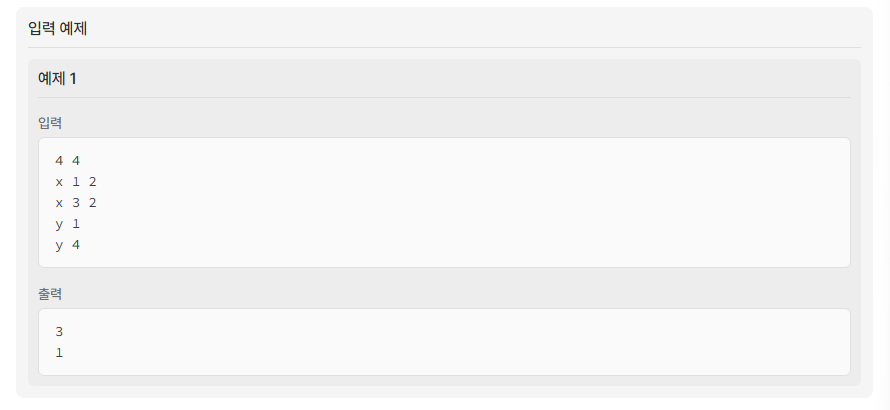

In [9]:
# 사용자로부터 정점의 개수 N과 연산의 횟수 M을 입력받습니다.
N, M = map(int, input().split())

# 각 정점의 '직속 보스'를 기록할 배열을 만듭니다. (처음엔 모두 자기 자신이 보스)
parent = [i for i in range(N + 1)]

# 각 '최고 보스'가 거느리고 있는 무리의 총 인원수를 기록할 배열입니다.
# 처음에는 모두가 혼자이므로 1명씩으로 초기화합니다.
size = [1] * (N + 1)

# 특정 정점(x)의 '최고 보스'를 찾는 함수입니다. (경로 압축 포함)
def find(x):
    # 1. 최고 보스가 누구인지 거슬러 올라가며 찾습니다.
    root = x
    while parent[root] != root:
        root = parent[root]

    # 2. 찾으러 올라갔던 길을 되짚어보며, 만나는 모든 사람의 보스를 '최고 보스'로 바꿉니다.
    curr = x
    while curr != root:
        next_node = parent[curr]
        parent[curr] = root
        curr = next_node

    # 최종적으로 찾은 최고 보스를 반환합니다.
    return root

# 두 정점(a, b)이 속한 무리를 하나로 합치는 함수입니다.
def union(a, b):
    # 두 정점의 최고 보스를 각각 찾습니다.
    root_a = find(a)
    root_b = find(b)

    # 두 보스가 서로 다르다면 (아직 다른 무리라면) 합칩니다.
    if root_a != root_b:
        # b의 보스를 a의 보스 밑으로 넣습니다. (한 무리가 됨)
        parent[root_b] = root_a

        # [핵심] b 보스가 이끌던 인원수를 a 보스의 인원수에 전부 더해줍니다!
        size[root_a] += size[root_b]

# M번의 연산을 차례대로 처리합니다.
for _ in range(M):
    # 이번 문제의 입력은 문자('x' 또는 'y')와 숫자가 섞여 있으므로,
    # split()으로 쪼갠 뒤 첫 번째 글자로 어떤 명령인지 구분합니다.
    command = input().split()

    # 1. 만약 첫 글자가 'x' 라면? (합치기 연산)
    if command[0] == 'x':
        # 뒤에 따라온 두 숫자를 정수로 변환합니다.
        a = int(command[1])
        b = int(command[2])
        # 두 정점을 하나의 무리로 합칩니다.
        union(a, b)

    # 2. 만약 첫 글자가 'y' 라면? (인원수 확인 연산)
    elif command[0] == 'y':
        # 뒤에 따라온 숫자를 정수로 변환합니다.
        a = int(command[1])

        # a가 속한 무리의 '최고 보스'를 찾습니다.
        root_a = find(a)

        # 그 최고 보스가 가지고 있는 세력(인원수)을 출력합니다!
        print(size[root_a])

4 4
x 1 2
x 3 2
y 1
3
y 4
1


# 8일차

# 친구의 키

20XP

평균 17분

82% 정답률

총 제출 298회
___
n명의 친구가 키가 큰 사람부터 내림차순으로 순서대로 서있습니다. 이때 n명의 친구는 모두 키가 다르며, 어떤 순서로 서있는지에 대한 단서로 m개의 정보가 주어집니다. 각 정보는 (a,b) 형태로 주어지며, 이는 a번 친구가 b번 친구보다 키가 크다는 것을 의미합니다. 친구들이 서있는 순서를 앞에서부터 차례대로 구해주는 프로그램을 작성해보세요.

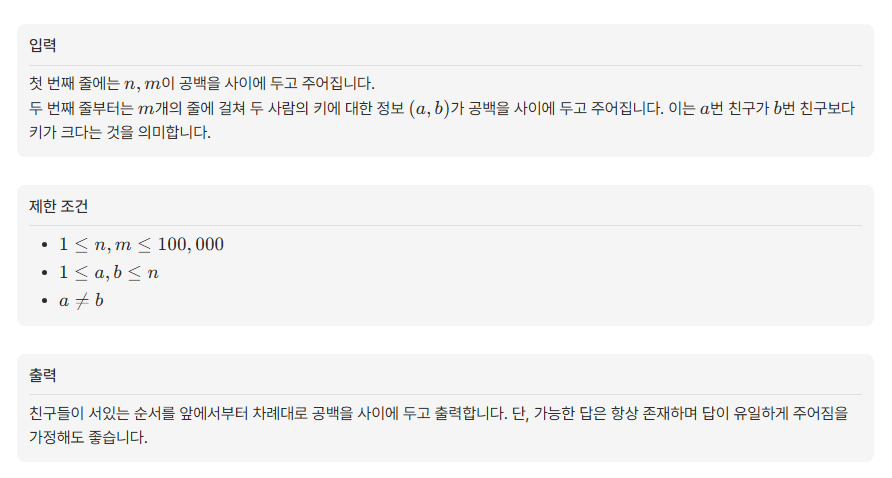

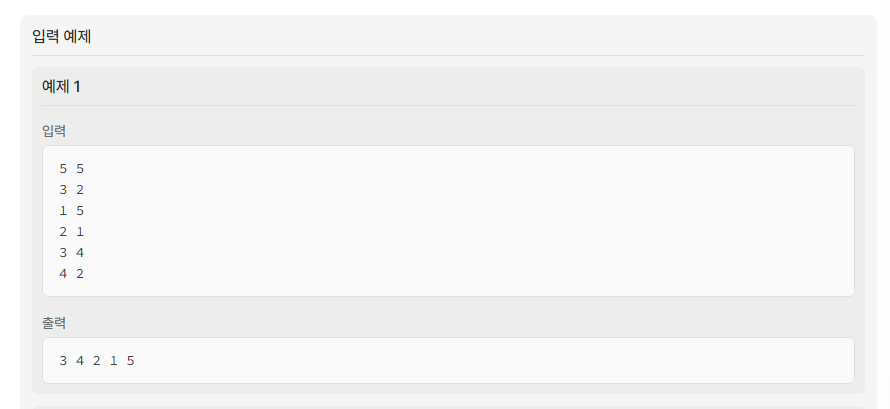

In [11]:
# 사용자로부터 친구의 수(n)와 키 비교 정보의 수(m)를 입력받습니다.
n, m = map(int, input().split())

# "누가 누구보다 큰지" 방향 화살표를 저장할 그래프(2차원 리스트)입니다.
graph = [[] for _ in range(n + 1)]

# 각 친구들의 '진입차수(나보다 큰 사람이 몇 명인지)'를 기록할 배열입니다.
# 처음에는 모두 0으로 시작합니다.
in_degree = [0] * (n + 1)

# m개의 키 비교 정보를 입력받습니다.
for _ in range(m):
    # a가 b보다 키가 크다는 의미입니다.
    a, b = map(int, input().split())

    # a에서 b로 화살표를 그립니다. (a가 줄을 서야 b도 설 수 있습니다)
    graph[a].append(b)

    # b의 입장에서는 자기보다 큰 사람이 한 명 추가되었으므로 진입차수를 1 늘립니다.
    in_degree[b] += 1

# 당장 줄을 설 수 있는(진입차수가 0인) 사람들을 담을 대기열(큐)입니다.
queue = []

# 1번 친구부터 n번 친구까지 확인하며 초기 대기열을 세팅합니다.
for i in range(1, n + 1):
    # 만약 나보다 큰 사람이 한 명도 없다면(진입차수가 0이라면)
    if in_degree[i] == 0:
        # 대기열 큐에 넣어줍니다.
        queue.append(i)

# 초고속 큐를 위한 머리(head) 인덱스입니다.
head = 0

# 최종적으로 줄을 선 순서를 담을 리스트입니다.
result = []

# 대기열(큐)에 사람이 남아있는 동안 계속 반복합니다.
while head < len(queue):
    # 큐에서 현재 줄을 설 사람(curr)을 한 명 뽑아냅니다.
    curr = queue[head]
    head += 1

    # 뽑아낸 사람은 정답(결과 리스트)에 추가하여 줄을 세웁니다.
    result.append(curr)

    # 현재 줄을 선 사람(curr)보다 키가 작았던 친구들(next_node)을 하나씩 확인합니다.
    for next_node in graph[curr]:
        # 큰 사람이 방금 줄을 섰으므로, 작은 친구들의 진입차수를 1씩 빼줍니다.
        in_degree[next_node] -= 1

        # 만약 진입차수를 뺐더니 0이 되었다면?
        # (내 앞을 가로막던 큰 사람들이 모두 줄을 섰다면?)
        if in_degree[next_node] == 0:
            # 이 친구도 이제 줄을 설 자격이 생겼으므로 큐에 넣어줍니다!
            queue.append(next_node)

# 최종적으로 줄을 선 순서가 담긴 리스트를 공백으로 띄워 예쁘게 출력합니다.
print(*result)

5 5
3 2
1 5
2 1
3 4
4 2
3 4 2 1 5


# 노드 맞추기

30XP

평균 180분

42% 정답률

총 제출 186회
___
노드마다 이름이 있는 트리들이 있습니다. (하나의 트리일 수도 있습니다)

현재는 트리의 정보는 유실된 상태이지만, 각각의 노드의 조상에 대한 정보가 남아 있습니다.

조상은, "자신의 부모"와 "부모의 조상"을 합한 것으로 재귀적으로 정의됩니다.

각 노드에 대해서, 모든 조상에 대한 정보가 주어집니다. 예를 들어서, a 의 자손이 b 이고, b 의 자손이 c 라고 하면 c 의 조상 정보로는 a 와 b 모두 주어집니다.

이러한 조상 정보를 입력받고 트리 정보를 재구성하는 프로그램을 작성하세요.

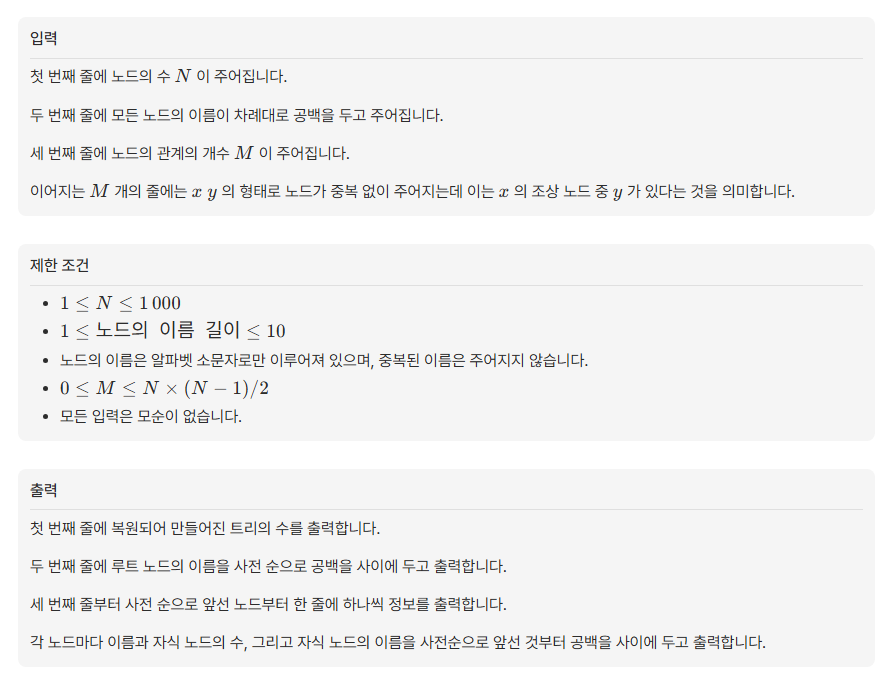

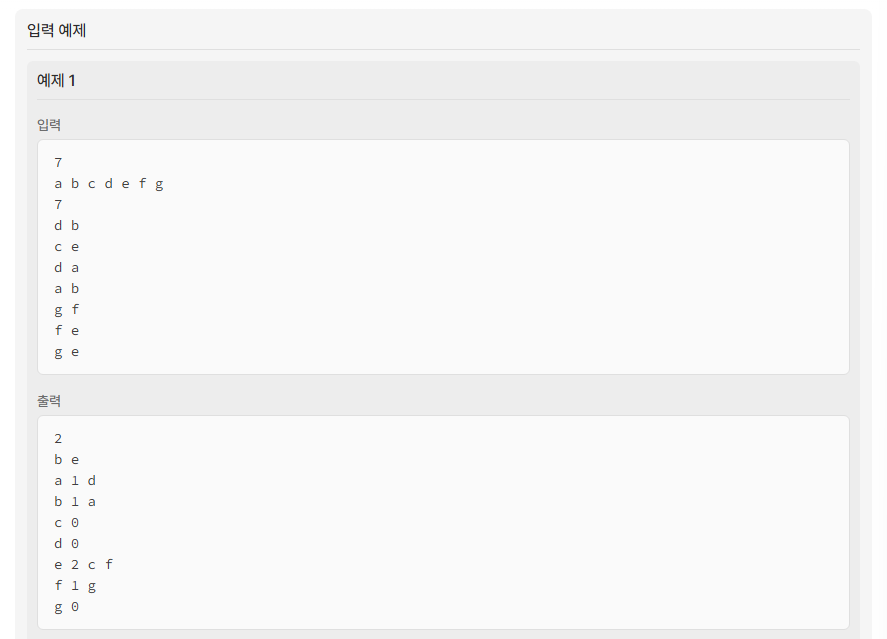

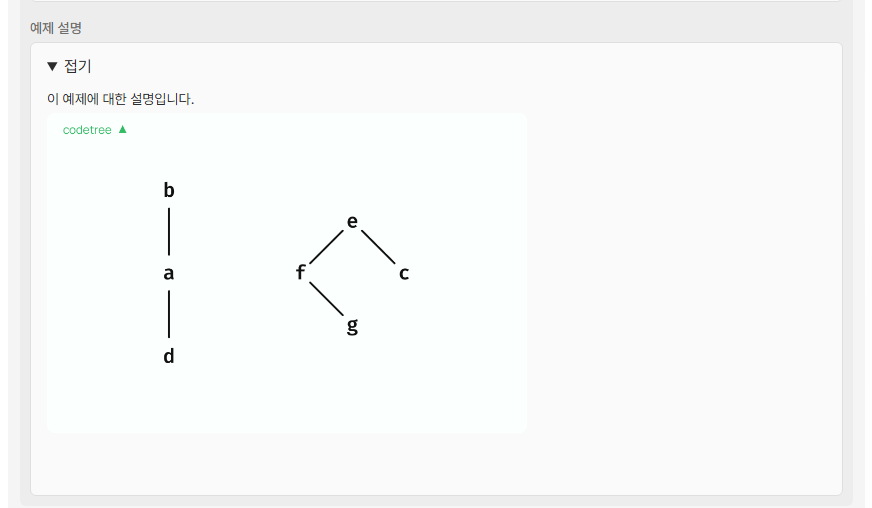

In [12]:
# 노드의 총개수 n을 입력받습니다.
n = int(input())

# 두 번째 줄에 주어지는 노드들의 이름을 리스트로 받고,
# 나중에 편하게 출력하기 위해 입력받자마자 알파벳(사전) 순으로 정렬합니다.
nodes = sorted(input().split())

# 문자열 이름표를 0번부터 n-1번까지의 '숫자 인덱스'로 바꿔줄 딕셔너리입니다.
string_to_node = {}
for i in range(n):
    string_to_node[nodes[i]] = i

# 조상에서 자손으로 향하는 화살표를 저장할 그래프입니다.
edges = [[] for _ in range(n)]

# 각 노드의 진짜 자식들을 저장할 리스트입니다.
children = [[] for _ in range(n)]

# 각 노드의 진입차수(나의 조상 개수)를 관리할 배열입니다.
indegree = [0] * n

# 관계의 개수 m을 입력받습니다.
m = int(input())

# m개의 줄에 걸쳐 (자손, 조상) 순서로 입력을 받습니다.
for _ in range(m):
    x_str, y_str = input().split()

    # 문자열 이름을 우리가 매겨둔 숫자 번호로 바꿉니다.
    x = string_to_node[x_str] # 자손
    y = string_to_node[y_str] # 조상

    # 조상(y)에서 자손(x)으로 방향 간선을 이어줍니다.
    edges[y].append(x)

    # 자손(x)의 입장에서는 내 위에 조상이 1명 추가된 것이므로 진입차수를 1 늘립니다.
    indegree[x] += 1

# 위상 정렬을 위한 큐(리스트)를 만듭니다.
queue = []

# 가장 꼭대기에 있는 트리들의 루트(뿌리) 노드를 모아둘 리스트입니다.
roots = []

# 0번부터 n-1번 노드까지 쭉 훑어보며 초기 큐를 세팅합니다.
for i in range(n):
    # 만약 진입차수가 0이라면? (내 위에 조상이 단 한 명도 없다면)
    if indegree[i] == 0:
        queue.append(i) # 당장 큐에 넣어줍니다.
        roots.append(i) # 이 노드는 트리의 루트(뿌리)입니다.

# 초고속 큐를 위한 머리(head) 인덱스입니다.
head = 0

# 큐에 노드가 남아있는 동안 위상 정렬을 계속 진행합니다.
while head < len(queue):
    # 큐에서 노드를 하나 꺼냅니다. (위에서부터 차례대로 내려오는 중입니다)
    x = queue[head]
    head += 1

    # 현재 노드(x)에서 갈 수 있는 모든 자손(y)들을 확인합니다.
    for y in edges[x]:
        # 자손의 진입차수를 1만큼 깎아줍니다. (조상 하나가 처리되었음)
        indegree[y] -= 1

        # [핵심 로직] 만약 진입차수를 깎았더니 비로소 0이 되었다면?
        # 지금 처리한 노드(x)가 바로 자손(y)의 '직속 부모'라는 뜻입니다!
        if indegree[y] == 0:
            queue.append(y)         # 다음 탐색을 위해 큐에 넣습니다.
            children[x].append(y)   # 진짜 자식 목록에 당당히 이름을 올립니다.

# 출력을 위해 각 노드의 자식들을 다시 한번 알파벳 순으로 정렬합니다.
# (처음에 노드 자체를 정렬했기 때문에 인덱스 번호를 정렬하면 자연스럽게 이름순이 됩니다)
for i in range(n):
    children[i].sort()

# 1. 루트 노드의 총개수를 먼저 출력합니다.
print(len(roots))

# 2. 루트 노드들의 이름을 공백으로 띄워 출력합니다.
for r in roots:
    print(nodes[r], end=" ")
print() # 줄바꿈

# 3. 0번부터 n-1번 노드까지 차례대로(이미 이름순으로 정렬됨) 자식 정보를 출력합니다.
for i in range(n):
    # 내 이름과 자식의 수를 출력합니다.
    print(nodes[i], len(children[i]), end=" ")

    # 내 자식들의 이름을 공백으로 띄워 쭉 출력합니다.
    for c in children[i]:
        print(nodes[c], end=" ")
    print() # 한 노드의 출력이 끝나면 줄을 바꿉니다.

7
a b c d e f g
7
d b
c e
d a
a b
g f
f e
g e
2
b e 
a 1 d 
b 1 a 
c 0 
d 0 
e 2 c f 
f 1 g 
g 0 


# 9일차

# 정수 분배하기

30XP

평균 20분

54% 정답률

총 제출 1,118회
___
N개의 정수를 분배하여 같은 크기의 정수 K를 M개 만들려고 할 때, 만들 수 있는 K값의 최댓값을 구하는 프로그램을 작성해보세요. 이때, M개를 만들어야 한다는 의미는 M개 이상을 얻어내면 된다는 뜻임에 유의합니다.

단, N개의 정수를 분배할 때는 제한 없이 정수를 분배해도 괜찮지만, 각 정수에서 분배하고 남은 정수들을 합쳐서 새로운 정수로 만들 수는 없습니다.

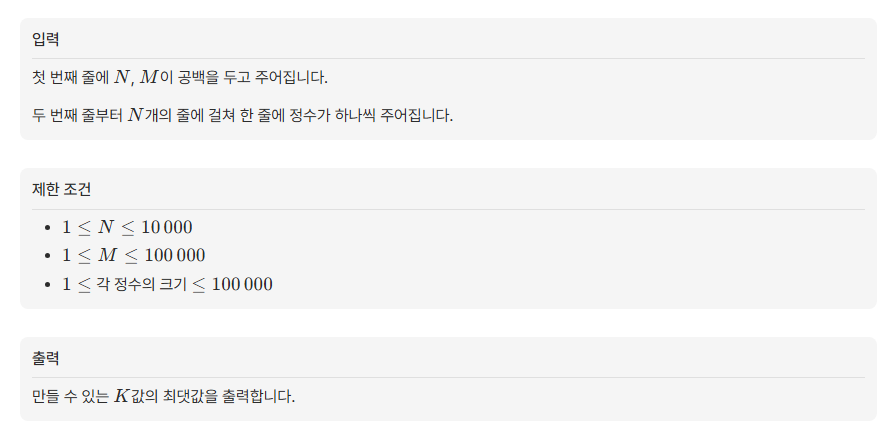

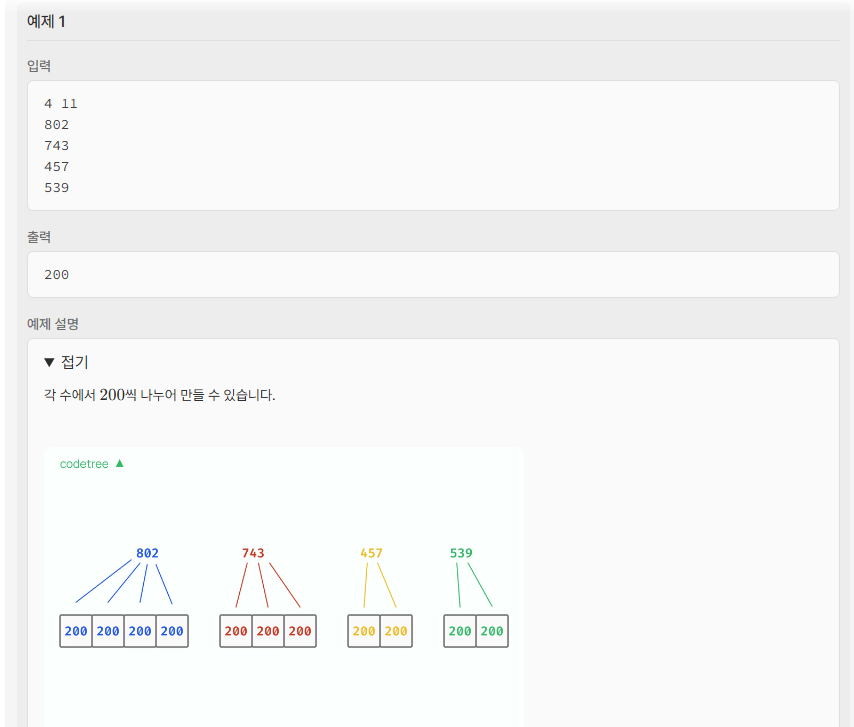

In [13]:
# 사용자로부터 주어지는 정수의 개수(N)와 만들어야 할 조각의 수(M)를 입력받습니다.
N, M = map(int, input().split())

# N개의 줄에 걸쳐 주어지는 정수들을 입력받아 리스트에 저장합니다.
# for문을 이용해 한 줄씩 숫자를 읽어옵니다.
numbers = []
for _ in range(N):
    numbers.append(int(input()))

# 이분 탐색을 위한 양 끝점(left, right)을 설정합니다.
# 조각의 최소 길이는 1이므로 left는 1로 시작합니다.
left = 1
# 만들 수 있는 최대 길이는 가지고 있는 정수 중 가장 큰 값입니다.
right = max(numbers)

# 우리가 찾고자 하는 정답(최대 길이 K)을 저장할 변수입니다.
best_k = 0

# left가 right를 역전하기 전까지 (탐색 범위가 남아있는 동안) 계속 반복합니다.
while left <= right:
    # 양 끝점의 딱 중간을 잘라볼 후보 길이(mid)로 정합니다.
    mid = (left + right) // 2

    # 이 중간 길이(mid)로 잘랐을 때 총 몇 조각이 나오는지 셀 카운터입니다.
    piece_count = 0

    # 우리가 가진 정수들을 하나씩 꺼내서 mid 길이로 잘라봅니다.
    for num in numbers:
        # 몫(//)을 구하면 해당 정수에서 mid 길이의 조각이 몇 개 나오는지 알 수 있습니다.
        # (남은 자투리는 버려지므로 정확히 문제 조건과 일치합니다)
        piece_count += (num // mid)

    # [조건 확인] 만약 만들어진 조각의 수(piece_count)가 목표치(M) 이상이라면?
    if piece_count >= M:
        # 일단 M개를 만드는 데 성공했으므로 현재의 길이(mid)를 정답으로 임시 저장합니다.
        best_k = mid

        # "이것보다 조금 더 길게 잘라도 M개가 나오지 않을까?" 하고 욕심을 내봅니다.
        # 더 긴 길이를 탐색하기 위해 left를 중간 지점 바로 오른쪽으로 끌어올립니다. (Up!)
        left = mid + 1

    # 만약 만들어진 조각의 수가 목표치(M)보다 부족하다면?
    else:
        # 조각이 부족하다는 것은 '너무 길게 잘랐다'는 뜻입니다.
        # 조각의 길이를 줄여서 개수를 늘려야 하므로 right를 중간 지점 바로 왼쪽으로 내립니다. (Down!)
        right = mid - 1

# 모든 탐색(업 앤 다운)이 끝난 후, 가장 마지막에 저장되었던 '최대 길이'를 출력합니다.
print(best_k)

4 11
802
743
457
539
200


# 이차원 배열의 오름차순 정리

60XP

평균 71분

59% 정답률

총 제출 576회
___
N×N 크기의 이차원 배열 A에 들어있는 수는 A[i][j]=i×j 입니다.

이 수들을 모두 오름차순으로 정렬하였을 때, K번째로 오는 수를 구하는 프로그램을 작성해보세요.

단, 배열 A의 인덱스는 1부터 시작합니다.

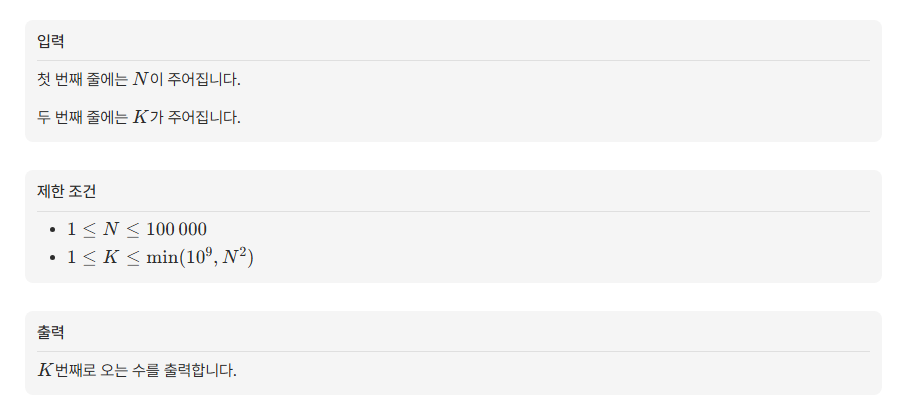

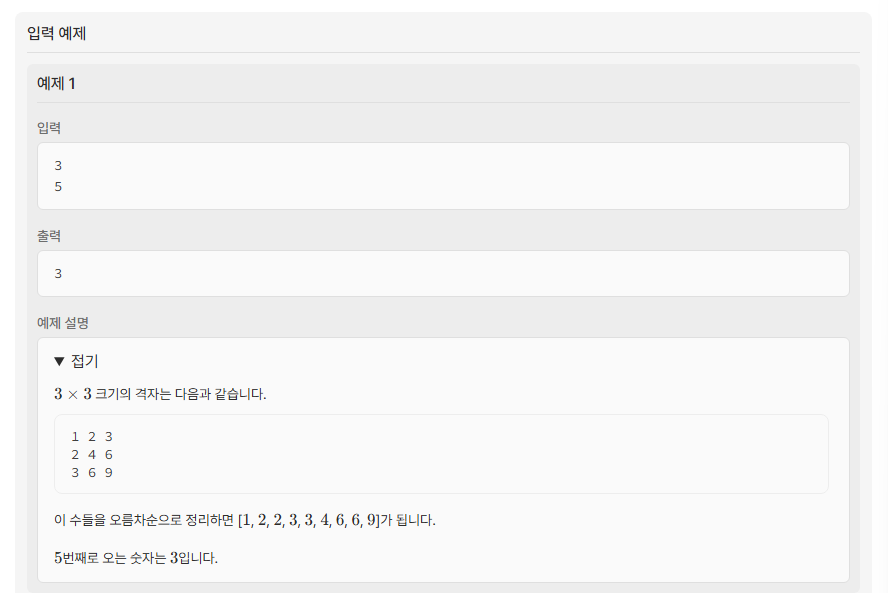

In [14]:
# 사용자로부터 배열의 크기 N을 입력받습니다.
N = int(input())

# 우리가 찾고 싶은 순서인 K를 입력받습니다.
K = int(input())

# 이분 탐색을 위한 양 끝점을 설정합니다.
# 2차원 배열에서 나올 수 있는 가장 작은 수는 1 (1x1) 입니다.
left = 1
# 가장 큰 수는 N x N 입니다.
right = N * N

# 최종 정답(K번째 수)을 저장할 변수입니다.
answer = 0

# left가 right를 역전하기 전까지 (탐색 범위가 남아있는 동안) 계속 반복합니다.
while left <= right:
    # 양 끝점의 딱 중간을 'K번째 숫자의 후보(mid)'로 찍어봅니다.
    mid = (left + right) // 2

    # 2차원 배열 전체에서 이 후보(mid)보다 작거나 같은 숫자가 몇 개인지 셀 카운터입니다.
    count = 0

    # 1행(1단)부터 N행(N단)까지 각 행을 차례대로 확인합니다.
    for i in range(1, N + 1):
        # i번째 행에서 mid보다 작거나 같은 수의 개수는 (mid // i) 입니다.
        # 단, 한 행에는 숫자가 N개까지만 있으므로 N을 초과할 수 없게 min()을 씌워줍니다.
        count += min(mid // i, N)

    # [조건 확인] 만약 mid보다 작거나 같은 숫자의 총개수(count)가 K 이상이라면?
    if count >= K:
        # 우리가 찾는 K번째 숫자는 최소한 mid 이하라는 뜻입니다!
        # 일단 정답으로 임시 저장해 둡니다.
        answer = mid

        # 더 작은 숫자 중에서도 조건을 만족하는 K번째 수가 있는지 확인하기 위해,
        # 탐색 범위를 왼쪽(작은 쪽)으로 좁힙니다. (Down!)
        right = mid - 1

    # 만약 작거나 같은 숫자의 개수가 K보다 부족하다면?
    else:
        # mid를 너무 작게 찍었다는 뜻이므로,
        # 더 큰 숫자를 찾기 위해 탐색 범위를 오른쪽(큰 쪽)으로 올립니다. (Up!)
        left = mid + 1

# 이분 탐색이 모두 끝나고 가장 정교하게 좁혀진 최종 정답을 출력합니다.
print(answer)

3
5
3


# 10일차

# 동전 더하기

20XP

평균 10분

85% 정답률

총 제출 1,225회
___
서로 다른 동전 N 종류로 금액 K 를 완성시키기 위해 필요한 동전 개수의 최솟값을 구하는 프로그램을 작성하세요.

단, 2번째부터 주어지는 동전의 가치값은 항상 바로 전 동전의 가치의 배수로 주어짐에 유의합니다.

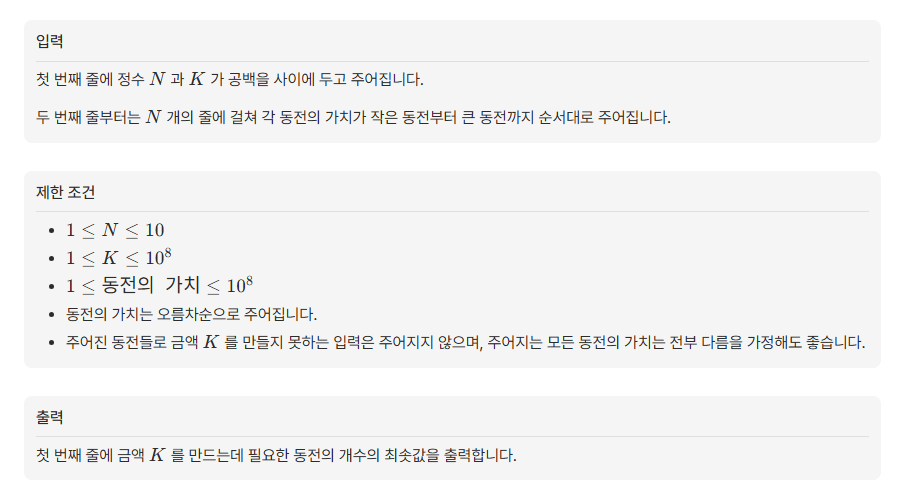

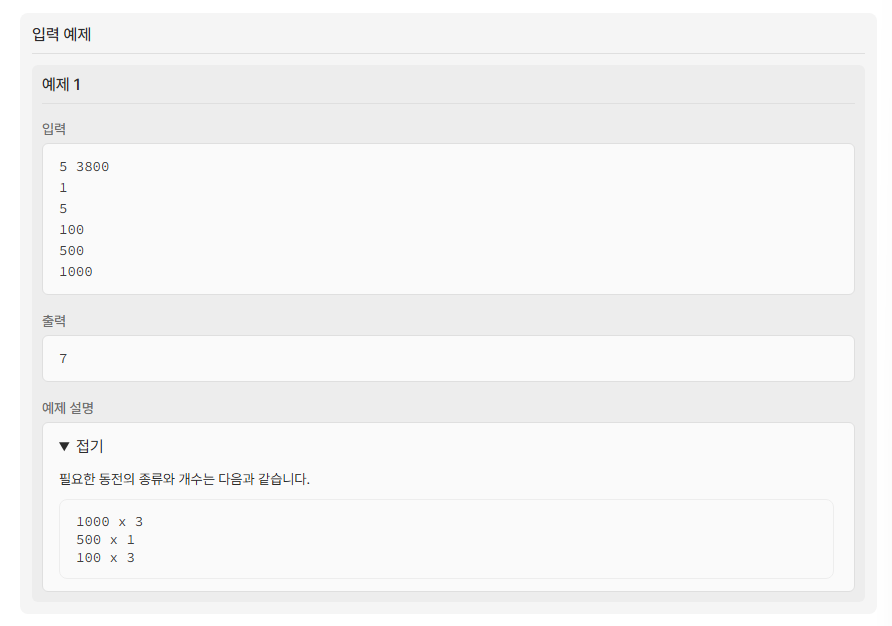

In [15]:
# 사용자로부터 동전 종류의 개수 N과 만들어야 할 목표 금액 K를 입력받습니다.
N, K = map(int, input().split())

# N개의 동전 가치를 저장할 빈 리스트를 만듭니다.
coins = []

# N번 반복하며 동전의 가치를 하나씩 입력받아 리스트에 추가합니다.
for _ in range(N):
    coins.append(int(input()))

# [핵심] 동전 개수를 최소화하려면 '가장 큰 동전'부터 사용해야 합니다.
# 현재 오름차순으로 정렬되어 있으므로, 내림차순(큰 순서대로)으로 뒤집어 줍니다.
coins.reverse()

# 사용한 동전의 총 개수를 저장할 카운터 변수입니다.
coin_count = 0

# 가장 큰 동전부터 차례대로 하나씩 꺼내어 확인합니다.
for coin in coins:
    # 현재 동전의 가치가 남은 금액 K보다 작거나 같다면 거슬러 줄 수 있습니다.
    if K >= coin:
        # 이 동전으로 거슬러 줄 수 있는 최대 개수(몫)를 구하여 카운터에 더합니다.
        coin_count += K // coin

        # 이 동전들을 사용하고 '남은 나머지 금액'으로 K를 새롭게 업데이트합니다.
        K %= coin

    # 만약 남은 금액이 0원이 되었다면?
    if K == 0:
        # 더 이상 다른 동전을 확인할 필요가 없으므로 반복문을 즉시 종료(탈출)합니다.
        break

# 최종적으로 계산된 최소 동전 개수를 출력합니다.
print(coin_count)

5 3800
1
5
100
500
1000
7


# 연속 부분 합의 최댓값 구하기 2

20XP

평균 12분

46% 정답률

총 제출 1,585회
___
N개의 정수가 입력으로 주어지고, 이 중 연속한 부분 수열에 속한 원소들의 합이 최대가 될 때의 값을 출력하는 코드를 작성해보세요. (단, 부분 수열은 최소 한 개 이상의 원소를 포함합니다.)

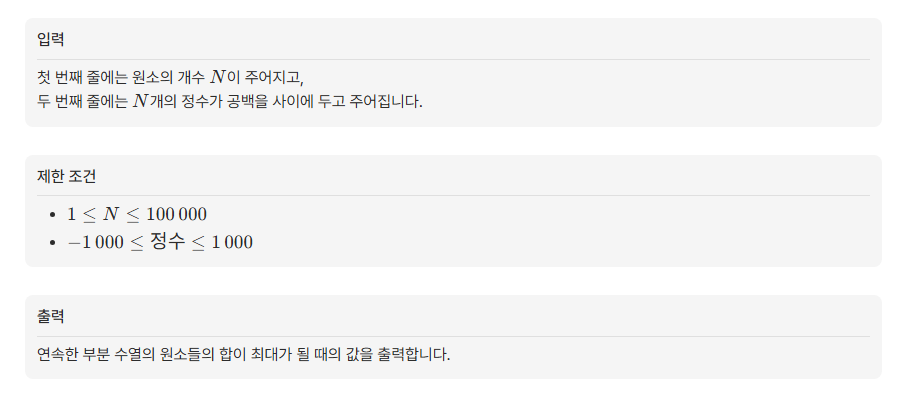

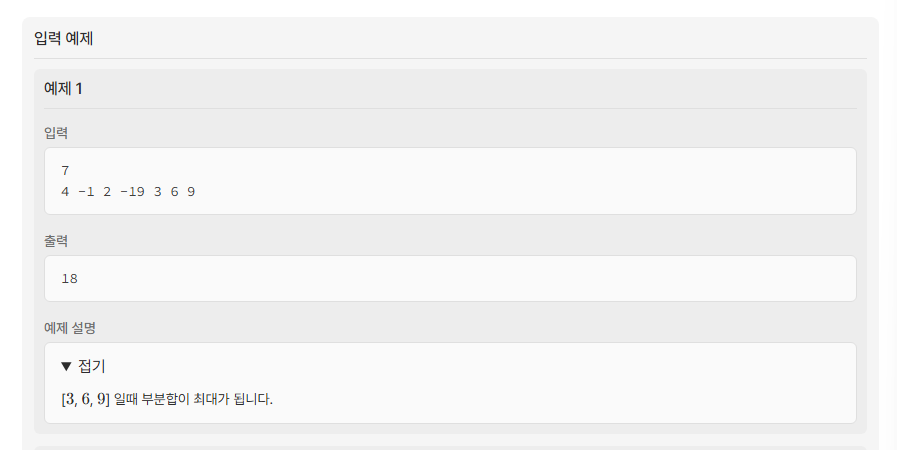

In [16]:
# 사용자로부터 배열의 크기 N을 입력받습니다.
N = int(input())

# N개의 정수가 담긴 배열을 입력받습니다.
arr = list(map(int, input().split()))

# 첫 번째 숫자로 초기값을 세팅합니다.
# current_sum: 현재 위치까지의 연속 부분 합
# max_sum: 지금까지 발견한 역대 최대 부분 합
current_sum = arr[0]
max_sum = arr[0]

# 두 번째 숫자(인덱스 1)부터 마지막 숫자까지 차례대로 하나씩 확인합니다.
for i in range(1, N):
    # [핵심 로직] "과거의 합에 나를 더할 것인가?" vs "과거를 버리고 나부터 새로 시작할 것인가?"
    # arr[i] (나 혼자 새 출발) 와 current_sum + arr[i] (과거에 나를 이어붙임) 중 더 큰 것을 고릅니다.
    current_sum = max(arr[i], current_sum + arr[i])

    # 방금 결정한 현재의 연속 합이, 역대 최고 기록(max_sum)보다 크다면 갱신합니다!
    if current_sum > max_sum:
        max_sum = current_sum

# 배열을 끝까지 모두 확인한 후, 역대 최대 합을 출력합니다.
print(max_sum)

7
4 -1 2 -19 3 6 9
18


# 쪼개어 배낭 채우기 구현

30XP

평균 27분

61% 정답률

총 제출 1,033회
___
도둑이 보석방을 털러 갔습니다. 보석방에는 N개의 보석이 있고, 도둑 가방의 크기는 M이기 때문에 이보다 더 많은 양의 무게에 해당하는 보석들을 담아 나올 수는 없습니다. 또한, 보석은 종류별로 단 하나씩만 있으며 각 보석을 원하는 만큼 쪼개어 담는 것이 가능합니다.

예를 들어 도둑방에 보석이 다음과 같이 5개가 있는 경우를 살펴봅시다. 이때 도둑 가방의 크기는 8이라 가정합니다.


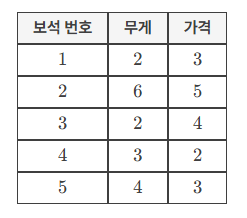

이 예시에서는 1번 보석과 3번 보석을 담고, 2번 보석의  
3
2
​
  만큼 담으면 무게는 정확히 8이 되며 이때 가치는 10.333이 됩니다. 이 예시에서 이보다 더 크게 가치를 만들 수는 없습니다.

도둑 가방 크기의 정보와 보석의 정보가 주어졌을 때, 얻을 수 있는 최대 가치를 구하는 프로그램을 작성해보세요.

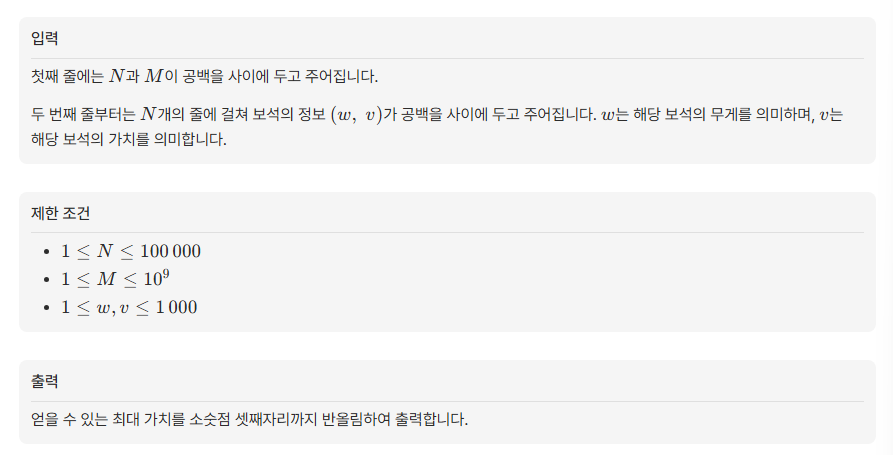

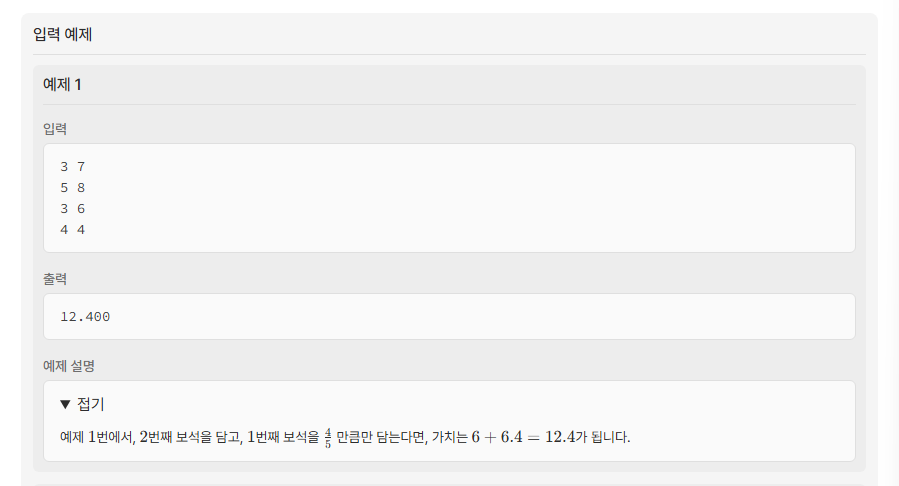

In [17]:
# 보석의 개수 N과 도둑의 배낭 크기 M을 입력받습니다.
N, M = map(int, input().split())

# 보석들의 정보를 담을 리스트입니다.
jewels = []

# N개의 보석 정보를 입력받습니다.
for _ in range(N):
    # w: 보석의 무게, v: 보석의 가치
    w, v = map(int, input().split())

    # 1kg당 가치(가성비)를 계산합니다.
    unit_price = v / w

    # (무게, 가치, 가성비) 3가지 정보를 튜플로 묶어서 리스트에 저장합니다.
    jewels.append((w, v, unit_price))

# [핵심] 가성비(unit_price)가 높은 순서대로 보석을 내림차순 정렬합니다.
# 람다 함수를 써서 튜플의 3번째 원소(인덱스 2)인 가성비를 기준으로 정렬하라고 지시합니다.
jewels.sort(key=lambda x: x[2], reverse=True)

# 훔친 보석의 총 가치를 저장할 변수입니다. 소수점이 나올 수 있으므로 0.0으로 시작합니다.
total_value = 0.0

# 가성비가 가장 높은 보석부터 하나씩 꺼내어 배낭에 담습니다.
for w, v, unit_price in jewels:
    # 만약 배낭의 남은 공간(M)이 현재 보석의 무게(w)를 통째로 담을 수 있다면?
    if M >= w:
        # 배낭 공간을 보석 무게만큼 줄이고
        M -= w
        # 총 가치에 보석의 가치를 통째로 더해줍니다.
        total_value += v

    # 만약 배낭의 공간이 부족해서 통째로 담을 수 없다면? (보석을 쪼개야 할 시간!)
    else:
        # 남은 배낭 공간(M)만큼만 보석을 쪼개어 담습니다.
        # (남은 공간) * (1kg당 가성비)를 계산하여 더해줍니다.
        total_value += M * unit_price

        # 배낭이 꽉 찼으므로 더 이상 남은 공간은 없습니다.
        M = 0
        # 배낭이 꽉 찼으니 미련 없이 도망갑니다. (반복문 종료)
        break

# 최종적으로 얻은 총 가치를 출력합니다.
# 문제 예시(10.333)처럼 소수점 셋째 자리까지 반올림하여 출력하는 것이 보통 코테의 표준입니다.
print(f"{total_value:.3f}")

3 7
5 8
3 6
4 4
12.400


# 수 합치기

40XP

평균 14분

56% 정답률

총 제출 916회
___
N개의 수가 주어졌을 때, 2개의 수를 골라 하나의 수로 합치는 과정을 단 하나의 수가 남을 때까지 반복하려고 합니다. 이때 2개의 수가 a, b였다면, 이 두 수를 합치는 데 드는 비용은 a+b 입니다. N개의 수를 잘 합쳐 하나의 수가 되기까지의 가능한 최소 비용을 구하는 프로그램을 작성해보세요.

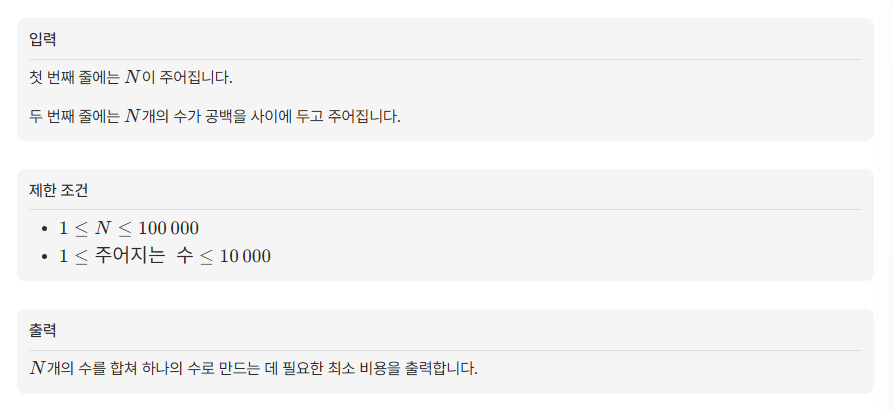

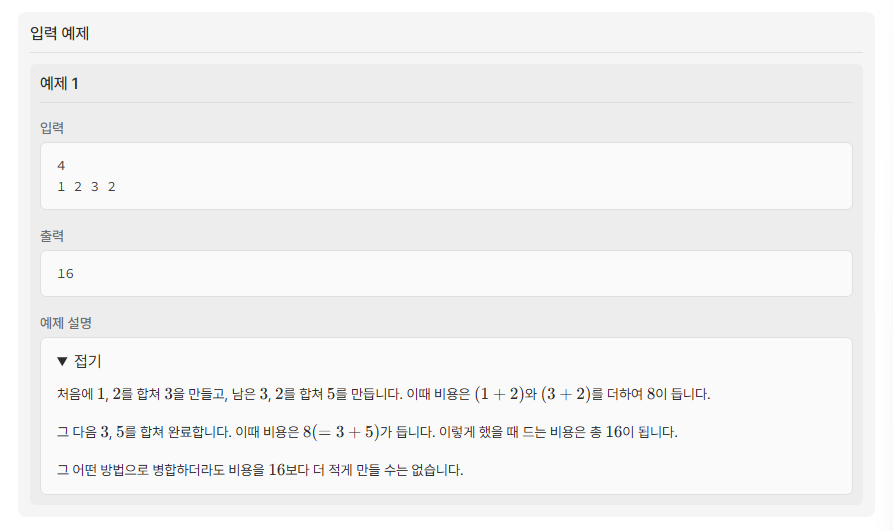

In [18]:
# 파이썬에 내장된 최소 힙(우선순위 큐) 모듈을 불러옵니다.
import heapq

# 사용자로부터 숫자의 개수 N을 입력받습니다.
n = int(input())

# 합쳐야 할 N개의 숫자들을 공백을 기준으로 입력받아 리스트로 만듭니다.
numbers = list(map(int, input().split()))

# [핵심] 일반 리스트를 우선순위 큐(최소 힙)로 변환합니다.
# 이렇게 하면 리스트가 '알아서 가장 작은 값을 맨 앞으로 유지하는' 상태가 됩니다.
heapq.heapify(numbers)

# 누적된 전체 합치기 비용을 저장할 변수입니다.
total_cost = 0

# 큐 안에 숫자가 1개만 남을 때까지 (합치기가 끝날 때까지) 계속 반복합니다.
while len(numbers) > 1:
    # 1. 큐에서 '가장 작은 숫자'를 하나 꺼냅니다.
    first = heapq.heappop(numbers)

    # 2. 큐에서 '두 번째로 작은 숫자'를 하나 꺼냅니다.
    second = heapq.heappop(numbers)

    # 두 숫자를 합치는 데 드는 비용을 계산합니다.
    current_cost = first + second

    # 전체 누적 비용에 이번 병합 비용을 더해줍니다.
    total_cost += current_cost

    # 3. [중요] 두 숫자가 합쳐져서 만들어진 '새로운 숫자'를 다시 큐에 집어넣습니다!
    # (heapq가 알아서 다시 정렬하여 제일 작은 값을 맨 앞으로 보내줍니다)
    heapq.heappush(numbers, current_cost)

# 모든 병합이 끝나고, 숫자가 1개 남았을 때 누적된 최소 비용을 출력합니다.
print(total_cost)

4
1 2 3 2
16


# 회의실 준비 구현

20XP

평균 10분

79% 정답률

총 제출 816회
___
하나의 회의실이 있고, N개의 회의 요청이 들어왔습니다. 각 회의의 시작 시간과 끝 시간이 주어져 있으며, 한 회의가 시작되면 도중에 그만둘 수 없고, 한 회의가 끝나는 직후에 동시에 다른 회의가 시작될 수 있습니다. 적절하게 회의 요청을 수락하여 최대로 많은 회의가 진행되도록 하는 프로그램을 작성하세요.

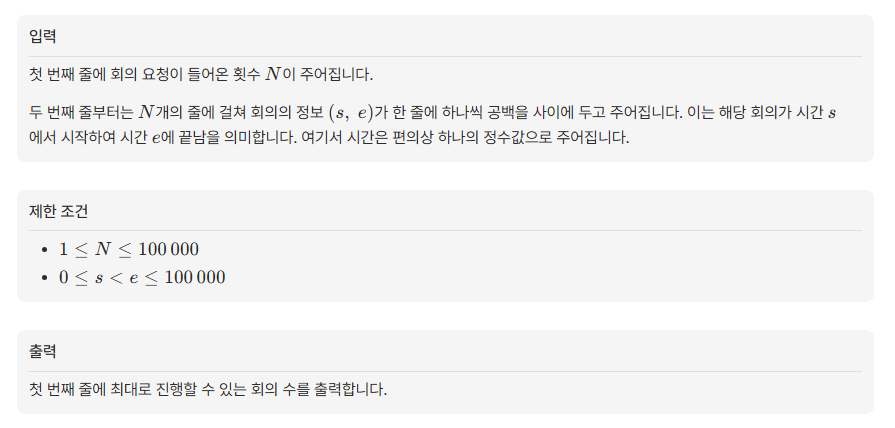

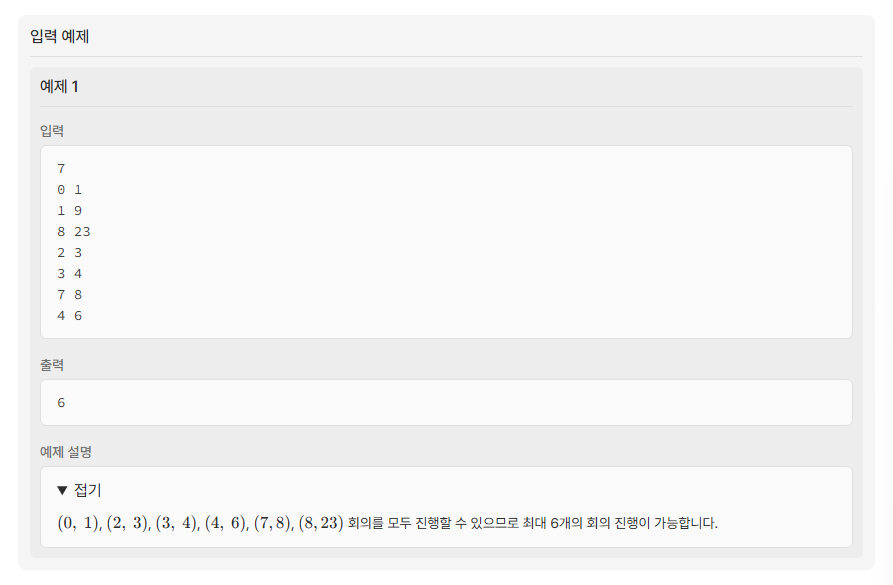

In [19]:
# 사용자로부터 회의의 총개수 N을 입력받습니다.
N = int(input())

# 회의들의 시작 시간과 끝 시간을 묶어서 담을 리스트입니다.
meetings = []

# N번 반복하며 각 회의의 시작 시간(s)과 끝 시간(e)을 입력받습니다.
for _ in range(N):
    s, e = map(int, input().split())
    # 튜플 형태로 (시작 시간, 끝 시간)을 리스트에 추가합니다.
    meetings.append((s, e))

# [핵심] 회의를 정렬합니다.
# 1순위: 끝나는 시간 (x[1]) 기준 오름차순 (가장 일찍 끝나는 것부터)
# 2순위: 끝나는 시간이 같다면 시작 시간 (x[0]) 기준 오름차순
meetings.sort(key=lambda x: (x[1], x[0]))

# 진행할 수 있는 최대 회의의 개수를 세는 카운터입니다.
count = 0

# 직전에 진행된 회의가 '끝난 시간'을 기억할 변수입니다.
# 처음에는 회의가 없으므로 -1이나 0으로 설정합니다.
last_end_time = -1

# 정렬된 회의들을 처음부터 끝까지 하나씩 확인합니다.
for start, end in meetings:
    # 만약 현재 확인 중인 회의의 '시작 시간'이
    # 직전 회의가 '끝난 시간'과 같거나 그 이후라면? (즉, 겹치지 않는다면)
    if start >= last_end_time:
        count += 1              # 회의를 진행 목록에 추가합니다.
        last_end_time = end     # 이제 회의실은 이 회의가 '끝나는 시간'까지 사용됩니다.

# 최종적으로 진행 가능한 최대 회의의 개수를 출력합니다.
print(count)

7
0 1
1 9
8 23
2 3
3 4
7 8
4 6
6


# 실전연습 [1]

# 도미노 정렬하기

평균 180분

44% 정답률

총 제출 200회
___
코디는 1부터 N까지 크기가 서로 다른 도미노 블록 N개를 갖고 있습니다.

블록 크기가 오름차순이 되도록 도미노를 쌓은 코디가 잠시 자리를 비운 사이 누군가 도미노의 순서를 섞어버렸습니다.

당신은 코디가 돌아오기 전에 블록을 원래의 배열 상태인 오름차순으로 돌려놓고자 합니다. 도미노 블록의 순서는 다음 방법으로만 바꿀 수 있습니다.

블록을 하나 선택해 해당 블록을 도미노의 가장 앞 또는 가장 뒤로 이동시킨다.
코디가 언제 돌아올지 모르기 때문에 최대한 빠르게 도미노를 원상복구 시켜야 합니다. 뒤섞인 도미노의 배열 상태가 주어졌을 때, 블록의 크기가 오름차순이 되도록하는 최소 이동 횟수를 출력하는 프로그램을 작성하세요.

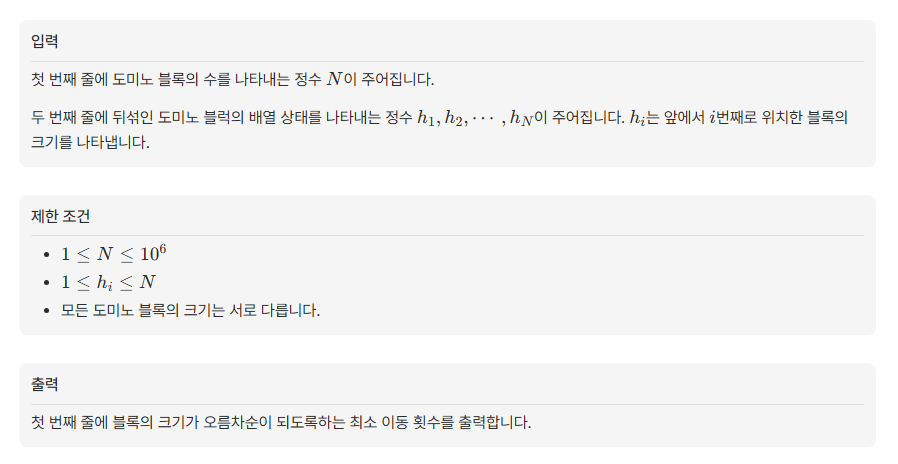

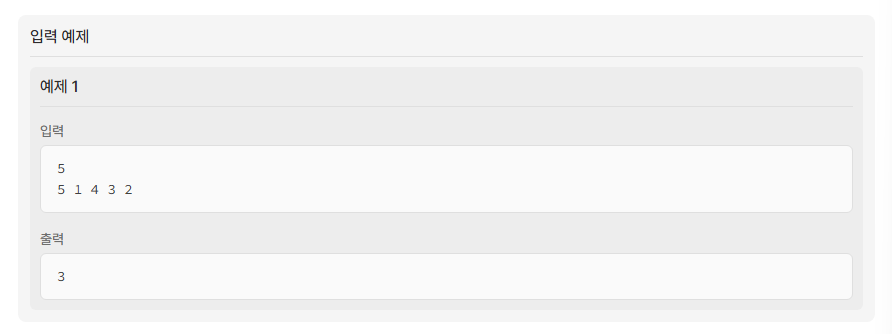

In [20]:
# 사용자로부터 도미노의 개수 N을 입력받습니다.
N = int(input())

# 뒤섞인 도미노의 현재 배열 상태를 입력받습니다.
dominos = list(map(int, input().split()))

# dp[x]는 '숫자 x로 끝나는 연속 증가 수열의 최대 길이'를 저장하는 기록장입니다.
# 도미노 숫자가 1부터 N까지이므로, 여유롭게 N + 1 크기로 만듭니다.
# 처음에는 모두 길이가 0이라고 초기화합니다.
dp = [0] * (N + 1)

# 가만히 놔둘 수 있는 '가장 긴 연속 수열'의 길이를 저장할 변수입니다.
max_len = 0

# 도미노 배열을 왼쪽부터 하나씩 확인합니다.
for num in dominos:
    # [핵심] 현재 숫자(num)의 수열 길이는,
    # 내 바로 앞 숫자(num - 1)까지 이어져 온 수열 길이에 나 자신(+1)을 덧붙인 것입니다.
    dp[num] = dp[num - 1] + 1

    # 방금 구한 길이가 역대급으로 긴 길이라면 갱신해 줍니다.
    if dp[num] > max_len:
        max_len = dp[num]

# 최소 이동 횟수는 (전체 도미노 개수) - (가만히 놔둘 가장 긴 수열의 길이) 입니다.
print(N - max_len)

5
5 1 4 3 2
3


# 공정한 팀 나누기

평균 72분

71% 정답률

총 제출 91회
___
체육 시간에 N명의 학생을 두 팀으로 나누어 경기를 하려고 합니다. N명의 학생에게는 1번부터 N번까지의 고유한 번호가 부여되어 있습니다.

같은 팀이 된 학생들 사이에는 팀워크가 발생합니다. i번 학생이 j번 학생과 같은 팀이 되었을 때 발생하는 팀워크는 W
i,j
​
 입니다. 팀워크는 방향에 따라 다를 수 있으며, W
i,j
​
 와 W
j,i
​
 가 서로 다를 수 있습니다.

각 팀의 전력은 해당 팀에 속한 모든 학생 쌍 (i,j) (i

=j)에서 발생하는 팀워크 W
i,j
​
 의 합입니다.

두 팀의 인원이 꼭 같을 필요는 없지만, 공정한 경기를 위해 각 팀에는 최소 K명 이상의 학생이 있어야 합니다.

두 팀의 전력 차이의 절댓값이 최소가 되도록 팀을 나누었을 때, 그 최솟값을 구해 주세요.

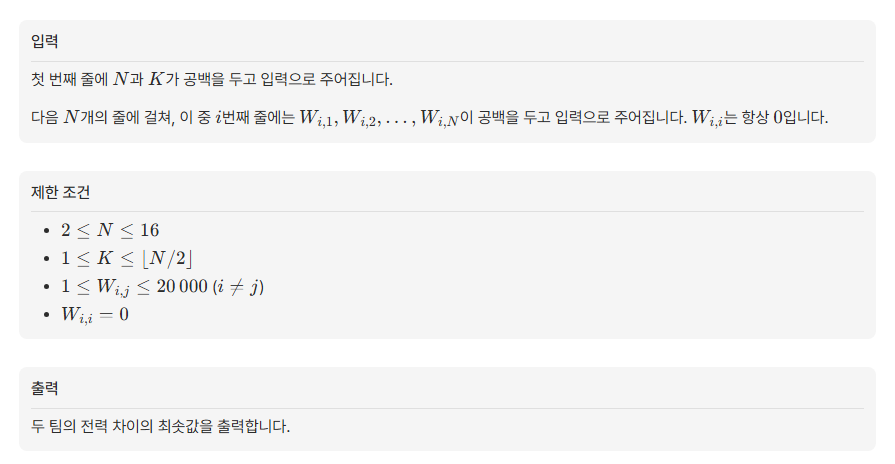

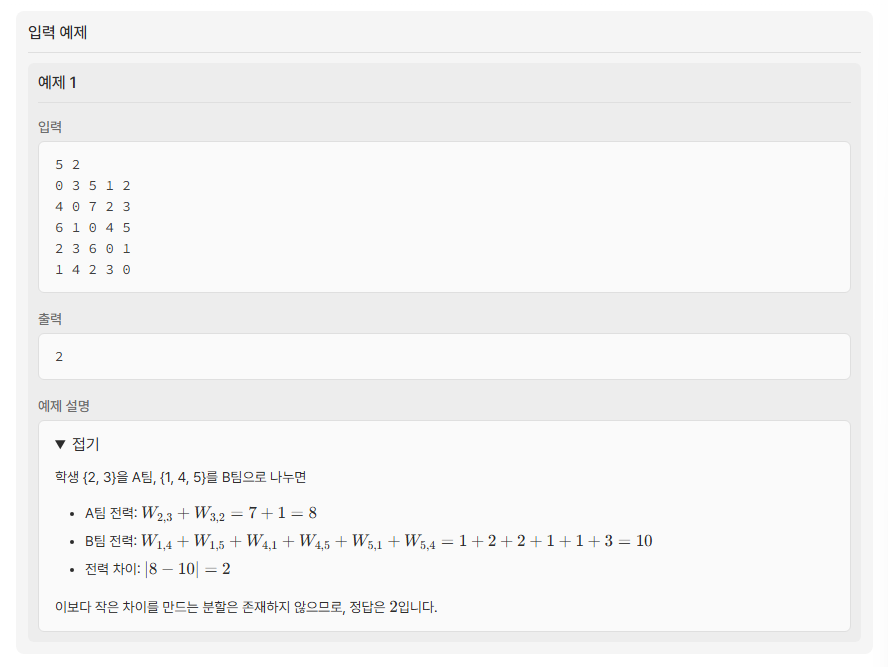

In [21]:
import itertools

# 전체 학생 수 N과 한 팀의 최소 인원 K를 입력받습니다.
N, K = map(int, input().split())

# N x N 크기의 팀워크(시너지) 정보를 입력받습니다.
W = [list(map(int, input().split())) for _ in range(N)]

# 1. 각 학생별 '개인 기여도 총합(R)'을 저장할 배열을 만듭니다.
R = [0] * N

# 2. 모든 학생에 대해 다른 사람들과의 시너지를 전부 더해줍니다.
for i in range(N):
    for j in range(N):
        if i != j:
            # i가 j에게 주는 시너지와 j가 i에게 주는 시너지를 모두 더합니다.
            R[i] += W[i][j] + W[j][i]

# 전체 학생의 기여도 총합을 미리 구해둡니다. (나중에 B팀의 합을 쉽게 구하기 위함)
total_R = sum(R)

# 전력 차이의 최솟값을 저장할 변수입니다. 무한대 값으로 시작합니다.
min_diff = float('inf')

# 3. A팀의 인원수(size_A)를 K명부터 확인합니다.
# B팀도 최소 K명이어야 하므로 N-K명까지만 늘어날 수 있으며,
# 절반(N//2)을 넘어가면 B팀을 뽑는 것과 똑같은 대칭(중복)이 되므로 범위를 좁힙니다.
max_size = min(N - K, N // 2)

for size_A in range(K, max_size + 1):
    # R 배열에서 size_A 명을 뽑는 모든 경우의 수(조합)를 탐색합니다.
    for team_A_R in itertools.combinations(R, size_A):

        # 뽑힌 A팀 사람들의 총 기여도 합을 구합니다.
        sum_A = sum(team_A_R)

        # B팀 사람들의 총 기여도 합은 (전체 기여도 합 - A팀 기여도 합) 입니다.
        sum_B = total_R - sum_A

        # 두 팀의 총 기여도 합의 차이를 구합니다.
        diff = abs(sum_A - sum_B)

        # 역대 최소 차이보다 작다면 정답을 갱신합니다.
        if diff < min_diff:
            min_diff = diff

            # 만약 차이가 0이라면 이보다 더 완벽할 수 없으므로 즉시 탐색을 끝냅니다.
            if min_diff == 0:
                break

    if min_diff == 0:
        break

# 4. [핵심] 구한 총 기여도 차이를 2로 나누면, 완벽하게 '실제 팀 전력 차이'가 됩니다!
print(min_diff // 2)

5 2
0 3 5 1 2
4 0 7 2 3
6 1 0 4 5
2 3 6 0 1
1 4 2 3 0
2


# 실전연습 [2]

# 가깝게 만들기

평균 55분

78% 정답률

총 제출 51회
___
칠판에 N개의 수들이 써 있습니다. 왼쪽에서 i번째 수는 A
i
​
 입니다.

코디는 각 수들의 사이에 적당히 +, −, × 중 하나의 연산 기호를 써넣은 후, 연산자의 종류와 상관없이 왼쪽부터 오른쪽 순서로 계산했을 때 결과를 기록합니다.

예를 들어, 다음과 같이 수들이 써 있고,

Image
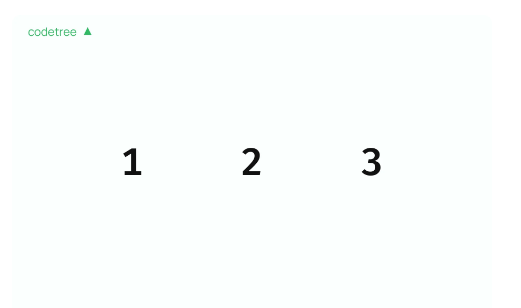

다음과 같이 기호를 써넣는다면

Image
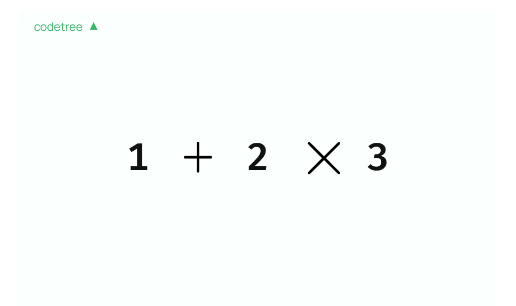

수식의 계산 결과는 9이 됩니다.

코디는 정수 K를 좋아하기 때문에, 계산 결과가 최대한 K에 가깝도록 하고 싶습니다. 수들 사이에 적절히 연산 기호를 적어 넣어 연산 결과를 K에 최대한 가깝게 할 때, 차이의 최솟값이 얼마인지 계산하는 프로그램을 작성하세요.

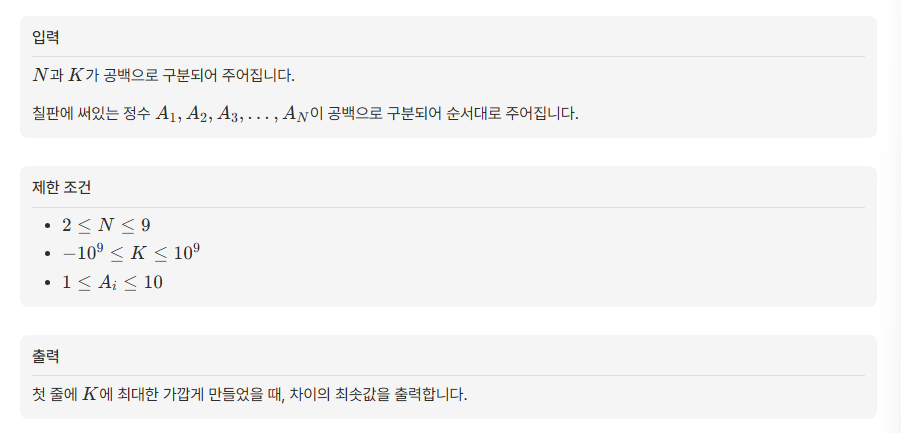

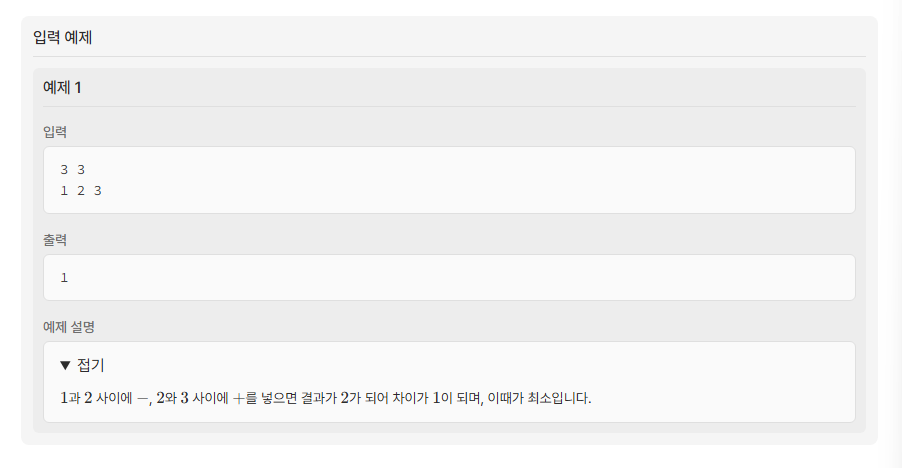

In [22]:
# 사용자로부터 숫자의 개수 N과 목표값 K를 입력받습니다.
N, K = map(int, input().split())

# 칠판에 적힌 N개의 숫자들을 리스트로 입력받습니다.
A = list(map(int, input().split()))

# 목표값 K와의 최소 차이를 저장할 변수입니다.
# 처음에는 무한대(10억)로 설정해둡니다.
min_diff = int(1e9)

# DFS 탐색 함수를 정의합니다.
# index: 다음으로 연산할 숫자의 위치, current_val: 지금까지 계산된 누적 결과값
def dfs(index, current_val):
    global min_diff

    # [종료 조건] 만약 모든 숫자(N개)를 다 연산했다면?
    if index == N:
        # 최종 계산된 결과와 목표값 K의 차이(절대값)를 구합니다.
        diff = abs(current_val - K)

        # 그 차이가 역대급으로 작다면 최소 차이를 갱신합니다!
        if diff < min_diff:
            min_diff = diff

        # 이번 탐색 경로는 끝났으므로 이전 갈림길로 돌아갑니다.
        return

    # [탐색 진행] 아직 연산할 숫자가 남았다면 3가지 갈림길로 뻗어나갑니다.
    # 1. 더하기 (+)
    dfs(index + 1, current_val + A[index])

    # 2. 빼기 (-)
    dfs(index + 1, current_val - A[index])

    # 3. 곱하기 (*)
    dfs(index + 1, current_val * A[index])

# 첫 번째 숫자(A[0])를 들고, 두 번째 숫자(인덱스 1)부터 연산을 시작합니다!
dfs(1, A[0])

# 모든 경우의 수를 탐색한 후, 찾은 최소 차이를 출력합니다.
print(min_diff)

3 3
1 2 3
1


# 등산로 공사

평균 180분

31% 정답률

총 제출 246회
___
N×N 크기의 부지에 최대한 긴 등산로를 만들려고 합니다.

부지의 각 칸에는 지형의 높이가 정수로 표시되어 있습니다.

등산로를 만드는 규칙은 다음과 같습니다.

등산로는 가장 높은 봉우리에서 시작해야 합니다.
등산로는 높은 지형에서 낮은 지형으로 가로 또는 세로 방향으로만 연결되어야 합니다. 즉, 다음 칸의 높이는 현재 칸의 높이보다 반드시 낮아야 하며, 대각선 방향의 이동은 불가능합니다.
긴 등산로를 만들기 위해 여러 칸의 지형을 깎는 공사를 할 수 있습니다. 이때 깎는 양의 총합이 K 이하여야 합니다. 깎은 칸의 높이는 깎은 양만큼 줄어듭니다.
1 이상의 정수 칸 만큼만 깎을 수 있습니다.
지형을 깎아 높이를 1 미만으로 만들 수는 없습니다.
지형을 깎을 때, 가장 높은 봉우리는 깎을 수 없습니다. 가장 높은 봉우리가 여러 개인 경우, 모두 깎을 수 없습니다.
이때 만들 수 있는 가장 긴 등산로의 길이를 구합니다. 등산로의 길이는 등산로를 구성하는 칸의 수입니다.

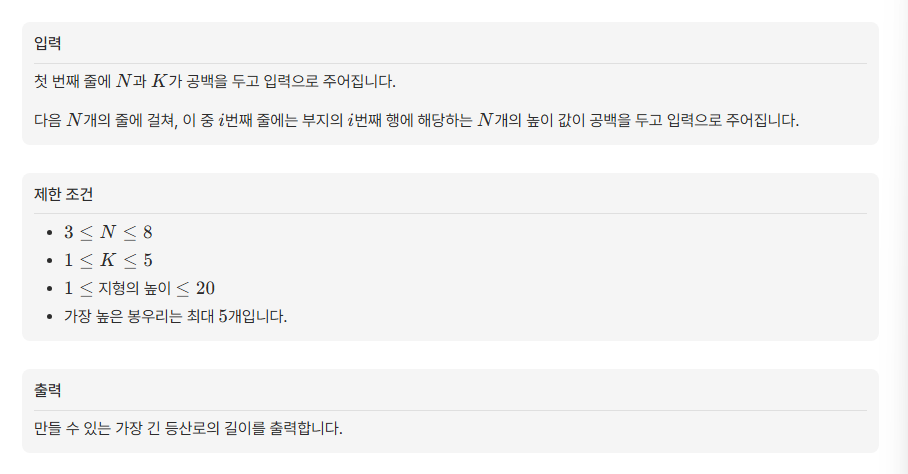

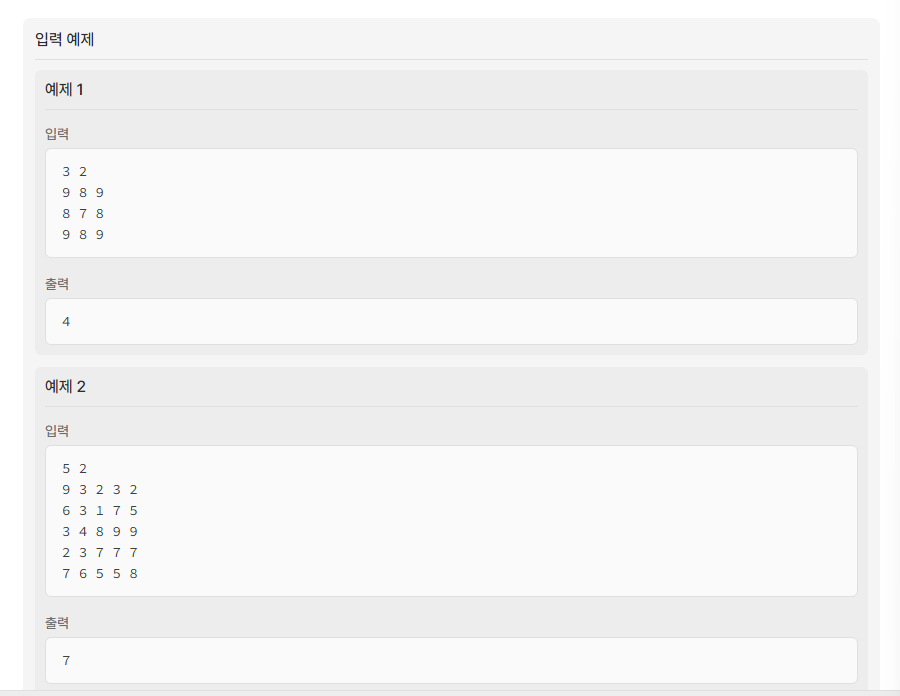

In [24]:
# 사용자로부터 지도의 크기 N과 깎을 수 있는 총량 K를 입력받습니다.
N, K = map(int, input().split())

# N x N 지도의 높이 정보를 입력받습니다.
grid = [list(map(int, input().split())) for _ in range(N)]

# 1. 지도에서 '가장 높은 봉우리'의 높이를 찾습니다.
max_height = 0
for r in range(N):
    for c in range(N):
        if grid[r][c] > max_height:
            max_height = grid[r][c]

# 2. 최고 높이를 가진 모든 출발점의 좌표를 리스트에 담습니다.
peaks = []
for r in range(N):
    for c in range(N):
        if grid[r][c] == max_height:
            peaks.append((r, c))

# 상하좌우 이동을 위한 방향 배열입니다.
dx = [-1, 1, 0, 0]
dy = [0, 0, -1, 1]

# 방문 여부를 체크할 2차원 배열입니다.
visited = [[False] * N for _ in range(N)]

# 우리가 찾은 역대 가장 긴 등산로의 길이를 저장할 변수입니다.
max_length = 0

# DFS 탐색 함수입니다.
# (현재 x, 현재 y, 남은 공사 예산 k_left, 지금까지 온 길이 length)
def dfs(x, y, k_left, length):
    global max_length

    # 역대 최고 길이를 경신했다면 업데이트합니다.
    if length > max_length:
        max_length = length

    # 현재 위치에서 상하좌우 4방향으로 탐색을 시도합니다.
    for i in range(4):
        nx = x + dx[i]
        ny = y + dy[i]

        # 1. 지도를 벗어나지 않았고, 아직 방문하지 않은 칸이라면?
        if 0 <= nx < N and 0 <= ny < N and not visited[nx][ny]:

            # [경우 1] 깎을 필요 없이 바로 갈 수 있는 경우 (다음 칸이 더 낮음)
            if grid[nx][ny] < grid[x][y]:
                visited[nx][ny] = True           # 발도장 찍고
                dfs(nx, ny, k_left, length + 1)  # 길을 이어갑니다.
                visited[nx][ny] = False          # [백트래킹] 탐색 후 발도장 지우기

            # [경우 2] 다음 칸이 높거나 같아서 깎아야만 갈 수 있는 경우
            else:
                # 규칙 1: 다음 칸이 최고 봉우리라면 절대 깎을 수 없습니다.
                if grid[nx][ny] == max_height:
                    continue

                # 최적의 깎기: 예산을 아끼기 위해 '내 현재 높이보다 딱 1 작게' 만듭니다.
                target_height = grid[x][y] - 1

                # 규칙 2: 깎아서 1 미만이 된다면(0 이하) 깎을 수 없습니다.
                if target_height < 1:
                    continue

                # 목표 높이까지 깎는 데 필요한 비용(깎는 양)을 계산합니다.
                cost = grid[nx][ny] - target_height

                # 규칙 3: 이 비용이 남은 예산(k_left) 이하라면 공사 시작!
                if cost <= k_left:
                    # [공사 시작] 지형을 깎고 발도장을 찍습니다.
                    original_height = grid[nx][ny]  # 나중에 복구하기 위해 원래 높이 기억
                    grid[nx][ny] = target_height    # 깎기
                    visited[nx][ny] = True

                    # 깎은 비용만큼 남은 예산(k_left)을 차감하고 길을 이어갑니다.
                    dfs(nx, ny, k_left - cost, length + 1)

                    # [백트래킹] 탐색을 마치고 돌아오면 다시 흙을 덮어 원상복구 합니다!
                    visited[nx][ny] = False
                    grid[nx][ny] = original_height

# 3. 모든 최고 봉우리에서 각각 출발하며 DFS를 실행해봅니다.
for px, py in peaks:
    visited[px][py] = True         # 시작점 방문 체크
    dfs(px, py, K, 1)              # 예산 K 전체를 들고, 길이 1부터 시작!
    visited[px][py] = False        # 탐색 끝나면 시작점 방문 해제

# 모든 탐색이 끝난 후 가장 길었던 길이를 출력합니다.
print(max_length)

3 2
9 8 9
8 7 8
9 8 9
4
